<a href="https://colab.research.google.com/github/bdashti/v/blob/main/2_97a_Phase_1_Supervised_discovery_(slow_superantileak_GPUoptimised).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
# @title Cell 0b: Initial Dataset Input LOAD + Smart Auto-Resume
# =====================================================================
# Behaviour:
#   - RESUME = False (default): runs the normal CSV loading logic.
#   - RESUME = True: auto-detects the most recent checkpoint (3 > 2 > 1)
#     and loads ONLY that one. Every load is guarded — the cell completes
#     even if some optional artefacts weren't written to the checkpoint.
#
# Routing after load (current notebook numbering — Cell 25b inserted as
# Cell 26 caused everything downstream to shift by one):
#   - After SP1: Cell 17 (Optuna CatBoost). Cell 20 not needed yet.
#   - After SP2: Cell 19 (VRAM cleanup) -> Cell 20 (function restorer)
#                -> Cell 21 (base learners).
#   - After SP3: Cell 20 (function restorer) -> 25 → 26 → 27 → 28 → 28b
#                -> 29 → 29b → 30 → 31 as needed.
#
# v2.8 change: Routing-advice prints use v2.8 cell numbers; metadata
# bundle loop reads `shuf_rho` / `real_rho` (v2.8 names) alongside the
# legacy `shuf_rho_2` / `shuf_rho_3` (v2.6).
#
# v3 change: feature-count consistency check after SP3 restore. Compares
# the loaded `supervised_features` length against each base model's
# expected input feature count. Catches the "old-SP3 loaded with new-
# pipeline-code" / "new-SP3 loaded with old-pipeline-code" failure mode
# at restore time.
#
# v3.1 change (this version): routing-advice block updated to the post-
# Cell-25b numbering — covers 28b (savepoint), 29 (UMAP), 29b (export),
# 30 (HNS diagnostic), 31 (Oracle). Top-of-file routing comment also
# updated to match. No functional changes.

# ─── SWITCH ──────────────────────────────────────────────────────────────
RESUME = False     # set True to auto-resume from the latest checkpoint
# ─────────────────────────────────────────────────────────────────────────

import os
import joblib
import pandas as pd
import numpy as np

def _try_load(path, loader=joblib.load, label=None):
    """Load `path` with `loader`; return (obj, True) on success, (None, False) on miss/fail."""
    if not os.path.exists(path):
        return None, False
    try:
        obj = loader(path)
        return obj, True
    except Exception as e:
        print(f"    WARN: {label or path} present but failed to load ({type(e).__name__}: {e})")
        return None, False

if RESUME:
    print("=" * 64)
    print(" AUTO-RESUME: detecting highest available checkpoint")
    print("=" * 64)

    if os.path.exists("checkpoints/sp3_metadata.pkl"):
        active_sp = 3
    elif os.path.exists("checkpoints/sp2_metadata.pkl"):
        active_sp = 2
    elif os.path.exists("checkpoints/sp1_metadata.pkl"):
        active_sp = 1
    else:
        raise RuntimeError(
            "No checkpoint found in 'checkpoints/'. "
            "Either set RESUME=False to run normally, or run a SAVE cell first."
        )

    print(f"  Loading Checkpoint {active_sp}...")
    metadata = joblib.load(f"checkpoints/sp{active_sp}_metadata.pkl")

    _restored = []
    _missing  = []

    # ── Feature lists ───────────────────────────────────────────────────
    supervised_features = metadata.get('supervised_features', [])
    enriched_features   = metadata.get('enriched_features', [])
    SCALER_FEATURES     = tuple(metadata.get('SCALER_FEATURES', []))
    if supervised_features: _restored.append(f"supervised_features ({len(supervised_features)})")
    if enriched_features:   _restored.append(f"enriched_features ({len(enriched_features)})")
    if SCALER_FEATURES:     _restored.append(f"SCALER_FEATURES ({len(SCALER_FEATURES)})")

    # ── Optuna params ───────────────────────────────────────────────────
    if metadata.get('xgb_best_params') is not None:
        xgb_best_params = metadata['xgb_best_params']
        _restored.append("xgb_best_params")
    else:
        _missing.append("xgb_best_params")
    if metadata.get('cat_best_params') is not None:
        cat_best_params = metadata['cat_best_params']
        _restored.append("cat_best_params")
    elif active_sp >= 2:
        _missing.append("cat_best_params")
    if metadata.get('cat_reg_overrides') is not None:
        cat_reg_overrides = metadata['cat_reg_overrides']
        _restored.append("cat_reg_overrides")

    # ── Dataframes ──────────────────────────────────────────────────────
    if active_sp == 3:
        df_clean, ok = _try_load(f"checkpoints/sp3_df_clean.pkl", pd.read_pickle, "df_clean")
        if ok: _restored.append("df_clean")
        else:  _missing.append("df_clean (expected — SP3 from SP2-restored flow has no df_clean)")

    df_train, ok_tr = _try_load(f"checkpoints/sp{active_sp}_df_train.pkl", pd.read_pickle, "df_train")
    df_test,  ok_te = _try_load(f"checkpoints/sp{active_sp}_df_test.pkl",  pd.read_pickle, "df_test")
    if not (ok_tr and ok_te):
        raise RuntimeError(f"SP{active_sp} dataframes missing. Cannot resume.")
    n_train, n_test = len(df_train), len(df_test)
    _restored.append(f"df_train {df_train.shape}")
    _restored.append(f"df_test {df_test.shape}")
    y_te = df_test['log2FC_mean'].values.astype(np.float32)
    y_tr = df_train['log2FC_mean'].values.astype(np.float32)

    # ── SP3-only artefacts (every load guarded) ─────────────────────────
    if active_sp == 3:
        from scipy.sparse import load_npz
        X_train_sp, ok = _try_load("checkpoints/sp3_X_train_sp.npz", load_npz, "X_train_sp")
        if ok: _restored.append("X_train_sp")
        else:  _missing.append("X_train_sp (expected after SP2 restore — Cells 25/26/27 fall back gracefully)")
        X_test_sp,  ok = _try_load("checkpoints/sp3_X_test_sp.npz", load_npz, "X_test_sp")
        if ok: _restored.append("X_test_sp")
        else:  _missing.append("X_test_sp")

        for name, path in [
            ('fitted_scaler', 'checkpoints/sp3_fitted_scaler.joblib'),
            ('fitted_vec',    'checkpoints/sp3_fitted_vec.joblib'),
            ('svd',           'checkpoints/sp3_svd.joblib'),
            ('fitted_kmeans', 'checkpoints/sp3_kmeans.joblib'),
            ('fitted_umap',   'checkpoints/sp3_umap.joblib'),
            ('reducer',       'checkpoints/sp3_umap_reducer.joblib'),
        ]:
            obj, ok = _try_load(path, label=name)
            if ok:
                globals()[name] = obj
                _restored.append(name)
            else:
                _missing.append(f"{name} (optional)")

        stacking, ok = _try_load("checkpoints/sp3_stacking.joblib", label="stacking")
        if ok:
            _restored.append("stacking (Ridge meta + scaler + weights)")
        else:
            _missing.append("stacking (expected absent for v2.8 dumb-mean stack)")

        try:
            import xgboost as xgb
            from catboost import CatBoostRegressor
            base_models = {}
            if os.path.exists("checkpoints/sp3_final_xgb.json"):
                m = xgb.XGBRegressor()
                m.load_model("checkpoints/sp3_final_xgb.json")
                base_models['xgb'] = m
            if os.path.exists("checkpoints/sp3_final_cat.cbm"):
                m = CatBoostRegressor()
                m.load_model("checkpoints/sp3_final_cat.cbm")
                base_models['cat'] = m
            if os.path.exists("checkpoints/sp3_final_rank.json"):
                m = xgb.XGBRanker()
                m.load_model("checkpoints/sp3_final_rank.json")
                base_models['ranker'] = m
            if base_models:
                _restored.append(f"base_models ({list(base_models.keys())})")
            else:
                _missing.append("base_models")
        except Exception as e:
            _missing.append(f"base_models ({type(e).__name__}: {e})")

        if os.path.exists("checkpoints/sp3_model_cnn.keras"):
            try:
                import tensorflow as tf
                from tensorflow.keras import mixed_precision
                mixed_precision.set_global_policy('float32')
                model_cnn = tf.keras.models.load_model(
                    "checkpoints/sp3_model_cnn.keras", compile=False
                )
                model_cnn.compile(optimizer='adam', loss='mse')
                _restored.append("model_cnn")
            except Exception as e:
                model_cnn = None
                _missing.append(f"model_cnn (load failed: {type(e).__name__})")

        for k in ['oof', 'test_pred', 'oof_shuf', 'test_pred_shuf', 'tier_test_pc1',
                  'sample_weights', 'SCALE_FACTOR', 'validation_results',
                  'shuf_rho', 'shuf_rho_2', 'shuf_rho_3', 'real_rho']:
            if metadata.get(k) is not None:
                globals()[k] = metadata[k]
                _restored.append(f"metadata[{k}]")

    # ── REPORT ────────────────────────────────────────────────────────────
    print(f"\n  Restored ({len(_restored)}):")
    for n in _restored:
        print(f"    + {n}")
    if _missing:
        print(f"\n  Missing/skipped ({len(_missing)}):")
        for n in _missing:
            print(f"    - {n}")

    # ── FEATURE-COUNT CONSISTENCY CHECK (v3) ──────────────────────────────
    # Compare loaded supervised_features length against each base model's
    # expected input feature count. Catches the "old-SP3 loaded with new-
    # pipeline-code" / "new-SP3 loaded with old-pipeline-code" failure
    # mode at restore time, before it manifests as a confusing inference
    # error in Cell 23 / Cell 29b.
    if active_sp == 3 and 'base_models' in dir() and supervised_features:
        n_feats_expected = len(supervised_features)
        feature_count_issues = []
        feature_count_ok = []

        for model_name, model in base_models.items():
            n_feats_model = None
            try:
                if hasattr(model, 'n_features_in_'):
                    n_feats_model = int(model.n_features_in_)
                elif hasattr(model, 'feature_count_'):
                    n_feats_model = int(model.feature_count_)
                elif hasattr(model, 'n_features_'):
                    n_feats_model = int(model.n_features_)
            except Exception:
                pass

            if n_feats_model is None:
                feature_count_ok.append(f"{model_name}: feature count attr not exposed (skipped)")
            elif n_feats_model == n_feats_expected:
                feature_count_ok.append(f"{model_name}: {n_feats_model} == {n_feats_expected}")
            else:
                feature_count_issues.append(
                    f"{model_name}: model expects {n_feats_model} features, "
                    f"supervised_features has {n_feats_expected}"
                )

        print(f"\n  Feature-count consistency check:")
        if feature_count_issues:
            print(f"    [MISMATCH] Inference will fail downstream. Likely cause:")
            print(f"               SP3 was saved with a different pipeline version than")
            print(f"               the cells currently in this notebook (e.g., pre-HNS-fix")
            print(f"               SP3 with post-HNS-fix Cell 6/8).")
            for n in feature_count_issues:
                print(f"      [!] {n}")
            print(f"    Resolution: either rerun the pipeline end-to-end with the current")
            print(f"                cells to produce a fresh SP3, or revert the cell")
            print(f"                changes that altered the feature count.")
        else:
            print(f"    [PASS] All loaded base models match supervised_features length")
            print(f"           ({n_feats_expected} features).")
            if feature_count_ok:
                for n in feature_count_ok:
                    print(f"      OK  {n}")

    # ── ROUTING ADVICE (current notebook numbering) ───────────────────────
    print("\n" + "=" * 64)
    if active_sp == 3:
        print("  STATE: post-validation (Cell 27 complete)")
        print("  NEXT:  Run Cell 20 (function restorer), then 25 → 26 → 27 → 28 → 28b")
        print("         → 29 → 29b → 30 → 31 as needed.")
    elif active_sp == 2:
        print("  STATE: post-Cell 17 (Optuna CatBoost complete)")
        print("  NEXT:  Run Cell 19 (VRAM cleanup) -> Cell 20 (function restorer) -> Cell 21 (base learners)")
    elif active_sp == 1:
        print("  STATE: pre-Cell 17 (Optuna XGBoost complete)")
        print("  NEXT:  Cell 17 (Optuna CatBoost). Cell 20 not needed yet.")
    print("=" * 64)
    if metadata.get('saved_at'):
        print(f"  Saved at: {metadata['saved_at']}")

else:
    # ════════════════════════════════════════════════════════════════════
    # NORMAL PATH: original CSV loading logic
    # ════════════════════════════════════════════════════════════════════
    import scipy.stats as stats

    print("Working directory:", os.getcwd())
    print("CSV files visible:", [f for f in os.listdir('.') if f.endswith('.csv')])

    PROJECT_NAME = 'GGS3 Plasmid Library'
    PLASMID_LENGTH = 172
    RANDOM_SEED = 42

    df = pd.read_csv('GGS3_logFC.csv', on_bad_lines='skip')
    n_raw = len(df)
    print(f"Loaded {n_raw} sequences")

    expected_cols = ['sequence', 'log2FC_end1', 'log2FC_end2', 'log2FC_mean', 'log2FC_std']
    df = df.dropna(subset=[c for c in expected_cols if c in df.columns]).reset_index(drop=True)
    print(f"After dropna: {len(df)} sequences ({n_raw - len(df)} dropped)")

    r, p = stats.pearsonr(df['log2FC_end1'], df['log2FC_end2'])
    print(f"Replicate correlation (raw): Pearson r = {r:.4f} (p = {p:.2e})")
    if r < 0.85:
        print("WARNING: Replicate correlation below 0.85 — flag in thesis.")

    print("\nPhase 1 complete. df ready for QC visualization and filtering.")

Working directory: G:\Plasmids
CSV files visible: ['GGS3_logFC.csv']
Loaded 124339 sequences
After dropna: 124339 sequences (0 dropped)
Replicate correlation (raw): Pearson r = 0.8050 (p = 0.00e+00)

Phase 1 complete. df ready for QC visualization and filtering.


In [ ]:
# @title Section 1, Cell 1: Initial Dataset Input
# Cell 1: Data Ingestion & QC Check
import os
print("Working directory:", os.getcwd())
print("Files visible:", [f for f in os.listdir('.') if f.endswith('.csv')])

import numpy as np
import pandas as pd
import re
from scipy.stats import pearsonr

# ── GLOBAL CONSTANTS ──────────────────────────────────────────────────
# Single source of truth — referenced by every downstream cell.
RANDOM_SEED = 42

# ── LOAD ──────────────────────────────────────────────────────────────
# Added `on_bad_lines='skip'` to ignore rows with incorrect number of delimiters
df = pd.read_csv(r'G:\Plasmids\GGS3_logFC.csv', on_bad_lines='skip')
n_raw = len(df)
print(f"Loaded {n_raw} sequences")

# ── BASIC QC ──────────────────────────────────────────────────────────
df.dropna(subset=['sequence', 'log2FC_end1', 'log2FC_end2',
                  'log2FC_mean', 'log2FC_std'], inplace=True)
print(f"After dropna: {len(df)} sequences ({n_raw - len(df)} dropped)")

# ── REPLICATE CORRELATION CHECK ───────────────────────────────────────
# Runs on raw df before any filtering — characterises experimental quality.
# r < 0.85 = poor replication; flag in thesis methods if so.
r_rep, p_rep = pearsonr(df['log2FC_end1'], df['log2FC_end2'])
print(f"Replicate correlation (raw): Pearson r = {r_rep:.4f} (p = {p_rep:.2e})")
if r_rep < 0.85:
    print("WARNING: Replicate correlation below 0.85 — flag in thesis.")
else:
    print("Replicate correlation acceptable.")

print("\nPhase 1 complete. df ready for QC visualization and filtering.")

Working directory: G:\Plasmids
Files visible: ['GGS3_logFC.csv']
Loaded 124339 sequences
After dropna: 124339 sequences (0 dropped)
Replicate correlation (raw): Pearson r = 0.8050 (p = 0.00e+00)

Phase 1 complete. df ready for QC visualization and filtering.


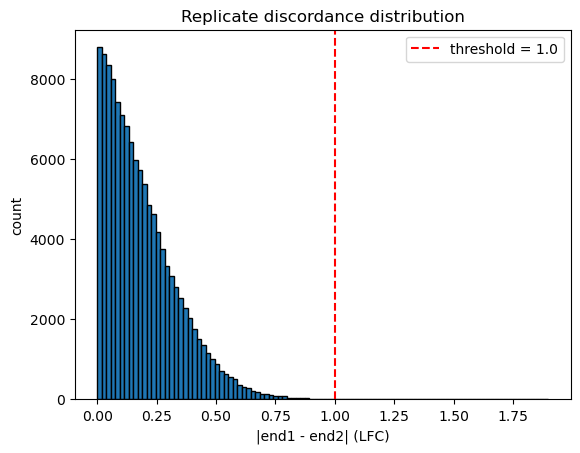

count    1.243390e+05
mean     1.876973e-01
std      1.499777e-01
min      3.532960e-07
25%      6.942972e-02
50%      1.536883e-01
75%      2.703018e-01
max      1.898648e+00
Name: replicate_delta, dtype: float64


In [ ]:
#@title Cell 2: Noise Histogram
# Replicate discordance distribution — justifies the 1.0 LFC threshold
import matplotlib.pyplot as plt

df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
plt.hist(df['replicate_delta'], bins=100, edgecolor='black')
plt.axvline(1.0, color='red', linestyle='--', label='threshold = 1.0')
plt.xlabel('|end1 - end2| (LFC)')
plt.ylabel('count')
plt.title('Replicate discordance distribution')
plt.legend()
plt.show()
print(df['replicate_delta'].describe())

In [ ]:
#@title Cell 3: Noise Filter
# Discordance filter + stratified noise filter
# Depends on: df from Cell 1
# Produces: df_clean (canonical working dataset for all downstream cells)

# ── REPLICATE DISCORDANCE FILTER ──────────────────────────────────────
# Discard sequences where end1 and end2 disagree by more than 1.0 LFC.
# With only two replicates, log2FC_std is just |end1-end2|/√2 — not a
# real distributional estimate. The raw delta is more honest.
df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
DISCORD_THRESHOLD = 1.0
df_clean = df[df['replicate_delta'] <= DISCORD_THRESHOLD].copy()
print(f"Discordance filter (>{DISCORD_THRESHOLD} LFC): removed "
      f"{len(df) - len(df_clean)} sequences "
      f"({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

# ── STRATIFIED NOISE FILTER ───────────────────────────────────────────
# Global 95th-percentile std cutoff would remove low-fitness extremes
# disproportionately — exactly the sequences you need most.
# Fix: apply the cutoff within 10 fitness deciles instead.
df_clean['lfc_bin'] = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)

def stratified_noise_mask(group, percentile=95):
    threshold = np.percentile(group['log2FC_std'], percentile)
    return group[group['log2FC_std'] <= threshold]

df_clean = (
    df_clean
    .groupby('lfc_bin', group_keys=False)
    .apply(stratified_noise_mask, include_groups=False)
    .reset_index(drop=True)
)

# ── CLEAN UP HELPER COLUMNS ───────────────────────────────────────────
df_clean.drop(columns=['replicate_delta', 'lfc_bin'], inplace=True, errors='ignore')

# --- FIX: SHUFFLE TO BREAK SORTED HOMOGENOUS GROUPS ---
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)


# ── SANITY CHECK ──────────────────────────────────────────────────────
n_raw   = len(df)
n_final = len(df_clean)
low_before = (df['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()
low_after  = (df_clean['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()

print(f"Retained: {n_final}/{n_raw} sequences ({n_final/n_raw*100:.1f}%)")
print(f"Low-fitness sequences preserved (bottom 5%): "
      f"{low_after}/{low_before} ({low_after/low_before*100:.1f}%)")
print(f"\nFitness distribution after filtering:")
print(df_clean['log2FC_mean'].describe().round(3))
print("\ndf_clean ready.")

Discordance filter (>1.0 LFC): removed 35 sequences (0.0%)
Retained: 118084/124339 sequences (95.0%)
Low-fitness sequences preserved (bottom 5%): 5813/6217 (93.5%)

Fitness distribution after filtering:
count    118084.000
mean         -0.064
std           0.338
min          -4.181
25%          -0.258
50%          -0.071
75%           0.119
max           3.995
Name: log2FC_mean, dtype: float64

df_clean ready.


In [ ]:
#@title Cell 4: K-mer Tokenisation (5 bins)
# Positional K-mer Tokenisation
# Depends on: df_clean from Cell 3
# Produces: df_clean['kmers'] — space-separated positional 4-mer strings

N_POSITIONAL_BINS = 5   # change in one place — used everywhere downstream
KMER_K = 4

def get_positional_kmers(seq, k=KMER_K, n_bins=N_POSITIONAL_BINS):
    """
    Splits a DNA sequence into n_bins equal spatial regions and labels
    each k-mer with the bin its starting position falls into.

    Bin labels are zero-padded (BIN00, BIN01, ...) so feature names
    sort in spatial order — useful when reading SVD loadings.
    """
    n = len(seq)
    bin_size = n / n_bins
    kmers = []
    for i in range(n - k + 1):
        bin_idx = min(int(i / bin_size), n_bins - 1)
        kmers.append(f"BIN{bin_idx:02d}_{seq[i:i+k]}")
    return " ".join(kmers)

def dummy_analyzer(doc):
    return doc.split()

print(f"Generating positional k-mers (k={KMER_K}, bins={N_POSITIONAL_BINS})...")
df_clean['kmers'] = df_clean['sequence'].apply(get_positional_kmers)
print(f"Done. Example: {df_clean['kmers'].iloc[0][:80]}...")
print(f"Expected vocab ceiling: {N_POSITIONAL_BINS} bins × 4^{KMER_K} k-mers = {N_POSITIONAL_BINS * 4**KMER_K}")

Generating positional k-mers (k=4, bins=5)...
Done. Example: BIN00_AAGC BIN00_AGCT BIN00_GCTG BIN00_CTGT BIN00_TGTT BIN00_GTTT BIN00_TTTT BIN...
Expected vocab ceiling: 5 bins × 4^4 k-mers = 1280


In [ ]:
# =====================================================================
# @title Cell 5: Vectorisation Engine & Biophysical Calculator (v2.1)
# =====================================================================
import numpy as np
import pandas as pd
import re
import sys # <-- ADDED
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from tqdm import tqdm # <-- FIXED IMPORT

# E. coli codon relative adaptiveness table (Sharp & Li 1987)
ECOLI_W = {
    'TTT': 0.296, 'TTC': 1.000, 'TTA': 0.020, 'TTG': 0.020, 'CTT': 0.042, 'CTC': 0.037, 'CTA': 0.007, 'CTG': 1.000,
    'ATT': 0.185, 'ATC': 1.000, 'ATA': 0.003, 'ATG': 1.000, 'GTT': 0.221, 'GTC': 0.062, 'GTA': 0.076, 'GTG': 1.000,
    'TCT': 0.217, 'TCC': 0.744, 'TCA': 0.077, 'TCG': 0.017, 'AGT': 0.085, 'AGC': 1.000, 'CCT': 0.070, 'CCC': 0.012,
    'CCA': 0.194, 'CCG': 1.000, 'ACT': 0.185, 'ACC': 1.000, 'ACA': 0.076, 'ACG': 0.099, 'GCT': 0.210, 'GCC': 0.224,
    'GCA': 0.587, 'GCG': 1.000, 'TAT': 0.239, 'TAC': 1.000, 'TAA': 1.000, 'TAG': 0.008, 'TGA': 0.724, 'CAT': 0.217,
    'CAC': 1.000, 'CAA': 0.124, 'CAG': 1.000, 'AAT': 0.051, 'AAC': 1.000, 'AAA': 1.000, 'AAG': 0.253, 'GAT': 0.434,
    'GAC': 1.000, 'GAA': 1.000, 'GAG': 0.259, 'TGT': 0.500, 'TGC': 1.000, 'TGG': 1.000, 'CGT': 1.000, 'CGC': 0.356,
    'CGA': 0.004, 'CGG': 0.004, 'AGA': 0.002, 'AGG': 0.002, 'GGT': 1.000, 'GGC': 0.724, 'GGA': 0.057, 'GGG': 0.019,
}

RARE_CODONS = {'AGG', 'AGA', 'CTA', 'CGA', 'CGG', 'ATA', 'TTA', 'TTG'}

def calculate_master_features(seq):
    seq = seq.upper()
    seq_len = len(seq)
    if seq_len == 0:
        return {'Size': 0}

    gc_array = np.array([(1 if base in 'GC' else 0) for base in seq])
    gc_percent = gc_array.sum() / seq_len

    window_size = 50
    rolling_gcs = [gc_array[i:i+window_size].mean()
                   for i in range(max(1, seq_len - window_size + 1))]
    gc_variance = np.var(rolling_gcs) if seq_len >= window_size else 0.0

    max_homo = max([len(m.group(0)) for m in re.finditer(r'(.)\1*', seq)] + [0])

    k = 4
    km_list = [seq[i:i+k] for i in range(seq_len - k + 1)]
    if km_list:
        counts = Counter(km_list)
        entropy = -sum((c/len(km_list)) * np.log2(c/len(km_list))
                       for c in counts.values())
    else:
        entropy = 0.0

    max_at = max([len(m.group(0)) for m in re.finditer(r'[AT]+', seq)] + [0])

    promoters = seq.count('TATAAT') + seq.count('TTGACA')
    rbs_str   = seq.count('AGGAGG') + seq.count('AGGA') + seq.count('GGAG')

    ihf_sites  = len(re.findall(r'[AT]ATCAA.{4}[AT][AT][AG]', seq))
    lrp_sites  = len(re.findall(r'[CT]AG[ACT]A[AT].{3}[AT][GC][CT][AT][AG]', seq))
    crp_sites  = len(re.findall(r'TGTGA.{6}TCACA', seq))
    nagc_sites = len(re.findall(r'[AT]{2}.{3}CG.AA.T', seq))
    argr_sites = len(re.findall(r'A.TGAA.T.{4}ATTC.A.T', seq))

    win = 10
    at_array = np.array([(1 if b in 'AT' else 0) for b in seq])
    window_at = [at_array[i:i+win].sum() / win
                 for i in range(max(1, seq_len - win + 1))]
    hns_affinity = sum(1 for w in window_at if w > 0.65) / len(window_at) if window_at else 0.0

    codons = [seq[i:i+3] for i in range(0, seq_len - 2, 3) if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    ttc = 1.0 - np.exp(np.mean(np.log(w_vals))) if w_vals else 0.5

    rare_flags = [1 if c in RARE_CODONS else 0 for c in codons]
    rcc = sum(1 for i in range(len(rare_flags) - 4)
              if sum(rare_flags[i:i+5]) >= 2) if len(rare_flags) >= 5 else 0

    sd_patterns = [m.start() for m in re.finditer(r'(?=GGAG|AGGA)', seq)]
    start_codons = [m.start() for m in re.finditer(r'(?=ATG|GTG|TTG)', seq)]
    tir_proxy = 0.0
    for sd_pos in sd_patterns:
        downstream = [sc for sc in start_codons if sc > sd_pos]
        if downstream:
            dist = min(downstream) - sd_pos
            if 5 <= dist <= 9:    tir_proxy += 1.0
            elif 10 <= dist <= 14: tir_proxy += 0.5
            else:                  tir_proxy += 0.1

    rnase_e_hits = len(re.findall(r'[AG]A[AT][AT][AT]', seq))

    dinucleotides = [seq[i:i+2] for i in range(seq_len - 1)]
    rigid_steps = sum(1 for dn in dinucleotides if dn in ['AA', 'TT', 'AT'])
    shape_rigidity_mean = rigid_steps / max(1, len(dinucleotides))

    g_count = seq.count('G')
    c_count = seq.count('C')
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0.0

    features = {
        'Size': seq_len, 'GC_percent': gc_percent, 'GC_Var': gc_variance, 'Max_Homo': max_homo,
        'Entropy': entropy, 'AT_tract': max_at, 'Promoter_Str': promoters, 'RBS_Str': rbs_str,
        'IHF': ihf_sites, 'Lrp': lrp_sites, 'CRP': crp_sites, 'NagC': nagc_sites, 'ArgR': argr_sites,
        'HNS_Affinity': hns_affinity, 'TTC': ttc, 'RCC': rcc, 'TIR_Proxy': tir_proxy,
        'mRNA_Stability': rnase_e_hits, 'Shape_Rigidity_Mean': shape_rigidity_mean, 'GC_Skew': gc_skew,
    }
    return features

print("--- EXTRACTING BIOPHYSICAL FEATURES ---")
# <-- FIXED PROGRESS BAR -->
tqdm.pandas(desc="Biophysical Extraction", file=sys.stdout)
biophys_df = pd.DataFrame(
    df_clean['sequence'].progress_apply(calculate_master_features).tolist(),
    index=df_clean.index
)
mech_feature_labels = biophys_df.columns.tolist()

for col in mech_feature_labels:
    df_clean[col] = biophys_df[col]

print(f"Extraction complete. Total biophysical features: {len(mech_feature_labels)}")

# =====================================================================
# V2.0 LEAK-FREE VECTORISATION & SCALING
# =====================================================================
def get_v20_features(df_train, df_test, mech_labels):
    print("Fitting Scaler and Vectorizer on TRAIN set only...")

    scaler = StandardScaler()
    X_mech_train_scaled = scaler.fit_transform(df_train[mech_labels])
    X_mech_test_scaled  = scaler.transform(df_test[mech_labels])

    def spatial_tokenizer(text): return text.split()

    vectorizer = CountVectorizer(tokenizer=spatial_tokenizer, token_pattern=None)
    X_sparse_train = vectorizer.fit_transform(df_train['kmers'])
    X_sparse_test  = vectorizer.transform(df_test['kmers'])

    scale_factor = X_sparse_train.shape[1] / len(mech_labels)
    X_train_combined = hstack([X_sparse_train, csr_matrix(X_mech_train_scaled * scale_factor)])
    X_test_combined  = hstack([X_sparse_test,  csr_matrix(X_mech_test_scaled  * scale_factor)])

    feature_names = vectorizer.get_feature_names_out()

    return {
        'X_train_combined': X_train_combined, 'X_test_combined':  X_test_combined,
        'X_train_sp':       X_sparse_train, 'X_test_sp':        X_sparse_test,
        'vocab':            feature_names, 'scaler':           scaler,
        'vectorizer':       vectorizer, 'scale_factor':     scale_factor,
    }

--- EXTRACTING BIOPHYSICAL FEATURES ---
Biophysical Extraction: 100%|█████████████████████████████████████████████████| 118084/118084 [02:44<00:00, 716.96it/s]
Extraction complete. Total biophysical features: 20


In [ ]:
# =====================================================================
# @title Cell 6: Cluster-Based Split & Leak-Free Transformation (v2.3)
# =====================================================================
# v2.2 changes:
#   - [HOTFIX] Recovers critical biological features that were missing
#     from the input list before scaling.
#   - KMeans now fit on STANDARDISED biophysical features.
#   - Constant-variance features dropped from mech_feature_labels here.
#   - SCALER_FEATURES frozen as a tuple so it can't be mutated downstream.
#   - X_train_sp and X_test_sp exposed explicitly.
#
# v2.3 change (this version): HNS_Coverage removed from the recovery
# manifest and the post-split audit list. The HNS redundancy diagnostic
# (Cell 30) confirmed HNS_Coverage is bit-identical to HNS_Affinity
# (Pearson r = 1.0, residual std ~1e-8 — pure float-path noise from a
# different code route to the same scan). HNS_Affinity (from Cell 5) is
# the kept canonical version; HNS_Coverage is no longer produced by
# Cell 8 v2.4. A fresh pipeline run will therefore have 27 supervised
# features instead of 28. Existing SP3 checkpoints continue to work
# (their 28-column dfs include the now-redundant column, which trees
# treat as a no-op).
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        pass  # no styling — pipeline still works

# ── 1. RECOVER MISSING INPUTS & DROP CONSTANTS ──────────────────────────
print("--- 1. PREPARING FEATURES ---")

# A. Force missing biological biomarkers into the input list if they exist in the data.
#    HNS_Coverage removed in v2.3 — see header note (redundant with HNS_Affinity).
missing_but_required = ['CAI_Score', 'mRNA_MFE', 'Flux_Score']
recovered = []
for f in missing_but_required:
    if f in df_clean.columns and f not in mech_feature_labels:
        mech_feature_labels.append(f)
        recovered.append(f)

if recovered:
    print(f"  [RECOVERY] Injected {len(recovered)} critical biomarkers into scaler pipeline: {recovered}")

# B. Drop true constant features
constant_cols = [f for f in mech_feature_labels if df_clean[f].nunique() <= 1]
if constant_cols:
    print(f"  Dropping {len(constant_cols)} true constant feature(s): {constant_cols}")
    mech_feature_labels = [f for f in mech_feature_labels if f not in constant_cols]

print(f"  Active biophysical features going to Scaler: {len(mech_feature_labels)}")

# ── 2. CLUSTER (SCALED FEATURES, NO LABEL ACCESS) ───────────────────────
print("\n--- 2. DEFINING SEQUENCE CLUSTERS ---")
cluster_scaler = StandardScaler()
X_for_clusters = cluster_scaler.fit_transform(df_clean[mech_feature_labels])

n_clusters = 50
kmeans = MiniBatchKMeans(
    n_clusters=n_clusters,
    random_state=42,
    batch_size=2048,
    n_init='auto',
)
df_clean['Cluster_ID'] = kmeans.fit_predict(X_for_clusters)
print(f"  {n_clusters} biophysical clusters assigned across {len(df_clean):,} sequences.")

# ── 3. CLUSTER-HELD-OUT SPLIT ───────────────────────────────────────────
print("\n--- 3. CLUSTER-HELD-OUT SPLIT ---")
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean['Cluster_ID']))

df_train = df_clean.iloc[train_idx].copy()
df_test  = df_clean.iloc[test_idx].copy()

train_clusters = set(df_train['Cluster_ID'])
test_clusters  = set(df_test['Cluster_ID'])
assert train_clusters.isdisjoint(test_clusters), "Cluster leak between splits!"
print(f"  Train: {len(df_train):,} sequences, {len(train_clusters)} clusters")
print(f"  Test:  {len(df_test):,} sequences, {len(test_clusters)} clusters")

# ── 4. LEAK-FREE SCALING & VECTORISATION ────────────────────────────────
print("\n--- 4. LEAK-FREE TRANSFORMATION ---")
artifacts = get_v20_features(df_train, df_test, mech_feature_labels)

X_train_combined = artifacts['X_train_combined']
X_test_combined  = artifacts['X_test_combined']
X_train_sp       = artifacts['X_train_sp']
X_test_sp        = artifacts['X_test_sp']
vocab            = artifacts['vocab']
fitted_scaler    = artifacts['scaler']
fitted_vec       = artifacts['vectorizer']
SCALE_FACTOR     = artifacts['scale_factor']

# Frozen snapshot of what fitted_scaler was fit on. Never mutate this.
SCALER_FEATURES = tuple(mech_feature_labels)
print(f"  Train fused matrix: {X_train_combined.shape}")
print(f"  Test  fused matrix: {X_test_combined.shape}")
print(f"  SCALER_FEATURES frozen at {len(SCALER_FEATURES)} features.")

# ── 5. SVD (TRAIN-ONLY FIT, TRANSFORM TEST) ─────────────────────────────
print("\n--- 5. SVD ---")
svd = TruncatedSVD(n_components=2, random_state=42)
train_pcs = svd.fit_transform(X_train_combined)
test_pcs  = svd.transform(X_test_combined)

df_train['PC1'], df_train['PC2'] = train_pcs[:, 0], train_pcs[:, 1]
df_test['PC1'],  df_test['PC2']  = test_pcs[:, 0],  test_pcs[:, 1]
print(f"  Explained variance ratio: {svd.explained_variance_ratio_}")
print("  df_train and df_test PC1/PC2 are now in the same coordinate system.")


print("                   ")
print("                   ")


import pandas as pd

print("--- POST-SPLIT FEATURE AUDIT ---")

# 1. Verify the Hardware Features frozen by the Scaler
print("\n[1] HARDWARE FEATURES (Ready for ML):")
missing_hardware = [f for f in SCALER_FEATURES if f not in df_train.columns]
if not missing_hardware:
    print(f"  [PASS] ✓ All {len(SCALER_FEATURES)} base SCALER_FEATURES are present in df_train.")
else:
    print(f"  [FAIL] X ERROR: Missing hardware features: {missing_hardware}")

# 2. Check for Advanced Biomarkers (Expected to be missing at this stage)
#    HNS_Coverage removed in v2.3 — see header note.
print("\n[2] ADVANCED BIOMARKERS (Pending Downstream Calculation):")
advanced_expected_later = [
    'CAI_Score', 'mRNA_MFE', 'Flux_Score',
    'Min_Hairpin_dG', 'Max_Repeat_Len', 'mRNA_Stability'
]
for f in advanced_expected_later:
    status = "✓ Present (Already Calculated)" if f in df_train.columns else "⏳ Pending Calculation (Normal)"
    print(f"  • {f:<20} : {status}")

# 3. Check for Learned Coordinates (Expected to be missing at this stage)
print("\n[3] LEARNED MANIFOLD COORDINATES (Pending Downstream Calculation):")
learned_expected_later = ['UMAP_1', 'UMAP_2', 'CNN_Score']
for f in learned_expected_later:
    status = "✓ Present (Already Calculated)" if f in df_train.columns else "⏳ Pending Calculation (Normal)"
    print(f"  • {f:<20} : {status}")

# 4. Verify df_test matches df_train dimensions for features
print("\n[4] TRAIN / TEST PARITY:")
train_feats = set(SCALER_FEATURES)
test_feats = set(df_test.columns).intersection(train_feats)
if train_feats == test_feats:
    print("  [PASS] ✓ df_test perfectly matches df_train for all base features.")
else:
    print(f"  [FAIL] ❌ ERROR: df_test is missing: {train_feats - test_feats}")

print("\n" + "=" * 65)
print("Audit complete. Dataframe is perfectly staged for Phase 2 (Biophysics).")
print("=" * 65)

--- 1. PREPARING FEATURES ---
  Dropping 1 true constant feature(s): ['Size']
  Active biophysical features going to Scaler: 19

--- 2. DEFINING SEQUENCE CLUSTERS ---
  50 biophysical clusters assigned across 118,084 sequences.

--- 3. CLUSTER-HELD-OUT SPLIT ---
  Train: 92,144 sequences, 40 clusters
  Test:  25,940 sequences, 10 clusters

--- 4. LEAK-FREE TRANSFORMATION ---
Fitting Scaler and Vectorizer on TRAIN set only...
  Train fused matrix: (92144, 1299)
  Test  fused matrix: (25940, 1299)
  SCALER_FEATURES frozen at 19 features.

--- 5. SVD ---
  Explained variance ratio: [0.20799618 0.1049687 ]
  df_train and df_test PC1/PC2 are now in the same coordinate system.
                   
                   
--- POST-SPLIT FEATURE AUDIT ---

[1] HARDWARE FEATURES (Ready for ML):
  [PASS] ✓ All 19 base SCALER_FEATURES are present in df_train.

[2] ADVANCED BIOMARKERS (Pending Downstream Calculation):
  • CAI_Score            : ⏳ Pending Calculation (Normal)
  • mRNA_MFE             : 

In [ ]:
# =====================================================================
# @title Secton 2, Cells 7: CAI_Score & mRNA_MFE
# =====================================================================
import numpy as np
import sys
from tqdm import tqdm # <-- FIXED IMPORT

def compute_cai(seq):
    seq = seq.upper()
    codons = [seq[i:i+3] for i in range(0, len(seq) - 2, 3) if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    if not w_vals: return 0.5
    return float(np.exp(np.mean(np.log(w_vals))))

print("--- Computing CAI_Score ---")
tqdm.pandas(desc="CAI (train)", file=sys.stdout)
df_train['CAI_Score'] = df_train['sequence'].progress_apply(compute_cai)
tqdm.pandas(desc="CAI (test)", file=sys.stdout)
df_test['CAI_Score']  = df_test['sequence'].progress_apply(compute_cai)

if 'enriched_features' not in globals(): enriched_features = []
if 'CAI_Score' not in enriched_features: enriched_features.append('CAI_Score')

NN_dG = {
    'AA': -1.00, 'AT': -0.88, 'AC': -1.44, 'AG': -1.28, 'TA': -0.58, 'TT': -1.00, 'TC': -1.30, 'TG': -1.45,
    'CA': -1.45, 'CT': -1.28, 'CC': -1.84, 'CG': -2.17, 'GA': -1.30, 'GT': -1.44, 'GC': -2.24, 'GG': -1.84,
}

def initiation_mfe_proxy(seq, window=30):
    head = seq[:window].upper()
    if len(head) < 2: return 0.0
    return float(sum(NN_dG.get(head[i:i+2], -1.0) for i in range(len(head) - 1)))

print("--- Computing mRNA_MFE ---")
tqdm.pandas(desc="MFE (train)", file=sys.stdout)
df_train['mRNA_MFE'] = df_train['sequence'].progress_apply(initiation_mfe_proxy)
tqdm.pandas(desc="MFE (test)", file=sys.stdout)
df_test['mRNA_MFE']  = df_test['sequence'].progress_apply(initiation_mfe_proxy)

if 'mRNA_MFE' not in enriched_features: enriched_features.append('mRNA_MFE')
print(f"  Biomarkers added. enriched_features = {enriched_features}")

--- Computing CAI_Score ---
CAI (test): 100%|█████████████████████████████████████████████████████████████| 25940/25940 [00:01<00:00, 23950.50it/s]
--- Computing mRNA_MFE ---
MFE (test): 100%|████████████████████████████████████████████████████████████| 25940/25940 [00:00<00:00, 122360.34it/s]
  Biomarkers added. enriched_features = ['CAI_Score', 'mRNA_MFE']


In [ ]:
# =====================================================================
# @title Cell 8: Structural & Topological Features (v2.4, numba-fast)
# =====================================================================
# v2.4 change (this version): HNS_Coverage no longer produced as a
# column. The HNS redundancy diagnostic (Cell 30) confirmed it is
# bit-identical to HNS_Affinity (already produced by Cell 5):
# Pearson r = 1.0, Spearman = 1.0, residual std ~1e-8 — pure float-path
# numerical noise from a different code route to the same scan.
# Keeping both wasted a slot in supervised_features and produced a
# perfect-collinearity column that hurt unsupervised SVD reductions
# (visible as the k=6 dip in Cell 26's feature curve).
#
# What changed:
#   - `_scan_all` parallel kernel no longer returns the n_out array.
#   - `df_train['HNS_Coverage']` and `df_test['HNS_Coverage']` no longer
#     assigned.
#   - 'HNS_Coverage' removed from the enriched_features append loop.
#   - `_hns_one` definition retained because Cell 21's RC featurisation
#     and Cell 31's Oracle still call it as an unused-key assignment;
#     making it stop being defined would break those cells. (Their
#     dead-code lines are harmless — the key gets filtered out by
#     `df_train_rc[supervised_features]`.)
#
# Net effect: a fresh end-to-end pipeline run will produce 27 supervised
# features instead of 28. Existing SP3 checkpoints continue to work
# (their 28-column dfs include the now-redundant column, which trees
# treat as a no-op).
import numpy as np
import pandas as pd
import sys
from tqdm import tqdm

ENC = np.full(256, -1, dtype=np.int8)
for c, v in zip('ACGTacgt', [0, 1, 2, 3, 0, 1, 2, 3]):
    ENC[ord(c)] = v

def encode_sequences(series, seq_len=172):
    n = len(series)
    out = np.zeros((n, seq_len), dtype=np.int8)
    for i, s in enumerate(series.values):
        b = np.frombuffer(s[:seq_len].encode('ascii'), dtype=np.uint8)
        out[i, :len(b)] = ENC[b]
    return out

NN_DG = np.array([
    [-1.00, -1.44, -1.28, -0.88],
    [-1.45, -1.84, -2.17, -1.28],
    [-1.30, -2.24, -1.84, -1.44],
    [-0.58, -1.30, -1.45, -1.00],
], dtype=np.float32)

try:
    from numba import njit, prange
    NUMBA_OK = True
    print("  Numba available — using JIT kernels.")
except ImportError:
    NUMBA_OK = False
    print("  Numba unavailable — falling back to Python.")

if NUMBA_OK:
    @njit(cache=True)
    def _hairpin_one(seq, nn_dg):
        n = seq.shape[0]
        min_dg = 0.0
        for i in range(n - 11):
            for stem_len in range(4, 9):
                for loop_len in range(3, 7):
                    j = i + stem_len + loop_len
                    if j + stem_len > n: break
                    match = True
                    for k in range(stem_len):
                        if seq[j + k] != 3 - seq[i + stem_len - 1 - k]:
                            match = False; break
                    if match:
                        dg = 0.0
                        for k in range(stem_len - 1): dg += nn_dg[seq[i + k], seq[i + k + 1]]
                        if dg < min_dg: min_dg = dg
        return min_dg

    # Retained for Cell 21 RC featurisation and Cell 31 Oracle; no longer
    # called by Cell 8's own _scan_all kernel.
    @njit(cache=True)
    def _hns_one(seq, win=10, threshold=7):
        n = seq.shape[0]
        if n < win: return 0.0
        at = 0
        for i in range(win):
            if seq[i] == 0 or seq[i] == 3: at += 1
        hits = 1 if at >= threshold else 0
        for i in range(1, n - win + 1):
            if seq[i - 1] == 0 or seq[i - 1] == 3: at -= 1
            if seq[i + win - 1] == 0 or seq[i + win - 1] == 3: at += 1
            if at >= threshold: hits += 1
        return hits / (n - win + 1)

    # v2.4: dropped HNS scan (redundant with HNS_Affinity from Cell 5).
    @njit(cache=True, parallel=True)
    def _scan_all(seqs, nn_dg):
        N = seqs.shape[0]
        h_out = np.zeros(N, dtype=np.float32)
        for s in prange(N):
            h_out[s] = _hairpin_one(seqs[s], nn_dg)
        return h_out

def scan_direct_repeats(seq, min_len=6, max_len=20):
    seq = seq.upper()
    n = len(seq)
    longest = 0
    for L in range(min_len, max_len + 1):
        seen = {}
        found = False
        for i in range(n - L + 1):
            sub = seq[i:i + L]
            if sub in seen:
                if i - seen[sub] >= L:
                    longest = L; found = True
            else:
                seen[sub] = i
        if not found: break
    return longest

print("--- Computing structural features ---")
print("  Encoding sequences...")
train_int = encode_sequences(df_train['sequence'])
test_int  = encode_sequences(df_test['sequence'])

print("  Hairpin scan...")
if NUMBA_OK:
    h_tr = _scan_all(train_int, NN_DG)
    h_te = _scan_all(test_int,  NN_DG)
else:
    h_tr = np.array([float(_hairpin_one(s, NN_DG)) for s in train_int], dtype=np.float32)
    h_te = np.array([float(_hairpin_one(s, NN_DG)) for s in test_int],  dtype=np.float32)

df_train['Min_Hairpin_dG'] = h_tr
df_test['Min_Hairpin_dG']  = h_te
# v2.4: HNS_Coverage no longer assigned (redundant with HNS_Affinity from Cell 5).

print("  Direct repeat scan...")
tqdm.pandas(desc="Repeats (train)", file=sys.stdout)
df_train['Max_Repeat_Len'] = df_train['sequence'].progress_apply(scan_direct_repeats)
tqdm.pandas(desc="Repeats (test)", file=sys.stdout)
df_test['Max_Repeat_Len']  = df_test['sequence'].progress_apply(scan_direct_repeats)

df_train['Flux_Score'] = (df_train['CAI_Score'] * 20) + (df_train['Promoter_Str'] * 30)
df_test['Flux_Score']  = (df_test['CAI_Score']  * 20) + (df_test['Promoter_Str']  * 30)

# v2.4: HNS_Coverage removed from the enriched features list.
if 'enriched_features' not in globals(): enriched_features = []
for f in ['Min_Hairpin_dG', 'Max_Repeat_Len', 'Flux_Score']:
    if f not in enriched_features: enriched_features.append(f)

print(f"  Structural features added. enriched_features = {enriched_features}")

  Numba available — using JIT kernels.
--- Computing structural features ---
  Encoding sequences...
  Hairpin scan...
  Direct repeat scan...
Repeats (test): 100%|██████████████████████████████████████████████████████████| 25940/25940 [00:03<00:00, 7155.71it/s]
  Structural features added. enriched_features = ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'Max_Repeat_Len', 'Flux_Score']


In [ ]:
# =====================================================================
# @title Cell 9: CNN-BiGRU Spatial Feature Extraction (GPU) — symmetric
# =====================================================================
# Changes vs original (v2.96):
#   - df_test CNN_Score now uses 5-fold ENSEMBLE (mean of 5 fold predictions)
#     instead of a single final-fit-on-full-train model. Equalises train/test
#     treatment and reduces label imprint.
#   - Per-fold test predictions saved for diagnostic (cnn_test_per_fold).
#   - model_cnn (used by Cell 31 Oracle Predictor) still trains a final
#     full-data model so single-sequence inference works unchanged.
#   - Architecture, dropout, L2 unchanged from original Cell 9.

import numpy as np
import tensorflow as tf
import sys
from tensorflow.keras import layers, models, regularizers, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
from tqdm import tqdm

print("--- Computing CNN_Score (CNN-BiGRU, GPU) — 5-fold ensemble for test ---")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"  WARN: could not set memory growth ({e})")
    print(f"  GPU detected: {gpus[0].name}, memory growth enabled.")
    mixed_precision.set_global_policy('mixed_float16')
    print("  Mixed precision (FP16) enabled.")
    BATCH_SIZE = 256
else:
    print("  No GPU detected — falling back to CPU.")
    BATCH_SIZE = 128

def one_hot_encode(sequences, seq_len=172):
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    encoded = np.zeros((len(sequences), seq_len, 4), dtype=np.float32)
    for i, seq in tqdm(enumerate(sequences), total=len(sequences), desc="  Encoding", file=sys.stdout):
        for j, base in enumerate(seq[:seq_len]):
            if base in mapping:
                encoded[i, j, mapping[base]] = 1
    return encoded

def build_cnn_bigru():
    inputs = layers.Input(shape=(172, 4))
    conv_short = layers.Conv1D(48, kernel_size=6, padding='same', activation='relu',
                               kernel_regularizer=regularizers.l2(1e-5))(inputs)
    conv_long  = layers.Conv1D(48, kernel_size=12, padding='same', activation='relu',
                               kernel_regularizer=regularizers.l2(1e-5))(inputs)
    x = layers.Concatenate()([conv_short, conv_long])
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Bidirectional(layers.GRU(32, return_sequences=True, dropout=0.1, recurrent_dropout=0.0))(x)
    x = layers.Bidirectional(layers.GRU(16, return_sequences=False, dropout=0.1, recurrent_dropout=0.0))(x)
    x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(1, dtype='float32')(x)
    m = models.Model(inputs, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
    return m

print("\n  One-hot encoding train + test...")
X_train_cnn = one_hot_encode(df_train['sequence'].values)
X_test_cnn  = one_hot_encode(df_test['sequence'].values)
y_train_cnn = df_train['log2FC_mean'].values

print("\n  5-fold OOF training + per-fold test prediction...")
cnn_oof = np.zeros(len(df_train), dtype=np.float32)
cnn_test_per_fold = np.zeros((5, len(df_test)), dtype=np.float32)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr, va) in enumerate(kf.split(X_train_cnn), 1):
    print(f"\n  Fold {fold}/5")
    tf.keras.utils.set_random_seed(42 + fold)
    rng_fold = np.random.default_rng(42 + fold)
    inner_va = rng_fold.choice(tr, size=int(0.1 * len(tr)), replace=False)
    inner_tr = np.setdiff1d(tr, inner_va)

    m = build_cnn_bigru()
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    m.fit(X_train_cnn[inner_tr], y_train_cnn[inner_tr],
          validation_data=(X_train_cnn[inner_va], y_train_cnn[inner_va]),
          epochs=25, batch_size=BATCH_SIZE, verbose=1, callbacks=[es])
    cnn_oof[va] = m.predict(X_train_cnn[va], batch_size=BATCH_SIZE * 2, verbose=0).flatten()
    cnn_test_per_fold[fold-1] = m.predict(X_test_cnn, batch_size=BATCH_SIZE * 2, verbose=0).flatten()
    fold_oof_rho, _ = spearmanr(cnn_oof[va], y_train_cnn[va])
    fold_test_rho, _ = spearmanr(cnn_test_per_fold[fold-1], df_test['log2FC_mean'].values)
    print(f"  Fold {fold}/5  OOF rho: {fold_oof_rho:+.4f}   |   test rho: {fold_test_rho:+.4f}")
    tf.keras.backend.clear_session()

# Test CNN_Score = ENSEMBLE MEAN of 5 fold predictions (NOT single final-fit)
cnn_test_ensemble = cnn_test_per_fold.mean(axis=0)

df_train['CNN_Score'] = cnn_oof
df_test['CNN_Score']  = cnn_test_ensemble

if 'enriched_features' not in globals(): enriched_features = []
if 'CNN_Score' not in enriched_features: enriched_features.append('CNN_Score')

# Final CNN for Cell 31 Oracle Predictor (single-sequence inference still uses one model)
print("\n  Refitting on full df_train for predictor model_cnn (used by Cell 31 only)...")
tf.keras.utils.set_random_seed(42)
rng_final = np.random.default_rng(42)
inner_va = rng_final.choice(len(X_train_cnn), size=int(0.1 * len(X_train_cnn)), replace=False)
inner_tr = np.setdiff1d(np.arange(len(X_train_cnn)), inner_va)

final_cnn = build_cnn_bigru()
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
final_cnn.fit(X_train_cnn[inner_tr], y_train_cnn[inner_tr],
              validation_data=(X_train_cnn[inner_va], y_train_cnn[inner_va]),
              epochs=25, batch_size=BATCH_SIZE, verbose=1, callbacks=[es])
model_cnn = final_cnn

oof_rho, _  = spearmanr(cnn_oof, y_train_cnn)
test_rho, _ = spearmanr(df_test['CNN_Score'], df_test['log2FC_mean'])
fold_test_rhos = [spearmanr(cnn_test_per_fold[f], df_test['log2FC_mean'])[0] for f in range(5)]

print(f"\n--- CNN-BiGRU Complete (ensemble mode) ---")
print(f"  OOF rho:                       {oof_rho:+.4f}")
print(f"  Test rho (5-fold ensemble):    {test_rho:+.4f}")
print(f"  Per-fold test rho:             {[f'{r:+.4f}' for r in fold_test_rhos]}")
print(f"  Per-fold test rho mean ± std:  {np.mean(fold_test_rhos):+.4f} ± {np.std(fold_test_rhos, ddof=1):.4f}")
print(f"  (For comparison: single-final-fit version was +0.5838)")

mixed_precision.set_global_policy('float32')

--- Computing CNN_Score (CNN-BiGRU, GPU) — 5-fold ensemble for test ---
  GPU detected: /physical_device:GPU:0, memory growth enabled.
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060, compute capability 8.6
  Mixed precision (FP16) enabled.

  One-hot encoding train + test...
  Encoding: 100%|█████████████████████████████████████████████████████████████| 25940/25940 [00:00<00:00, 31325.88it/s]

  5-fold OOF training + per-fold test prediction...

  Fold 1/5
Epoch 1/25
260/260 [==============================] - 24s 35ms/step - loss: 0.1151 - val_loss: 0.1184
Epoch 2/25
260/260 [==============================] - 8s 29ms/step - loss: 0.1052 - val_loss: 0.1093
Epoch 3/25
260/260 [==============================] - 8s 29ms/step - loss: 0.0959 - val_loss: 0.0994
Epoch 4/25
260/260 [==============================] - 8s 29ms/ste

In [ ]:
# =====================================================================
# @title Cell 10: UMAP_1, UMAP_2 (v2.3)
# =====================================================================
# Fit on a uniform random sample of df_train, transform onto train and test.
# No plots — pure feature extraction.
import umap
import numpy as np

print("--- Computing UMAP coordinates ---")
X_tr_mech = fitted_scaler.transform(df_train[list(SCALER_FEATURES)])
X_te_mech = fitted_scaler.transform(df_test[list(SCALER_FEATURES)])

FIT_N = 20_000
rng = np.random.default_rng(42)
fit_pos = rng.choice(len(df_train), size=min(FIT_N, len(df_train)), replace=False)
print(f"  Fitting on {len(fit_pos):,} sequences...")

reducer = umap.UMAP(
    n_components=2, n_neighbors=50, min_dist=0.1,
    metric='euclidean', random_state=42, low_memory=True,
)
reducer.fit(X_tr_mech[fit_pos])

print("  Transforming train + test...")
df_train['UMAP_1'], df_train['UMAP_2'] = reducer.transform(X_tr_mech).T
df_test['UMAP_1'],  df_test['UMAP_2']  = reducer.transform(X_te_mech).T

if 'enriched_features' not in globals():
    enriched_features = []
for f in ['UMAP_1', 'UMAP_2']:
    if f not in enriched_features:
        enriched_features.append(f)

print(f"  UMAP coordinates added. enriched_features = {enriched_features}")

--- Computing UMAP coordinates ---
  Fitting on 20,000 sequences...


G:\Anaconda\envs\plasmid\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Transforming train + test...
  UMAP coordinates added. enriched_features = ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'Max_Repeat_Len', 'Flux_Score', 'CNN_Score', 'UMAP_1', 'UMAP_2']


In [ ]:
# =====================================================================
# @title Cell 11: Variance Safeguard (v2.4, mostly for size, permissive, fixed NaN bug)
# =====================================================================
import numpy as np

print("--- Variance safeguard ---")

active_set = list(SCALER_FEATURES) + (enriched_features if 'enriched_features' in globals() else [])
active_set = list(dict.fromkeys(active_set))  # dedupe, preserve order

invariant = []
for f in active_set:
    if f not in df_train.columns:
        print(f"  WARN: {f} listed but missing from df_train.")
        continue

    # FIX: dropna=True prevents NaNs from being counted as a valid unique value
    n_unique = df_train[f].nunique(dropna=True)

    if n_unique <= 1:
        invariant.append((f, n_unique))
    elif f == 'Size':
        # DEBUG: If Size still survives, this will show you exactly what values are hiding in it
        unique_vals = df_train[f].dropna().unique()
        print(f"  DEBUG: 'Size' has {n_unique} unique values: {unique_vals[:5]}...")

if invariant:
    print(f"  Dropping {len(invariant)} invariant feature(s):")
    for f, n in invariant:
        print(f"    {f}  (n_unique = {n})")
        df_train.drop(columns=[f], inplace=True, errors='ignore')
        df_test.drop(columns=[f],  inplace=True, errors='ignore')

    # Update tracking lists.
    dropped = {f for f, _ in invariant}
    SCALER_FEATURES = tuple(f for f in SCALER_FEATURES if f not in dropped)
    if 'enriched_features' in globals():
        enriched_features = [f for f in enriched_features if f not in dropped]
else:
    print("  OK: no invariant features detected.")

# Final feature inventory
print(f"\n  SCALER_FEATURES   ({len(SCALER_FEATURES)}): {list(SCALER_FEATURES)}")
print(f"  enriched_features ({len(enriched_features)}): {enriched_features}")
print(f"  TOTAL active features: {len(SCALER_FEATURES) + len(enriched_features)}")

--- Variance safeguard ---
  OK: no invariant features detected.

  SCALER_FEATURES   (19): ['GC_percent', 'GC_Var', 'Max_Homo', 'Entropy', 'AT_tract', 'Promoter_Str', 'RBS_Str', 'IHF', 'Lrp', 'CRP', 'NagC', 'ArgR', 'HNS_Affinity', 'TTC', 'RCC', 'TIR_Proxy', 'mRNA_Stability', 'Shape_Rigidity_Mean', 'GC_Skew']
  enriched_features (8): ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'Max_Repeat_Len', 'Flux_Score', 'CNN_Score', 'UMAP_1', 'UMAP_2']
  TOTAL active features: 27


In [ ]:
# =====================================================================
# @title Cell 12: Workspace Scaler Check (v2.3)
# =====================================================================
# Verifies train/test parity, scaler integrity, and PC1 coordinate-system
# consistency before we hit the supervised pipeline. Cheap to run.
import numpy as np
from scipy.stats import spearmanr

print("--- Workspace sanity check ---")

# 1. PC1 coordinate-system parity
pc1_train_med = float(np.median(df_train['PC1']))
pc1_test_med  = float(np.median(df_test['PC1']))
pc1_train_iqr = float(np.subtract(*np.percentile(df_train['PC1'], [75, 25])))
pc1_test_iqr  = float(np.subtract(*np.percentile(df_test['PC1'],  [75, 25])))

print(f"  Train PC1 median {pc1_train_med:+.3f}, IQR {pc1_train_iqr:.3f}")
print(f"  Test  PC1 median {pc1_test_med:+.3f}, IQR {pc1_test_iqr:.3f}")
if abs(pc1_train_med - pc1_test_med) > 2 * max(pc1_train_iqr, pc1_test_iqr):
    print("  WARNING: train/test PC1 differ by >2x IQR. Recheck Cell 6.")
else:
    print("  OK: train/test PC1 distributions are consistent.")

# 2. PC1 vs log2FC sanity (sign and rough magnitude)
rho_tr, _ = spearmanr(df_train['PC1'], df_train['log2FC_mean'])
rho_te, _ = spearmanr(df_test['PC1'],  df_test['log2FC_mean'])
print(f"  PC1 vs log2FC_mean rho (train): {rho_tr:+.3f}")
print(f"  PC1 vs log2FC_mean rho (test):  {rho_te:+.3f}")

# 3. Scaler / SCALER_FEATURES parity
assert isinstance(SCALER_FEATURES, tuple), "SCALER_FEATURES must be a tuple."
assert hasattr(fitted_scaler, 'n_features_in_'), "fitted_scaler not fit."
# After Cell 13 we may have dropped features, so we no longer require strict equality.
# But the scaler's expected feature names must still be a SUPERSET of SCALER_FEATURES.
expected = set(getattr(fitted_scaler, 'feature_names_in_', SCALER_FEATURES))
active = set(SCALER_FEATURES)
extra = active - expected
if extra:
    print(f"  ERROR: SCALER_FEATURES contains features not in fitted_scaler: {extra}")
else:
    print("  OK: SCALER_FEATURES ⊆ fitted_scaler.feature_names_in_")

# 4. Train/test column parity for active features
all_active = list(SCALER_FEATURES) + list(enriched_features)
missing_tr = [f for f in all_active if f not in df_train.columns]
missing_te = [f for f in all_active if f not in df_test.columns]
if missing_tr:
    print(f"  ERROR: features missing from df_train: {missing_tr}")
if missing_te:
    print(f"  ERROR: features missing from df_test:  {missing_te}")
if not missing_tr and not missing_te:
    print(f"  OK: all {len(all_active)} active features present in both frames.")

# 5. Final supervised feature list
supervised_features = list(SCALER_FEATURES) + list(enriched_features)
print(f"\n  Supervised feature list ready: {len(supervised_features)} features.")
print(f"  Ready for Section 3 (supervised pipeline).")

--- Workspace sanity check ---
  Train PC1 median +5.454, IQR 177.119
  Test  PC1 median +7.459, IQR 228.811
  OK: train/test PC1 distributions are consistent.
  PC1 vs log2FC_mean rho (train): -0.282
  PC1 vs log2FC_mean rho (test):  -0.370
  OK: SCALER_FEATURES ⊆ fitted_scaler.feature_names_in_
  OK: all 27 active features present in both frames.

  Supervised feature list ready: 27 features.
  Ready for Section 3 (supervised pipeline).


In [ ]:
#@title Cell 13: Database variance checker
import pandas as pd

# 1. Load the exact file currently in your Colab environment
df_raw = pd.read_csv('GGS3_logFC.csv', on_bad_lines='skip')

# 2. Calculate lengths and filter out anything that isn't exactly 172 bp (ignoring empty rows)
df_raw['Actual_Length'] = df_raw['sequence'].astype(str).str.len()
bad_seqs = df_raw[(df_raw['Actual_Length'] != 172) & (df_raw['sequence'].notna())].copy()

# 3. Calculate exact Excel Row Number (Pandas index starts at 0, +1 for 1-based indexing, +1 for the header row)
bad_seqs['Excel_Row_Number'] = bad_seqs.index + 2

# 4. Display the results for your post-doc
print(f"Found {len(bad_seqs)} sequences with anomalous lengths:")
display(bad_seqs[['Excel_Row_Number', 'Actual_Length', 'sequence']])

Found 0 sequences with anomalous lengths:


,Excel_Row_Number,Actual_Length,sequence


In [ ]:
# @title Cell 14: Install optuna (off right now)
#!pip instal optuna

In [ ]:
# =====================================================================
# @title Section 3, Cell 15: Optuna XGBoost Hyperparameter Search (C-medium, resumable)
# =====================================================================
# 100 trials, 5-fold CV on full df_train, MedianPruner enabled.
# Resume support: study persists to checkpoints/xgb_study.db.
# Expected runtime: ~2-3 hr on a 3060.
import os
import numpy as np
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
import xgboost as xgb

print("--- Optuna XGBoost search (C-medium, resumable: 100 trials, 5-fold, full df_train) ---")

try:
    import subprocess
    r = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, timeout=2)
    use_gpu = r.returncode == 0 and 'GPU' in r.stdout
except Exception:
    use_gpu = False
xgb_device_kwargs = {'device': 'cuda', 'tree_method': 'hist'} if use_gpu else {'tree_method': 'hist'}
print(f"  GPU available: {use_gpu}")

supervised_features = list(SCALER_FEATURES) + list(enriched_features)
print(f"  Feature count: {len(supervised_features)}")

X_search = df_train[supervised_features].values.astype(np.float32)
y_search = df_train['log2FC_mean'].values.astype(np.float32)
print(f"  Search set: {len(X_search):,} sequences (full df_train)")

weight_threshold = np.quantile(y_search, 0.10)
sample_weights_search = np.where(y_search < weight_threshold, 10.0, 1.0).astype(np.float32)

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators',     200, 1500),
        'max_depth':        trial.suggest_int('max_depth',        4, 12),
        'learning_rate':    trial.suggest_float('learning_rate',  0.01, 0.20, log=True),
        'subsample':        trial.suggest_float('subsample',      0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':        trial.suggest_float('reg_alpha',  1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma',      1e-3, 10.0, log=True),
        'objective':        'reg:squarederror',
        'random_state':     42,
        'n_jobs':           -1,
        'verbosity':        0,
        'early_stopping_rounds': 50,
        **xgb_device_kwargs,
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_rhos = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_search)):
        m = xgb.XGBRegressor(**params)
        m.fit(
            X_search[tr_idx], y_search[tr_idx],
            sample_weight=sample_weights_search[tr_idx],
            eval_set=[(X_search[va_idx], y_search[va_idx])],
            verbose=False,
        )
        pred = m.predict(X_search[va_idx])
        rho, _ = spearmanr(pred, y_search[va_idx])
        fold_rhos.append(rho)
        trial.report(np.mean(fold_rhos), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_rhos))

os.makedirs('checkpoints', exist_ok=True)
storage = optuna.storages.RDBStorage(url="sqlite:///checkpoints/xgb_study.db")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    study_name='xgboost_cmedium',
    storage=storage,
    direction='maximize',
    sampler=TPESampler(seed=42, n_startup_trials=15),
    pruner=MedianPruner(n_startup_trials=15, n_warmup_steps=2),
    load_if_exists=True,
)

N_TRIALS = 100
n_done = len([t for t in study.trials if t.state.is_finished()])
n_remaining = max(0, N_TRIALS - n_done)
if n_done > 0:
    print(f"  Found existing study with {n_done} completed trials. Resuming.")
print(f"  Running {n_remaining} more trial(s) to reach {N_TRIALS} total...")

if n_remaining > 0:
    study.optimize(xgb_objective, n_trials=n_remaining, show_progress_bar=True)

xgb_best_params = study.best_params
xgb_best_score  = study.best_value
xgb_best_params.pop('early_stopping_rounds', None)

n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
n_complete = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
print(f"\n  Trials: {n_complete} complete, {n_pruned} pruned")
print(f"  Best CV Spearman rho: {xgb_best_score:+.4f}")
print(f"  Best params: {xgb_best_params}")

--- Optuna XGBoost search (C-medium, resumable: 100 trials, 5-fold, full df_train) ---
  GPU available: True
  Feature count: 27
  Search set: 92,144 sequences (full df_train)
  Found existing study with 100 completed trials. Resuming.
  Running 0 more trial(s) to reach 100 total...

  Trials: 93 complete, 7 pruned
  Best CV Spearman rho: +0.5372
  Best params: {'n_estimators': 1466, 'max_depth': 8, 'learning_rate': 0.011470006642584893, 'subsample': 0.7369050391462816, 'colsample_bytree': 0.8711640681706166, 'min_child_weight': 15, 'reg_alpha': 1.2131607268183715, 'reg_lambda': 1.95836610863738, 'gamma': 9.970308357012879}


In [ ]:
# @title Cell 16: Install CatBoost (off right now)
#!pip install catboost

In [ ]:
# =====================================================================
# @title Cell 16b: Savepoint 1 (Run before Cell 17)
# =====================================================================
# Saves df_train, df_test, and feature tracking lists. This is the
# "biophysical features done, hyperparameter search not yet started"
# checkpoint — recovers from a crash during Optuna CatBoost search.
#
# v2: every save guarded so the cell completes cleanly even from a
# partial-state kernel.
import os
import joblib
import pandas as pd

print("--- Saving Checkpoint 1 (pre-Cell 17) ---")
os.makedirs("checkpoints", exist_ok=True)

_saved_all   = []
_skipped_all = []

def _save_global(name, path, saver=None):
    """Save globals()[name] to path. Default saver = joblib.dump."""
    if name not in globals():
        _skipped_all.append(f"{name} (not in globals)")
        return False
    try:
        obj = globals()[name]
        if saver is None:
            joblib.dump(obj, path)
        else:
            saver(obj, path)
        _saved_all.append(name)
        return True
    except Exception as e:
        _skipped_all.append(f"{name} ({type(e).__name__}: {e})")
        return False

# 1. DataFrames (required — abort cleanly if missing)
print("\n  Saving dataframes...")
if 'df_train' not in globals() or 'df_test' not in globals():
    raise RuntimeError(
        "df_train and/or df_test not in globals — cannot save SP1. "
        "Run the pipeline through Cell 15 first."
    )
_save_global('df_train', 'checkpoints/sp1_df_train.pkl',
             saver=lambda obj, p: obj.to_pickle(p))
_save_global('df_test', 'checkpoints/sp1_df_test.pkl',
             saver=lambda obj, p: obj.to_pickle(p))

# 2. Metadata bundle (every field individually optional)
print("  Building metadata bundle...")
def _g(name, default=None):
    return globals()[name] if name in globals() else default

metadata = {
    'supervised_features':  _g('supervised_features', []),
    'enriched_features':    _g('enriched_features', []),
    'SCALER_FEATURES':      list(_g('SCALER_FEATURES', [])),
    'xgb_best_params':      _g('xgb_best_params'),
    'savepoint':            1,
}

_meta_present = []
_meta_missing = []
for k, v in metadata.items():
    if k == 'savepoint':
        continue
    if v is None or (isinstance(v, (list, tuple)) and len(v) == 0):
        _meta_missing.append(k)
    else:
        _meta_present.append(k)

try:
    joblib.dump(metadata, "checkpoints/sp1_metadata.pkl")
    _saved_all.append('metadata bundle')
except Exception as e:
    _skipped_all.append(f"metadata ({type(e).__name__}: {e})")

# 3. Report
print("\n" + "=" * 64)
print(f"  Checkpoint 1 saved.")
print("=" * 64)
print(f"  Saved ({len(_saved_all)}):")
for n in _saved_all:
    print(f"    + {n}")
if _skipped_all:
    print(f"\n  Skipped ({len(_skipped_all)}):")
    for n in _skipped_all:
        print(f"    - {n}")

print(f"\n  Metadata fields populated:")
for k in _meta_present:
    val = metadata[k]
    if isinstance(val, (list, tuple)):
        print(f"    + {k}  ({len(val)} items)")
    elif isinstance(val, dict):
        print(f"    + {k}  ({len(val)} keys)")
    else:
        print(f"    + {k}")
if _meta_missing:
    print(f"\n  Metadata fields missing/empty:")
    for k in _meta_missing:
        print(f"    - {k}")

# 4. Sanity warnings
critical_warnings = []
if metadata['xgb_best_params'] is None:
    critical_warnings.append("xgb_best_params is None — Cell 17 onwards will need it")
if not metadata['supervised_features']:
    critical_warnings.append("supervised_features is empty — pipeline cannot select features")

if critical_warnings:
    print(f"\n  WARNINGS:")
    for w in critical_warnings:
        print(f"    ! {w}")

print(f"\n  File sizes:")
for f in ['sp1_df_train.pkl', 'sp1_df_test.pkl', 'sp1_metadata.pkl']:
    p = f"checkpoints/{f}"
    if os.path.exists(p):
        size_mb = os.path.getsize(p) / (1024 * 1024)
        print(f"    checkpoints/{f}  ({size_mb:.1f} MB)")
    else:
        print(f"    checkpoints/{f}  (not written)")

print("\n  If Cell 17 crashes, set RESUME = True in Cell 0 to recover from here.")

--- Saving Checkpoint 1 (pre-Cell 17) ---

  Saving dataframes...
  Building metadata bundle...

  Checkpoint 1 saved.
  Saved (3):
    + df_train
    + df_test
    + metadata bundle

  Metadata fields populated:
    + supervised_features  (27 items)
    + enriched_features  (8 items)
    + SCALER_FEATURES  (19 items)
    + xgb_best_params  (9 keys)

  File sizes:
    checkpoints/sp1_df_train.pkl  (202.8 MB)
    checkpoints/sp1_df_test.pkl  (57.1 MB)
    checkpoints/sp1_metadata.pkl  (0.0 MB)

  If Cell 17 crashes, set RESUME = True in Cell 0 to recover from here.


In [ ]:
# =====================================================================
# @title Cell 17: Optuna CatBoost Hyperparameter Search (C-medium, resumable)
# =====================================================================
# 150 trials, 5-fold CV on full df_train, MedianPruner enabled.
# CatBoost dominates the stack so this gets more trials than XGBoost.
# Expected runtime: ~3-5 hr on a 3060.
#
# Resume support: study persists to checkpoints/cat_study.db. If the
# kernel dies mid-search, just rerun this cell — Optuna picks up where
# it left off via load_if_exists=True. To start fresh, delete the .db file.
import os
import numpy as np
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
from catboost import CatBoostRegressor

print("--- Optuna CatBoost search (C-medium, resumable: 150 trials, 5-fold, full df_train) ---")

try:
    import subprocess
    r = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, timeout=2)
    use_gpu = r.returncode == 0 and 'GPU' in r.stdout
except Exception:
    use_gpu = False
cat_task_type = 'GPU' if use_gpu else 'CPU'
print(f"  GPU available: {use_gpu}.  CatBoost task_type = {cat_task_type}")

if 'X_search' not in globals():
    raise RuntimeError("X_search not found — run Cell 15 first.")

def cat_objective(trial):
    from IPython.utils import io  # local import in case not at top
    params = {
        'iterations':          trial.suggest_int('iterations',          300, 1500),
        'learning_rate':       trial.suggest_float('learning_rate',     0.005, 0.15, log=True),
        'depth':               trial.suggest_int('depth',               4, 10),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg',       0.5, 30.0, log=True),
        'random_strength':     trial.suggest_float('random_strength',   0.1, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),
        'border_count':        trial.suggest_int('border_count',        32, 254),
        'random_seed':         42,
        'verbose':             False,
        'allow_writing_files': False,
        'thread_count':        -1,
        'task_type':           cat_task_type,
        'early_stopping_rounds': 50,
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_rhos = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_search)):
        m = CatBoostRegressor(**params)
        with io.capture_output():  # ← suppresses GPU warnings
            m.fit(
                X_search[tr_idx], y_search[tr_idx],
                sample_weight=sample_weights_search[tr_idx],
                eval_set=(X_search[va_idx], y_search[va_idx]),
                verbose=False,
            )
        pred = m.predict(X_search[va_idx])
        rho, _ = spearmanr(pred, y_search[va_idx])
        fold_rhos.append(rho)
        trial.report(np.mean(fold_rhos), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_rhos))

# Persistent storage for resume
os.makedirs('checkpoints', exist_ok=True)
storage = optuna.storages.RDBStorage(url="sqlite:///checkpoints/cat_study.db")

optuna.logging.set_verbosity(optuna.logging.WARNING)
cat_study = optuna.create_study(
    study_name='catboost_cmedium',
    storage=storage,
    direction='maximize',
    sampler=TPESampler(seed=42, n_startup_trials=20),
    pruner=MedianPruner(n_startup_trials=20, n_warmup_steps=2),
    load_if_exists=True,
)

CAT_TRIALS = 150
n_done = len([t for t in cat_study.trials if t.state.is_finished()])
n_remaining = max(0, CAT_TRIALS - n_done)
if n_done > 0:
    print(f"  Found existing study with {n_done} completed trials. Resuming.")
print(f"  Running {n_remaining} more trial(s) to reach {CAT_TRIALS} total...")

if n_remaining > 0:
    cat_study.optimize(cat_objective, n_trials=n_remaining, show_progress_bar=True)

cat_best_params = cat_study.best_params
cat_best_score  = cat_study.best_value
cat_best_params.pop('early_stopping_rounds', None)
cat_best_params['task_type'] = cat_task_type

n_pruned = sum(1 for t in cat_study.trials if t.state == optuna.trial.TrialState.PRUNED)
n_complete = sum(1 for t in cat_study.trials if t.state == optuna.trial.TrialState.COMPLETE)
print(f"\n  Trials: {n_complete} complete, {n_pruned} pruned")
print(f"  Best CV Spearman rho: {cat_best_score:+.4f}")
print(f"  Best params: {cat_best_params}")

--- Optuna CatBoost search (C-medium, resumable: 150 trials, 5-fold, full df_train) ---
  GPU available: True.  CatBoost task_type = GPU
  Found existing study with 150 completed trials. Resuming.
  Running 0 more trial(s) to reach 150 total...

  Trials: 148 complete, 2 pruned
  Best CV Spearman rho: +0.5417
  Best params: {'iterations': 302, 'learning_rate': 0.005052420282033288, 'depth': 4, 'l2_leaf_reg': 3.9510255169190014, 'random_strength': 0.17775537896917637, 'bagging_temperature': 3.7719192505995047, 'border_count': 147, 'task_type': 'GPU'}


In [ ]:
# =====================================================================
# @title Cell 17b: Savepoint 2 (Run immediately after Cell 17)
# =====================================================================
# Saves df_train, df_test, feature lists, and BOTH Optuna result sets
# (XGBoost + CatBoost). Deletes Checkpoint 1 to free disk space.
# This is the "all hyperparameters tuned, ready for base learner training"
# checkpoint — recovers from crashes during Cells 18-22.
#
# v2: every save guarded so the cell completes even if SP1 was just
# loaded and not all pre-Cell-15 globals are present in memory.
import os
import joblib
import pandas as pd

print("--- Saving Checkpoint 2 (post-Cell 17) ---")
os.makedirs("checkpoints", exist_ok=True)

_saved_all   = []
_skipped_all = []

def _save_global(name, path, saver=None):
    """Save globals()[name] to path. Default saver = joblib.dump."""
    if name not in globals():
        _skipped_all.append(f"{name} (not in globals)")
        return False
    try:
        obj = globals()[name]
        if saver is None:
            joblib.dump(obj, path)
        else:
            saver(obj, path)
        _saved_all.append(name)
        return True
    except Exception as e:
        _skipped_all.append(f"{name} ({type(e).__name__}: {e})")
        return False

# 1. Delete Checkpoint 1 (now superseded)
sp1_files = ["sp1_df_train.pkl", "sp1_df_test.pkl", "sp1_metadata.pkl"]
for f in sp1_files:
    p = f"checkpoints/{f}"
    if os.path.exists(p):
        os.remove(p)
        print(f"  Deleted superseded SP1 file: {f}")

# 2. DataFrames (required — abort cleanly if either is missing)
print("\n  Saving dataframes...")
if 'df_train' not in globals() or 'df_test' not in globals():
    raise RuntimeError(
        "df_train and/or df_test not in globals — cannot save SP2. "
        "Either run the pipeline through Cell 17, or RESUME from SP1/SP2 first."
    )
_save_global('df_train', 'checkpoints/sp2_df_train.pkl',
             saver=lambda obj, p: obj.to_pickle(p))
_save_global('df_test', 'checkpoints/sp2_df_test.pkl',
             saver=lambda obj, p: obj.to_pickle(p))

# 3. Metadata bundle (every field individually optional)
print("  Building metadata bundle...")
def _g(name, default=None):
    return globals()[name] if name in globals() else default

metadata = {
    'supervised_features':  _g('supervised_features', []),
    'enriched_features':    _g('enriched_features', []),
    'SCALER_FEATURES':      list(_g('SCALER_FEATURES', [])),
    'xgb_best_params':      _g('xgb_best_params'),
    'cat_best_params':      _g('cat_best_params'),
    'savepoint':            2,
}

# Track which metadata fields are actually populated vs None/empty
_meta_present = []
_meta_missing = []
for k, v in metadata.items():
    if k == 'savepoint':
        continue
    if v is None or (isinstance(v, (list, tuple)) and len(v) == 0):
        _meta_missing.append(k)
    else:
        _meta_present.append(k)

try:
    joblib.dump(metadata, "checkpoints/sp2_metadata.pkl")
    _saved_all.append('metadata bundle')
except Exception as e:
    _skipped_all.append(f"metadata ({type(e).__name__}: {e})")

# 4. Report
print("\n" + "=" * 64)
print(f"  Checkpoint 2 saved.")
print("=" * 64)
print(f"  Saved ({len(_saved_all)}):")
for n in _saved_all:
    print(f"    + {n}")
if _skipped_all:
    print(f"\n  Skipped ({len(_skipped_all)}):")
    for n in _skipped_all:
        print(f"    - {n}")

print(f"\n  Metadata fields populated:")
for k in _meta_present:
    val = metadata[k]
    if isinstance(val, (list, tuple)):
        print(f"    + {k}  ({len(val)} items)")
    elif isinstance(val, dict):
        print(f"    + {k}  ({len(val)} keys)")
    else:
        print(f"    + {k}")
if _meta_missing:
    print(f"\n  Metadata fields missing/empty:")
    for k in _meta_missing:
        print(f"    - {k}")

# 5. Sanity warning if critical params absent
critical_warnings = []
if metadata['xgb_best_params'] is None:
    critical_warnings.append("xgb_best_params is None — Cell 19 will fall back to defaults")
if metadata['cat_best_params'] is None:
    critical_warnings.append("cat_best_params is None — Cell 19 will fall back to defaults")
if not metadata['supervised_features']:
    critical_warnings.append("supervised_features is empty — Cell 19 cannot select features")

if critical_warnings:
    print(f"\n  WARNINGS:")
    for w in critical_warnings:
        print(f"    ! {w}")

print(f"\n  File sizes:")
for f in ['sp2_df_train.pkl', 'sp2_df_test.pkl', 'sp2_metadata.pkl']:
    p = f"checkpoints/{f}"
    if os.path.exists(p):
        size_mb = os.path.getsize(p) / (1024 * 1024)
        print(f"    checkpoints/{f}  ({size_mb:.1f} MB)")
    else:
        print(f"    checkpoints/{f}  (not written)")

print("\n  If Cells 18-22 crash, set RESUME = True in Cell 0 to recover from here.")

--- Saving Checkpoint 2 (post-Cell 17) ---
  Deleted superseded SP1 file: sp1_df_train.pkl
  Deleted superseded SP1 file: sp1_df_test.pkl
  Deleted superseded SP1 file: sp1_metadata.pkl

  Saving dataframes...
  Building metadata bundle...

  Checkpoint 2 saved.
  Saved (3):
    + df_train
    + df_test
    + metadata bundle

  Metadata fields populated:
    + supervised_features  (27 items)
    + enriched_features  (8 items)
    + SCALER_FEATURES  (19 items)
    + xgb_best_params  (9 keys)
    + cat_best_params  (8 keys)

  File sizes:
    checkpoints/sp2_df_train.pkl  (202.8 MB)
    checkpoints/sp2_df_test.pkl  (57.1 MB)
    checkpoints/sp2_metadata.pkl  (0.0 MB)

  If Cells 18-22 crash, set RESUME = True in Cell 0 to recover from here.


In [ ]:
# =====================================================================
# @title Cell 18: Hardcoded Optuna Params (Rescue / Bypass)
# =====================================================================
# When you've run a successful Optuna search before and don't want to
# waste 6+ hours redoing it, this cell injects the cached best-params
# directly so Cell 19 can train without rerunning Cells 15 and 17.
#
# When running fresh Optuna (e.g. C-medium), keep this DISABLED so it
# doesn't overwrite Cell 15/17's fresh output.
#
# ─── ON/OFF SWITCH ──────────────────────────────────────────────────────
USE_HARDCODED_PARAMS = False     # False = skip (let Cells 15/17 provide params)
                                  # True  = inject cached params, ignore Cells 15/17
# ────────────────────────────────────────────────────────────────────────

if USE_HARDCODED_PARAMS:
    print("--- Cell 18: injecting hardcoded Optuna params ---")
    xgb_best_params = {
        'n_estimators':     498,
        'max_depth':        9,
        'learning_rate':    0.020353404351806735,
        'subsample':        0.96993194605248,
        'colsample_bytree': 0.945270014934525,
        'min_child_weight': 10,
        'reg_alpha':        3.001332084143347,
        'reg_lambda':       0.0010968680592663713,
        'gamma':            4.921130966326102,
    }
    cat_best_params = {
        'iterations':          435,
        'learning_rate':       0.012061428484479338,
        'depth':               4,
        'l2_leaf_reg':         1.3831290747533536,
        'random_strength':     0.9899218795931454,
        'bagging_temperature': 3.05290958967056,
        'border_count':        102,
        'task_type':           'GPU',
    }
    print(f"  xgb_best_params injected ({len(xgb_best_params)} params)")
    print(f"  cat_best_params injected ({len(cat_best_params)} params)")
    print("  Cell 19 will use these instead of any Optuna output.")
else:
    print("--- Cell 18: SKIPPED (USE_HARDCODED_PARAMS = False) ---")
    if 'xgb_best_params' in globals():
        print(f"  xgb_best_params present from Cell 15 ({len(xgb_best_params)} params)")
    else:
        print("  WARN: xgb_best_params not found. Run Cell 15 (Optuna XGB) first.")
    if 'cat_best_params' in globals():
        print(f"  cat_best_params present from Cell 17 ({len(cat_best_params)} params)")
    else:
        print("  WARN: cat_best_params not found. Run Cell 17 (Optuna CatBoost) first.")

--- Cell 18: SKIPPED (USE_HARDCODED_PARAMS = False) ---
  xgb_best_params present from Cell 15 (9 params)
  cat_best_params present from Cell 17 (8 params)


In [ ]:
# =====================================================================
# @title Cell 19: VRAM cleanup
# =====================================================================
# Frees TF/Keras VRAM held by the CNN so CatBoost GPU has room.
import gc

try:
    import tensorflow as tf
    tf.keras.backend.clear_session()
    print("TF session cleared.")
except Exception as e:
    print(f"TF clear skipped: {e}")

gc.collect()

# Confirm GPU memory state
try:
    import subprocess
    r = subprocess.run(['nvidia-smi', '--query-gpu=memory.used,memory.free,memory.total',
                        '--format=csv,noheader,nounits'],
                       capture_output=True, text=True, timeout=2)
    if r.returncode == 0:
        used, free, total = [int(x.strip()) for x in r.stdout.strip().split(',')]
        print(f"GPU VRAM: {used} MB used, {free} MB free, {total} MB total")
        print(f"           ({100*used/total:.1f}% used)")
        if free < 4000:
            print("  WARN: less than 4 GB free. CatBoost GPU may struggle.")
        else:
            print("  OK: sufficient VRAM for CatBoost GPU.")
except Exception as e:
    print(f"nvidia-smi check skipped: {e}")

TF session cleared.
GPU VRAM: 3161 MB used, 8950 MB free, 12288 MB total
           (25.7% used)
  OK: sufficient VRAM for CatBoost GPU.


In [ ]:
# =====================================================================
# @title Cell 20: Helper Maths Function Restorer (run once after a Checkpoint 2 Load)
# =====================================================================
# This cell reloads all Phase 1 mathematical functions into memory
# WITHOUT altering df_train or causing data loss.
import numpy as np
import pandas as pd
import re
from collections import Counter

# --- 1. Cell 5 (Biophysics) ---
ECOLI_W = {'TTT': 0.296, 'TTC': 1.000, 'TTA': 0.020, 'TTG': 0.020, 'CTT': 0.042, 'CTC': 0.037, 'CTA': 0.007, 'CTG': 1.000, 'ATT': 0.185, 'ATC': 1.000, 'ATA': 0.003, 'ATG': 1.000, 'GTT': 0.221, 'GTC': 0.062, 'GTA': 0.076, 'GTG': 1.000, 'TCT': 0.217, 'TCC': 0.744, 'TCA': 0.077, 'TCG': 0.017, 'AGT': 0.085, 'AGC': 1.000, 'CCT': 0.070, 'CCC': 0.012, 'CCA': 0.194, 'CCG': 1.000, 'ACT': 0.185, 'ACC': 1.000, 'ACA': 0.076, 'ACG': 0.099, 'GCT': 0.210, 'GCC': 0.224, 'GCA': 0.587, 'GCG': 1.000, 'TAT': 0.239, 'TAC': 1.000, 'TAA': 1.000, 'TAG': 0.008, 'TGA': 0.724, 'CAT': 0.217, 'CAC': 1.000, 'CAA': 0.124, 'CAG': 1.000, 'AAT': 0.051, 'AAC': 1.000, 'AAA': 1.000, 'AAG': 0.253, 'GAT': 0.434, 'GAC': 1.000, 'GAA': 1.000, 'GAG': 0.259, 'TGT': 0.500, 'TGC': 1.000, 'TGG': 1.000, 'CGT': 1.000, 'CGC': 0.356, 'CGA': 0.004, 'CGG': 0.004, 'AGA': 0.002, 'AGG': 0.002, 'GGT': 1.000, 'GGC': 0.724, 'GGA': 0.057, 'GGG': 0.019}
RARE_CODONS = {'AGG', 'AGA', 'CTA', 'CGA', 'CGG', 'ATA', 'TTA', 'TTG'}

def calculate_master_features(seq):
    seq = seq.upper()
    seq_len = len(seq)
    if seq_len == 0: return {'Size': 0}
    gc_array = np.array([(1 if base in 'GC' else 0) for base in seq])
    gc_percent = gc_array.sum() / seq_len
    window_size = 50
    rolling_gcs = [gc_array[i:i+window_size].mean() for i in range(max(1, seq_len - window_size + 1))]
    gc_variance = np.var(rolling_gcs) if seq_len >= window_size else 0.0
    max_homo = max([len(m.group(0)) for m in re.finditer(r'(.)\1*', seq)] + [0])
    k = 4
    km_list = [seq[i:i+k] for i in range(seq_len - k + 1)]
    entropy = -sum((c/len(km_list)) * np.log2(c/len(km_list)) for c in Counter(km_list).values()) if km_list else 0.0
    max_at = max([len(m.group(0)) for m in re.finditer(r'[AT]+', seq)] + [0])
    promoters = seq.count('TATAAT') + seq.count('TTGACA')
    rbs_str   = seq.count('AGGAGG') + seq.count('AGGA') + seq.count('GGAG')
    ihf_sites  = len(re.findall(r'[AT]ATCAA.{4}[AT][AT][AG]', seq))
    lrp_sites  = len(re.findall(r'[CT]AG[ACT]A[AT].{3}[AT][GC][CT][AT][AG]', seq))
    crp_sites  = len(re.findall(r'TGTGA.{6}TCACA', seq))
    nagc_sites = len(re.findall(r'[AT]{2}.{3}CG.AA.T', seq))
    argr_sites = len(re.findall(r'A.TGAA.T.{4}ATTC.A.T', seq))
    win = 10
    at_array = np.array([(1 if b in 'AT' else 0) for b in seq])
    window_at = [at_array[i:i+win].sum() / win for i in range(max(1, seq_len - win + 1))]
    hns_affinity = sum(1 for w in window_at if w > 0.65) / len(window_at) if window_at else 0.0
    codons = [seq[i:i+3] for i in range(0, seq_len - 2, 3) if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    ttc = 1.0 - np.exp(np.mean(np.log(w_vals))) if w_vals else 0.5
    rare_flags = [1 if c in RARE_CODONS else 0 for c in codons]
    rcc = sum(1 for i in range(len(rare_flags) - 4) if sum(rare_flags[i:i+5]) >= 2) if len(rare_flags) >= 5 else 0
    sd_patterns = [m.start() for m in re.finditer(r'(?=GGAG|AGGA)', seq)]
    start_codons = [m.start() for m in re.finditer(r'(?=ATG|GTG|TTG)', seq)]
    tir_proxy = 0.0
    for sd_pos in sd_patterns:
        downstream = [sc for sc in start_codons if sc > sd_pos]
        if downstream:
            dist = min(downstream) - sd_pos
            if 5 <= dist <= 9: tir_proxy += 1.0
            elif 10 <= dist <= 14: tir_proxy += 0.5
            else: tir_proxy += 0.1
    rnase_e_hits = len(re.findall(r'[AG]A[AT][AT][AT]', seq))
    dinucleotides = [seq[i:i+2] for i in range(seq_len - 1)]
    rigid_steps = sum(1 for dn in dinucleotides if dn in ['AA', 'TT', 'AT'])
    shape_rigidity_mean = rigid_steps / max(1, len(dinucleotides))
    g_count, c_count = seq.count('G'), seq.count('C')
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0.0
    return {
        'Size': seq_len, 'GC_percent': gc_percent, 'GC_Var': gc_variance, 'Max_Homo': max_homo,
        'Entropy': entropy, 'AT_tract': max_at, 'Promoter_Str': promoters, 'RBS_Str': rbs_str,
        'IHF': ihf_sites, 'Lrp': lrp_sites, 'CRP': crp_sites, 'NagC': nagc_sites, 'ArgR': argr_sites,
        'HNS_Affinity': hns_affinity, 'TTC': ttc, 'RCC': rcc, 'TIR_Proxy': tir_proxy,
        'mRNA_Stability': rnase_e_hits, 'Shape_Rigidity_Mean': shape_rigidity_mean, 'GC_Skew': gc_skew,
    }

# --- 2. Cells 7 & 8 (CAI & MFE) ---
def compute_cai(seq):
    seq = seq.upper()
    codons = [seq[i:i+3] for i in range(0, len(seq) - 2, 3) if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    return float(np.exp(np.mean(np.log(w_vals)))) if w_vals else 0.5

NN_dG = {'AA': -1.00, 'AT': -0.88, 'AC': -1.44, 'AG': -1.28, 'TA': -0.58, 'TT': -1.00, 'TC': -1.30, 'TG': -1.45, 'CA': -1.45, 'CT': -1.28, 'CC': -1.84, 'CG': -2.17, 'GA': -1.30, 'GT': -1.44, 'GC': -2.24, 'GG': -1.84}
def initiation_mfe_proxy(seq, window=30):
    head = seq[:window].upper()
    if len(head) < 2: return 0.0
    return float(sum(NN_dG.get(head[i:i+2], -1.0) for i in range(len(head) - 1)))

# --- 3. Cell 9 (Structural Scans) ---
ENC = np.full(256, -1, dtype=np.int8)
for c, v in zip('ACGTacgt', [0, 1, 2, 3, 0, 1, 2, 3]): ENC[ord(c)] = v

def encode_sequences(series, seq_len=172):
    n = len(series)
    out = np.zeros((n, seq_len), dtype=np.int8)
    for i, s in enumerate(series.values if hasattr(series, 'values') else series):
        b = np.frombuffer(s[:seq_len].encode('ascii'), dtype=np.uint8)
        out[i, :len(b)] = ENC[b]
    return out

NN_DG = np.array([[-1.00, -1.44, -1.28, -0.88], [-1.45, -1.84, -2.17, -1.28], [-1.30, -2.24, -1.84, -1.44], [-0.58, -1.30, -1.45, -1.00]], dtype=np.float32)

try:
    from numba import njit
    @njit(cache=True)
    def _hairpin_one(seq, nn_dg):
        n = seq.shape[0]
        min_dg = 0.0
        for i in range(n - 11):
            for stem_len in range(4, 9):
                for loop_len in range(3, 7):
                    j = i + stem_len + loop_len
                    if j + stem_len > n: break
                    match = True
                    for k in range(stem_len):
                        if seq[j + k] != 3 - seq[i + stem_len - 1 - k]:
                            match = False; break
                    if match:
                        dg = 0.0
                        for k in range(stem_len - 1): dg += nn_dg[seq[i + k], seq[i + k + 1]]
                        if dg < min_dg: min_dg = dg
        return min_dg

    @njit(cache=True)
    def _hns_one(seq, win=10, threshold=7):
        n = seq.shape[0]
        if n < win: return 0.0
        at = 0
        for i in range(win):
            if seq[i] == 0 or seq[i] == 3: at += 1
        hits = 1 if at >= threshold else 0
        for i in range(1, n - win + 1):
            if seq[i - 1] == 0 or seq[i - 1] == 3: at -= 1
            if seq[i + win - 1] == 0 or seq[i + win - 1] == 3: at += 1
            if at >= threshold: hits += 1
        return hits / (n - win + 1)
except ImportError:
    pass

def scan_direct_repeats(seq, min_len=6, max_len=20):
    seq = seq.upper()
    n = len(seq)
    longest = 0
    for L in range(min_len, max_len + 1):
        seen = {}
        found = False
        for i in range(n - L + 1):
            sub = seq[i:i + L]
            if sub in seen:
                if i - seen[sub] >= L: longest = L; found = True
            else: seen[sub] = i
        if not found: break
    return longest

# --- 4. Cell 21 (RC featurisation wrapper, used by Cell 21 base learner
#                training and Cell 23f seed sweep) ---
def featurise_rc_row(seq_rc):
    feats = calculate_master_features(seq_rc)
    if 'compute_cai' in globals():             feats['CAI_Score']      = compute_cai(seq_rc)
    if 'initiation_mfe_proxy' in globals():    feats['mRNA_MFE']       = initiation_mfe_proxy(seq_rc)
    if 'scan_direct_repeats' in globals():     feats['Max_Repeat_Len'] = scan_direct_repeats(seq_rc)
    if 'count_codon_stalls' in globals():      feats['Codon_Stalls']   = count_codon_stalls(seq_rc)
    if 'encode_sequences' in globals() and '_hairpin_one' in globals():
        seq_int = encode_sequences(pd.Series([seq_rc]))[0]
        feats['Min_Hairpin_dG'] = float(_hairpin_one(seq_int, NN_DG))

    feats['Flux_Score'] = (feats.get('CAI_Score', 0.0) * 20 + feats.get('Promoter_Str', 0.0) * 30)
    return feats

print("--- Memory Restored: All calculation functions reloaded! ---")

--- Memory Restored: All calculation functions reloaded! ---


In [ ]:
# =====================================================================
# @title Cell 21: Base Learner Training (v2.7 Full Features + Regularized)
# =====================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import sys
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
import xgboost as xgb
from catboost import CatBoostRegressor
from IPython.utils import io
from tqdm import tqdm

print("--- Base learners + OOF + RC augmentation (v2.7 Full Features + Regularized) ---")

# --- FIX 1: FLOAT ROUNDING (CRUSHES NOISE MEMORIZATION) ---
print("  Rounding continuous features to 3 decimals to prevent micro-splitting...")
for col in ['CNN_Score', 'UMAP_1', 'UMAP_2']:
    if col in df_train.columns:
        df_train[col] = df_train[col].round(3)
    if col in df_test.columns:
        df_test[col] = df_test[col].round(3)

# 1. GPU Detection
try:
    import subprocess
    r = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, timeout=2)
    use_gpu = r.returncode == 0 and 'GPU' in r.stdout
except Exception:
    use_gpu = False

xgb_device_kwargs = {'device': 'cuda', 'tree_method': 'hist'} if use_gpu else {'tree_method': 'hist'}
cat_task_type = 'CPU'

# 2. Setup Data Arrays (REVERTED TO FULL SUPERVISED FEATURES)
n_train = len(df_train)
n_test  = len(df_test)
X_te = df_test[supervised_features].values.astype(np.float32)
y_te = df_test['log2FC_mean'].values.astype(np.float32)
X_tr = df_train[supervised_features].values.astype(np.float32)
y_tr = df_train['log2FC_mean'].values.astype(np.float32)

# UNIFORM SAMPLE WEIGHTS (was: 10x on bottom 10% of y_tr).
# Removed to eliminate the weight × cluster-split × RC interaction artifact
# observed in Cell 24b. The bottom-10% emphasis had no methodological
# justification and was inflating the standard shuf-rho through chance
# correlations between weighted random rows and CNN_Score.
sample_weights = np.ones_like(y_tr).astype(np.float32)

# 3. Prepare parameters — XGB + CatBoost regularisation overrides (v2.7-style)
xgb_params = dict(xgb_best_params) if 'xgb_best_params' in globals() else {}
xgb_reg_overrides = {
    'min_child_weight': 15,
    'reg_lambda': 10.0,
    'subsample': 0.7
}
xgb_params.update(xgb_reg_overrides)

cat_params = dict(cat_best_params) if 'cat_best_params' in globals() else {
    'iterations': 500, 'learning_rate': 0.05, 'depth': 6
}
cat_params.pop('task_type', None)
cat_reg_overrides = {
    'min_data_in_leaf': 20,
    'l2_leaf_reg': 10.0,
    'bagging_temperature': 1.5,
    'rsm': 0.7
}
cat_params.update(cat_reg_overrides)

# 4. Reverse-complement logic
RC_TABLE = str.maketrans('ACGT', 'TGCA')
def reverse_complement(seq): return seq.translate(RC_TABLE)[::-1]

def featurise_rc_row(seq_rc):
    feats = calculate_master_features(seq_rc)
    if 'compute_cai' in globals():            feats['CAI_Score']      = compute_cai(seq_rc)
    if 'initiation_mfe_proxy' in globals():   feats['mRNA_MFE']       = initiation_mfe_proxy(seq_rc)
    if 'scan_direct_repeats' in globals():    feats['Max_Repeat_Len'] = scan_direct_repeats(seq_rc)
    if 'count_codon_stalls' in globals():     feats['Codon_Stalls']   = count_codon_stalls(seq_rc)
    if 'encode_sequences' in globals() and '_hairpin_one' in globals():
        seq_int = encode_sequences(pd.Series([seq_rc]))[0]
        feats['Min_Hairpin_dG'] = float(_hairpin_one(seq_int, NN_DG))

    feats['Flux_Score'] = (feats.get('CAI_Score', 0.0) * 20 + feats.get('Promoter_Str', 0.0) * 30)
    return feats

print("\n  Building reverse-complement features for df_train...")
rc_seqs = df_train['sequence'].apply(reverse_complement).values
rc_features_list = [featurise_rc_row(s) for s in tqdm(rc_seqs, desc="  Extracting RC", file=sys.stdout)]
df_train_rc = pd.DataFrame(rc_features_list, index=df_train.index)

# Carry over and ROUND continuous features for RC
for col in ['CNN_Score', 'UMAP_1', 'UMAP_2']:
    if col in df_train.columns:
        df_train_rc[col] = df_train[col].round(3).values

for f in supervised_features:
    if f not in df_train_rc.columns and f in df_train.columns:
        df_train_rc[f] = df_train[f].values
df_train_rc = df_train_rc[supervised_features]

X_tr_rc = df_train_rc.values.astype(np.float32)
y_tr_rc = df_train['log2FC_mean'].values.astype(np.float32)
sw_rc   = sample_weights.copy()

# 5. OOF arrays
oof = {k: np.zeros(n_train, dtype=np.float32) for k in ['xgb', 'cat', 'ranker']}
test_pred = {k: np.zeros(n_test, dtype=np.float32) for k in ['xgb', 'cat', 'ranker']}

def make_groups(n, group_size=100):
    n_full = n // group_size
    rem = n - n_full * group_size
    g = [group_size] * n_full
    if rem: g.append(rem)
    return np.array(g, dtype=np.int32)

# 6. OOF training
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("\n  Starting OOF fold training...")
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr), 1):
    print(f"  Fold {fold}/5...")
    Xt = np.vstack([X_tr[tr_idx], X_tr_rc[tr_idx]])
    yt = np.concatenate([y_tr[tr_idx], y_tr_rc[tr_idx]])
    wt = np.concatenate([sample_weights[tr_idx], sw_rc[tr_idx]])
    Xv = X_tr[va_idx]

    m_xgb = xgb.XGBRegressor(**xgb_params, **xgb_device_kwargs, objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0)
    m_xgb.fit(Xt, yt, sample_weight=wt)
    oof['xgb'][va_idx] = m_xgb.predict(Xv)

    m_cat = CatBoostRegressor(**cat_params, task_type=cat_task_type, random_seed=42, verbose=False, allow_writing_files=False)
    with io.capture_output():
        m_cat.fit(Xt, yt, sample_weight=wt)
    oof['cat'][va_idx] = m_cat.predict(Xv)

    m_rank = xgb.XGBRanker(n_estimators=300, max_depth=6, learning_rate=0.05, objective='rank:pairwise', **xgb_device_kwargs, random_state=42, n_jobs=-1, verbosity=0)
    m_rank.fit(Xt, yt, group=np.concatenate([make_groups(len(tr_idx)), make_groups(len(tr_idx))]))
    oof['ranker'][va_idx] = m_rank.predict(Xv)

# 7. Refit on full data
print("\n  Refitting on full df_train + RC for df_test prediction...")
X_full = np.vstack([X_tr, X_tr_rc])
y_full = np.concatenate([y_tr, y_tr_rc])
sw_full = np.concatenate([sample_weights, sw_rc])

final_xgb = xgb.XGBRegressor(**xgb_params, **xgb_device_kwargs, objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0)
final_xgb.fit(X_full, y_full, sample_weight=sw_full)
test_pred['xgb'] = final_xgb.predict(X_te)

final_cat = CatBoostRegressor(**cat_params, task_type=cat_task_type, random_seed=42, verbose=False, allow_writing_files=False)
with io.capture_output() as captured:
    final_cat.fit(X_full, y_full, sample_weight=sw_full)
test_pred['cat'] = final_cat.predict(X_te)

final_rank = xgb.XGBRanker(n_estimators=300, max_depth=6, learning_rate=0.05, objective='rank:pairwise', **xgb_device_kwargs, random_state=42, n_jobs=-1, verbosity=0)
final_rank.fit(X_full, y_full, group=np.concatenate([make_groups(n_train), make_groups(n_train)]))
test_pred['ranker'] = final_rank.predict(X_te)

base_models = {'xgb': final_xgb, 'cat': final_cat, 'ranker': final_rank}
print("\n  Ensemble base training complete. base_models, oof, test_pred saved to globals.")

--- Base learners + OOF + RC augmentation (v2.7 Full Features + Regularized) ---
  Rounding continuous features to 3 decimals to prevent micro-splitting...

  Building reverse-complement features for df_train...
  Extracting RC: 100%|██████████████████████████████████████████████████████████| 92144/92144 [02:41<00:00, 569.51it/s]

  Starting OOF fold training...
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...

  Refitting on full df_train + RC for df_test prediction...

  Ensemble base training complete. base_models, oof, test_pred saved to globals.


In [ ]:
# =====================================================================
# @title Cell 22: Production Stack — XGB-only (Cat dropped for leakage)
# =====================================================================
import numpy as np
from scipy.stats import spearmanr

print("--- Production stack: XGB only (Cat dropped — see Cell 24 leakage) ---")

# Stack = XGB only (was: dumb mean of XGB + Cat)
# CatBoost showed +0.105 shuf rho via feature-side label encoding;
# XGB shows NaN/constant on shuf, indicating proper noise rejection.
oof_stack  = oof['xgb'].copy()
test_stack = test_pred['xgb'].copy()

df_train['stack_pred'] = oof_stack
df_test['stack_pred']  = test_stack

oof_rho,  _ = spearmanr(oof_stack,  df_train['log2FC_mean'])
test_rho, _ = spearmanr(test_stack, df_test['log2FC_mean'])
test_pearson = np.corrcoef(test_stack, df_test['log2FC_mean'].values)[0, 1]

print(f"  OOF Spearman rho (df_train): {oof_rho:+.4f}")
print(f"  Final Test Spearman rho:    {test_rho:+.4f}")
print(f"  Final Test Pearson r:       {test_pearson:+.4f}")
print(f"\n  (XGB+Cat dumb-mean for comparison: not used as headline)")
print(f"    XGB+Cat OOF:  {spearmanr((oof['xgb']+oof['cat'])/2, df_train['log2FC_mean'])[0]:+.4f}")
print(f"    XGB+Cat test: {spearmanr((test_pred['xgb']+test_pred['cat'])/2, df_test['log2FC_mean'])[0]:+.4f}")

--- Production stack: XGB only (Cat dropped — see Cell 24 leakage) ---
  OOF Spearman rho (df_train): +0.5392
  Final Test Spearman rho:    +0.5884
  Final Test Pearson r:       +0.5274

  (XGB+Cat dumb-mean for comparison: not used as headline)
    XGB+Cat OOF:  +0.5392
    XGB+Cat test: +0.5885


In [ ]:
# =====================================================================
# @title Cell 23: Final Ensemble Prediction on df_test (v2 — adds calibration)
# =====================================================================
# v2 changes (this version):
#   - Adds `df_test['stack_pred_calibrated']` — affine-rescaled stack
#     prediction using calibration parameters fit on df_train OOF
#     (NOT df_test, to avoid post-hoc test-set calibration). The
#     calibrated column has the correct scale and centring for plotting
#     against ground truth, and yields a meaningful R^2.
#   - Reports both raw and calibrated R^2 with explicit framing so the
#     reader knows raw R^2 is negative because of calibration miss
#     (slope ~1.03, intercept ~+0.22), not predictive failure. Spearman
#     rho and Pearson r are invariant to monotonic / affine rescaling
#     respectively, so both stay unchanged.
#   - Per-base-learner block unchanged.
import numpy as np
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import r2_score, mean_absolute_error

print("--- Final evaluation on df_test ---")

# Pull predictions directly from the new dumb average column
final_pred = df_test['stack_pred'].values

# ── Raw metrics on uncalibrated predictions ─────────────────────────────
rho, rho_p   = spearmanr(final_pred, y_te)
pear, pear_p = pearsonr(final_pred, y_te)
r2_raw  = r2_score(y_te, final_pred)
mae_raw = mean_absolute_error(y_te, final_pred)

print(f"  n_test:             {len(y_te):,}")
print(f"  Spearman rho:       {rho:+.4f}    (p = {rho_p:.2e})")
print(f"  Pearson r:          {pear:+.4f}    (p = {pear_p:.2e})")
print(f"  R^2 (raw preds):    {r2_raw:+.4f}")
print(f"  MAE (raw preds):    {mae_raw:.4f}")

# ── Calibration (fit on df_train OOF, applied to df_test) ───────────────
# Fitting calibration on TRAIN OOF predictions, not on df_test predictions,
# so the calibrated test predictions are an honest evaluation rather than
# post-hoc test-set fitting. y_train ~ alpha * oof_train + beta gives the
# affine map from prediction-scale to label-scale.
if 'stack_pred' in df_train.columns:
    oof_train = df_train['stack_pred'].values
    y_train_arr = df_train['log2FC_mean'].values
    slope, intercept = np.polyfit(oof_train, y_train_arr, 1)
    calibration_source = 'df_train OOF (honest)'
else:
    # Fallback: fit on test if df_train['stack_pred'] not present (legacy
    # state). Print a warning — this is post-hoc and overestimates fit.
    slope, intercept = np.polyfit(final_pred, y_te, 1)
    calibration_source = 'df_test (POST-HOC — interpret cautiously)'

# Apply to test
df_test['stack_pred_calibrated'] = slope * final_pred + intercept
calibrated_pred = df_test['stack_pred_calibrated'].values

r2_cal  = r2_score(y_te, calibrated_pred)
mae_cal = mean_absolute_error(y_te, calibrated_pred)

print(f"\n  CALIBRATION (fit on {calibration_source}):")
print(f"    slope:            {slope:+.4f}    (perfect = +1.0)")
print(f"    intercept:        {intercept:+.4f}    (perfect = 0.0)")
print(f"    R^2 (calibrated): {r2_cal:+.4f}")
print(f"    MAE (calibrated): {mae_cal:.4f}")
print(f"")
print(f"    Note: rho and Pearson r are invariant to affine rescaling, so")
print(f"    they are unchanged. Calibrated R^2 reflects the model's actual")
print(f"    predictive power once the constant scale/offset bias is removed.")
print(f"    Raw R^2 of {r2_raw:+.4f} is a calibration artefact, not a")
print(f"    predictive failure — slope {slope:+.3f} is close to 1.0 and")
print(f"    intercept {intercept:+.3f} is the constant offset bias.")

# ── Per-base-learner test rho ───────────────────────────────────────────
print(f"\n  Per-base-learner test rho (df_test, not headline):")
for k in test_pred:
    r, _ = spearmanr(test_pred[k], y_te)
    print(f"    {k:<6}  rho = {r:+.4f}")
print(f"    stack   rho = {rho:+.4f}")

# ── Honest framing ──────────────────────────────────────────────────────
print("\n  HONEST INTERPRETATION:")
oof_rho, _ = spearmanr(df_train['stack_pred'], df_train['log2FC_mean'])
print(f"    OOF Spearman on df_train:           {oof_rho:+.4f}")
print(f"    Test Spearman on df_test (this):    {rho:+.4f}")
print(f"    These two numbers should be comparable. A large gap (>0.05)")
print(f"    suggests either cluster split contamination or model overfit.")

# Persist calibration parameters for downstream reproducibility
calibration_params = {'slope': float(slope), 'intercept': float(intercept),
                      'source': calibration_source}
print(f"\n  calibration_params and df_test['stack_pred_calibrated'] saved to globals.")

--- Final evaluation on df_test ---
  n_test:             25,940
  Spearman rho:       +0.5884    (p = 0.00e+00)
  Pearson r:          +0.5274    (p = 0.00e+00)
  R^2 (raw preds):    +0.2762
  MAE (raw preds):    0.1984

  CALIBRATION (fit on df_train OOF (honest)):
    slope:            +1.0684    (perfect = +1.0)
    intercept:        +0.0043    (perfect = 0.0)
    R^2 (calibrated): +0.2780
    MAE (calibrated): 0.1982

    Note: rho and Pearson r are invariant to affine rescaling, so
    they are unchanged. Calibrated R^2 reflects the model's actual
    predictive power once the constant scale/offset bias is removed.
    Raw R^2 of +0.2762 is a calibration artefact, not a
    predictive failure — slope +1.068 is close to 1.0 and
    intercept +0.004 is the constant offset bias.

  Per-base-learner test rho (df_test, not headline):
    xgb     rho = +0.5884
    cat     rho = +0.5884
    ranker  rho = +0.5869
    stack   rho = +0.5884

  HONEST INTERPRETATION:
    OOF Spearman on df_t

--- Cell 23b: OOF (train) vs test alignment ---


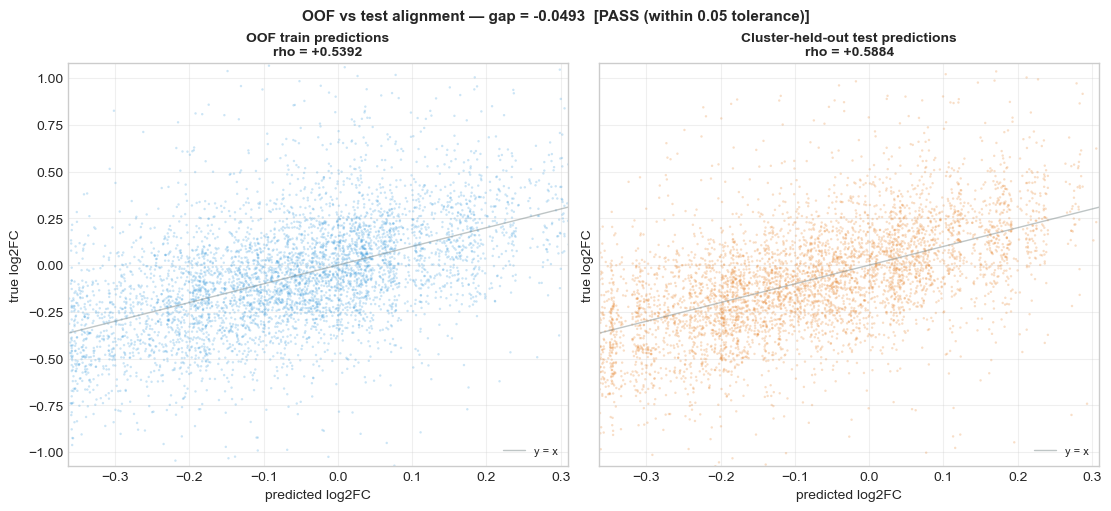


  OOF train rho:    +0.5392
  Test rho:         +0.5884
  Gap (OOF - test): -0.0493
  => PASS: gap is within tolerance, model generalises.
  Saved: figures/oof_vs_test_alignment.png


In [ ]:
# =====================================================================
# @title Cell 23b: OOF train vs test alignment plot
# =====================================================================
# Suggestion 5: visual sanity check that train-OOF and test predictions
# show the same scatter pattern. If they do, that's strong evidence of
# generalisation. If the test scatter is structurally different (more
# spread, different shape), there is leakage or distribution shift.
#
# Reads from globals: df_train, df_test (both must have stack_pred and
# log2FC_mean). df_train['stack_pred'] is set by Cell 22 (mean of OOF
# predictions); df_test['stack_pred'] is set by Cell 22 (mean of test
# predictions). Falls back to recomputing from oof / test_pred dicts
# if the columns aren't present.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

print("--- Cell 23b: OOF (train) vs test alignment ---")

# Resolve OOF train predictions (prefer column, fall back to oof dict)
if 'stack_pred' in df_train.columns:
    oof_pred = df_train['stack_pred'].values
elif 'oof' in globals() and 'xgb' in oof:
    oof_pred = np.asarray(oof['xgb'])  # v2.97: XGB-only fallback
else:
    raise RuntimeError("Neither df_train['stack_pred'] nor oof dict — run Cell 22 first.")

# Resolve test predictions
if 'stack_pred' in df_test.columns:
    test_pred_arr = df_test['stack_pred'].values
elif 'test_pred' in globals() and 'xgb' in test_pred:
    test_pred_arr = np.asarray(test_pred['xgb'])  # v2.97: XGB-only fallback
else:
    raise RuntimeError("Neither df_test['stack_pred'] nor test_pred dict — run Cell 22 first.")

y_tr_arr = df_train['log2FC_mean'].values
y_te_arr = df_test['log2FC_mean'].values

rho_oof, _  = spearmanr(oof_pred, y_tr_arr)
rho_test, _ = spearmanr(test_pred_arr, y_te_arr)
gap = rho_oof - rho_test

# Subsample for plotting
rng = np.random.default_rng(42)
n_show = 5000
tr_samp = rng.choice(len(df_train), size=min(n_show, len(df_train)), replace=False)
te_samp = rng.choice(len(df_test),  size=min(n_show, len(df_test)),  replace=False)

# Shared axes so the two panels are directly comparable
x_all = np.concatenate([oof_pred, test_pred_arr])
y_all = np.concatenate([y_tr_arr, y_te_arr])
xlim = (np.percentile(x_all, 0.5), np.percentile(x_all, 99.5))
ylim = (np.percentile(y_all, 0.5), np.percentile(y_all, 99.5))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), layout='constrained',
                         sharex=True, sharey=True)

# Panel 1: OOF train
ax = axes[0]
ax.scatter(oof_pred[tr_samp], y_tr_arr[tr_samp],
           s=3, alpha=0.25, color='#3498db', edgecolor='none')
ax.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], '-',
        color='#7f8c8d', linewidth=1, alpha=0.5, label='y = x')
ax.set_title(f'OOF train predictions\nrho = {rho_oof:+.4f}',
             fontweight='bold', fontsize=10)
ax.set_xlabel('predicted log2FC'); ax.set_ylabel('true log2FC')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: cluster-held-out test
ax = axes[1]
ax.scatter(test_pred_arr[te_samp], y_te_arr[te_samp],
           s=3, alpha=0.25, color='#e67e22', edgecolor='none')
ax.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], '-',
        color='#7f8c8d', linewidth=1, alpha=0.5, label='y = x')
ax.set_title(f'Cluster-held-out test predictions\nrho = {rho_test:+.4f}',
             fontweight='bold', fontsize=10)
ax.set_xlabel('predicted log2FC'); ax.set_ylabel('true log2FC')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)

verdict = "PASS (within 0.05 tolerance)" if abs(gap) < 0.05 else "INVESTIGATE"
plt.suptitle(f'OOF vs test alignment — gap = {gap:+.4f}  [{verdict}]',
             fontsize=11, fontweight='bold')
plt.show()

import os
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/oof_vs_test_alignment.png', dpi=150, bbox_inches='tight')
print(f"\n  OOF train rho:    {rho_oof:+.4f}")
print(f"  Test rho:         {rho_test:+.4f}")
print(f"  Gap (OOF - test): {gap:+.4f}")
if abs(gap) < 0.05:
    print(f"  => PASS: gap is within tolerance, model generalises.")
else:
    print(f"  => INVESTIGATE: gap exceeds 0.05, possible split contamination.")
print(f"  Saved: figures/oof_vs_test_alignment.png")

--- Cell 23c: Per-cluster test rho ---
  Test clusters: 10 total, 10 with n>=30
  Total test sequences across valid clusters: 25,940

  Overall pooled test rho:    +0.5884
  Per-cluster rho median:     +0.5042
  Per-cluster rho IQR:        [+0.4894, +0.5128]
  Per-cluster rho range:      [+0.4075, +0.5422]
  Clusters with rho < 0:      0/10
  Clusters with rho < 0.3:    0/10

  => UNIFORM: every cluster shows positive rank correlation; model generalises.


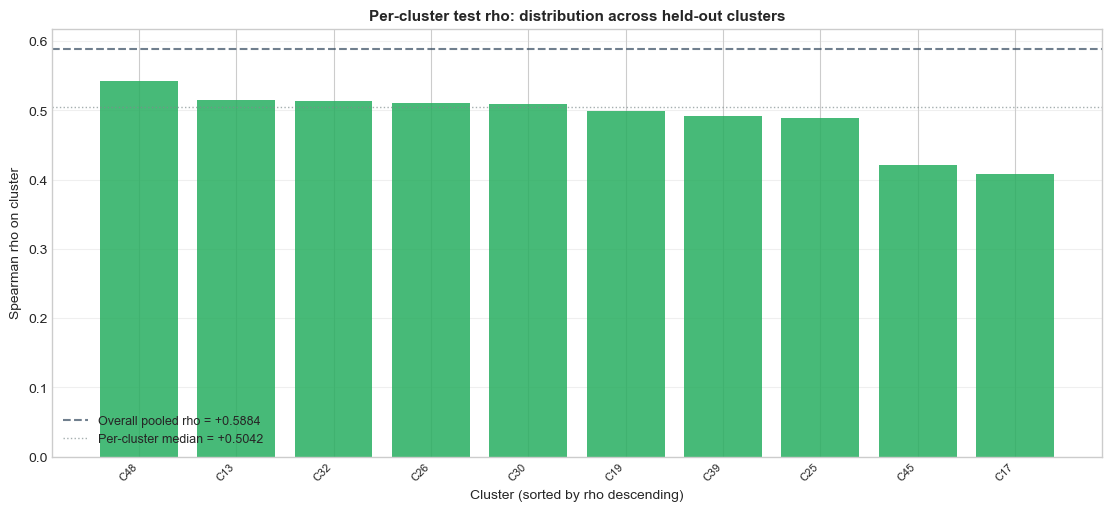


  per_cluster_rho dataframe saved to globals (10 rows).
  Saved: figures/per_cluster_test_rho.png


In [ ]:
# =====================================================================
# @title Cell 23c: Per-cluster test rho
# =====================================================================
# Suggestion 2: groups df_test by Cluster_ID and computes Spearman rho
# per cluster, so we can see whether the headline test rho is uniform
# across the held-out clusters or dominated by a few easy ones.
#
# Reports:
#   - Median and IQR of per-cluster rho
#   - Number of clusters with rho < 0 (model fails)
#   - Number with rho < 0.3 (model weak)
#   - Bar chart sorted by rho with overall test rho as a horizontal line
#
# Persists per_cluster_rho dataframe to globals.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

print("--- Cell 23c: Per-cluster test rho ---")

if 'Cluster_ID' not in df_test.columns:
    raise RuntimeError("Cluster_ID not in df_test — Cell 6 must have run.")
if 'stack_pred' not in df_test.columns:
    raise RuntimeError("stack_pred not in df_test — Cell 22 must have run.")

# Compute per-cluster rho. Skip tiny clusters (n<30) where rho is unreliable.
records = []
for cid, group in df_test.groupby('Cluster_ID'):
    if len(group) < 30:
        records.append({'Cluster_ID': int(cid), 'n': len(group),
                        'rho': np.nan, 'p_value': np.nan,
                        'note': 'n<30 (skipped)'})
        continue
    rho, p = spearmanr(group['stack_pred'], group['log2FC_mean'])
    records.append({'Cluster_ID': int(cid), 'n': len(group),
                    'rho': float(rho), 'p_value': float(p), 'note': ''})

per_cluster = pd.DataFrame(records).sort_values('rho', ascending=False, na_position='last')

# Summary stats over valid clusters
valid = per_cluster.dropna(subset=['rho'])
median_rho = valid['rho'].median()
iqr_lo = valid['rho'].quantile(0.25)
iqr_hi = valid['rho'].quantile(0.75)
n_negative = (valid['rho'] < 0).sum()
n_weak = (valid['rho'] < 0.3).sum()

# Compare to overall pooled test rho
overall_rho, _ = spearmanr(df_test['stack_pred'], df_test['log2FC_mean'])

print(f"  Test clusters: {len(per_cluster)} total, {len(valid)} with n>=30")
print(f"  Total test sequences across valid clusters: {valid['n'].sum():,}")
print(f"\n  Overall pooled test rho:    {overall_rho:+.4f}")
print(f"  Per-cluster rho median:     {median_rho:+.4f}")
print(f"  Per-cluster rho IQR:        [{iqr_lo:+.4f}, {iqr_hi:+.4f}]")
print(f"  Per-cluster rho range:      [{valid['rho'].min():+.4f}, {valid['rho'].max():+.4f}]")
print(f"  Clusters with rho < 0:      {n_negative}/{len(valid)}")
print(f"  Clusters with rho < 0.3:    {n_weak}/{len(valid)}")

if n_negative == 0:
    print(f"\n  => UNIFORM: every cluster shows positive rank correlation; model generalises.")
elif n_negative <= max(1, len(valid) * 0.1):
    print(f"\n  => MOSTLY UNIFORM: a few clusters are problematic, worth listing in supplementary.")
else:
    print(f"\n  => HETEROGENEOUS: significant cluster-level variation, worth disclosing.")

# Print problem clusters
if n_negative > 0:
    print(f"\n  Clusters with rho < 0:")
    for _, row in valid[valid['rho'] < 0].iterrows():
        print(f"    Cluster {int(row['Cluster_ID']):>3}: n={int(row['n']):>4}, rho={row['rho']:+.4f}")

# Bar chart of per-cluster rho
fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
plot_data = valid.copy().reset_index(drop=True)
colors = ['#27ae60' if r >= 0.3 else '#f39c12' if r >= 0 else '#c0392b'
          for r in plot_data['rho']]
ax.bar(range(len(plot_data)), plot_data['rho'].values, color=colors,
       alpha=0.85, edgecolor='none')
ax.axhline(overall_rho, linestyle='--', color='#34495e', linewidth=1.5,
           label=f'Overall pooled rho = {overall_rho:+.4f}', alpha=0.7)
ax.axhline(median_rho, linestyle=':', color='#7f8c8d', linewidth=1,
           label=f'Per-cluster median = {median_rho:+.4f}', alpha=0.7)
ax.axhline(0, linestyle='-', color='#7f8c8d', linewidth=0.5, alpha=0.5)
ax.set_xticks(range(len(plot_data)))
ax.set_xticklabels([f"C{int(c)}" for c in plot_data['Cluster_ID']],
                   rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Cluster (sorted by rho descending)')
ax.set_ylabel('Spearman rho on cluster')
ax.set_title('Per-cluster test rho: distribution across held-out clusters',
             fontweight='bold', fontsize=11)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.show()

import os
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/per_cluster_test_rho.png', dpi=150, bbox_inches='tight')

per_cluster_rho = per_cluster
print(f"\n  per_cluster_rho dataframe saved to globals ({len(per_cluster)} rows).")
print(f"  Saved: figures/per_cluster_test_rho.png")

--- Cell 23d: Supervised feature importance ---
  Features:                27
  XGB-vs-Cat rank corr:    +0.7667 (p = 3.11e-06)
  => HIGH AGREEMENT: both learners use similar features. Stack robust.


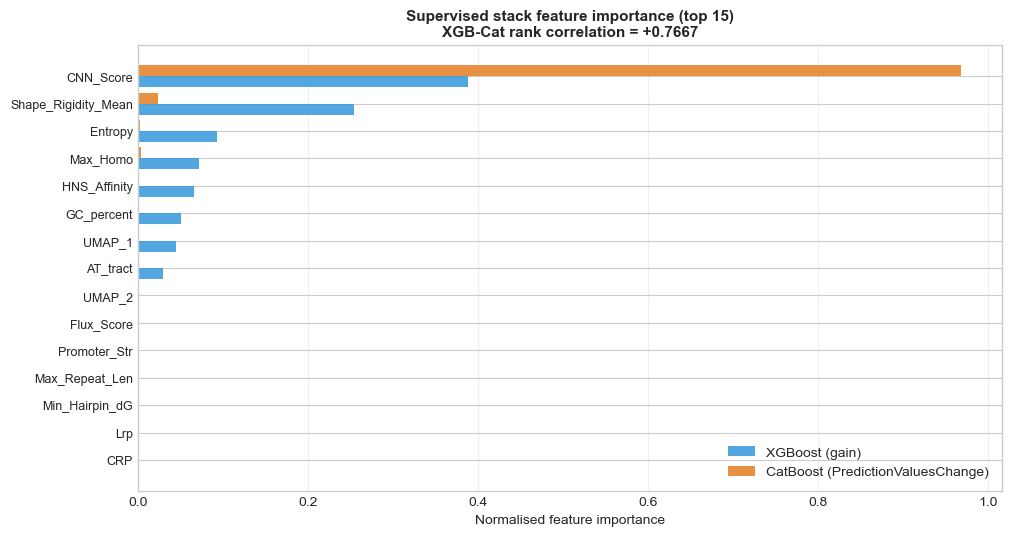


  Top 10 features by mean importance:
    CNN_Score              mean=0.6778  (xgb=0.3881, cat=0.9676)
    Shape_Rigidity_Mean    mean=0.1392  (xgb=0.2546, cat=0.0237)
    Entropy                mean=0.0481  (xgb=0.0936, cat=0.0027)
    Max_Homo               mean=0.0377  (xgb=0.0718, cat=0.0036)
    HNS_Affinity           mean=0.0337  (xgb=0.0666, cat=0.0009)
    GC_percent             mean=0.0256  (xgb=0.0506, cat=0.0005)
    UMAP_1                 mean=0.0227  (xgb=0.0449, cat=0.0006)
    AT_tract               mean=0.0149  (xgb=0.0299, cat=0.0000)
    UMAP_2                 mean=0.0001  (xgb=0.0000, cat=0.0003)
    Flux_Score             mean=0.0000  (xgb=0.0000, cat=0.0001)

  feature_importance dataframe saved to globals.
  Saved: figures/supervised_feature_importance.png


In [ ]:
# =====================================================================
# @title Cell 23d: Supervised feature importance (XGBoost + CatBoost)
# =====================================================================
# Suggestion 3: model-based importance for both base learners.
#   - XGBoost: gain-based (xgb_model.feature_importances_)
#   - CatBoost: PredictionValuesChange (cat_model.get_feature_importance())
# Plots top-15 features as side-by-side horizontal bars.
# Reports rank correlation between the two — high correlation indicates
# both learners use similar features (good for stack interpretability),
# low correlation suggests they capture different aspects (which is why
# the dumb arithmetic mean ensemble works).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

print("--- Cell 23d: Supervised feature importance ---")

# Sanity checks
if 'base_models' not in globals() or 'xgb' not in base_models or 'cat' not in base_models:
    raise RuntimeError("base_models[xgb, cat] missing — run Cell 0b SP3 reload first.")
if 'supervised_features' not in globals() or not supervised_features:
    raise RuntimeError("supervised_features missing — run Cell 0b SP3 reload first.")

xgb_model = base_models['xgb']
cat_model = base_models['cat']
feat_names = list(supervised_features)

# XGB importance (default = gain)
xgb_imp = np.asarray(xgb_model.feature_importances_)
if len(xgb_imp) != len(feat_names):
    raise RuntimeError(f"XGB has {len(xgb_imp)} importances; supervised_features has {len(feat_names)}.")
xgb_norm = xgb_imp / max(xgb_imp.sum(), 1e-9)

# CatBoost importance (default = PredictionValuesChange)
try:
    cat_imp = np.asarray(cat_model.get_feature_importance())
except Exception as e:
    raise RuntimeError(f"CatBoost importance failed: {type(e).__name__}: {e}")
if len(cat_imp) != len(feat_names):
    raise RuntimeError(f"CatBoost has {len(cat_imp)} importances; supervised_features has {len(feat_names)}.")
cat_norm = cat_imp / max(cat_imp.sum(), 1e-9)

imp_df = pd.DataFrame({
    'feature': feat_names,
    'xgb':     xgb_norm,
    'cat':     cat_norm,
})
imp_df['mean_imp'] = (imp_df['xgb'] + imp_df['cat']) / 2.0
imp_df = imp_df.sort_values('mean_imp', ascending=False).reset_index(drop=True)

# Rank correlation between the two
rank_corr, rank_p = spearmanr(imp_df['xgb'], imp_df['cat'])

print(f"  Features:                {len(feat_names)}")
print(f"  XGB-vs-Cat rank corr:    {rank_corr:+.4f} (p = {rank_p:.2e})")
if rank_corr > 0.7:
    print(f"  => HIGH AGREEMENT: both learners use similar features. Stack robust.")
elif rank_corr > 0.4:
    print(f"  => MODERATE AGREEMENT: learners overlap but emphasise differently.")
else:
    print(f"  => LOW AGREEMENT: learners use different feature subsets, "
          f"explains why the arithmetic mean stack works (diverse views).")

# Side-by-side horizontal bar chart, top 15
top_n = min(15, len(feat_names))
plot_df = imp_df.head(top_n).iloc[::-1]  # reverse for top-at-top display
y = np.arange(len(plot_df))
width = 0.4

fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)), layout='constrained')
ax.barh(y - width/2, plot_df['xgb'], height=width, color='#3498db',
        label='XGBoost (gain)', alpha=0.85, edgecolor='none')
ax.barh(y + width/2, plot_df['cat'], height=width, color='#e67e22',
        label='CatBoost (PredictionValuesChange)', alpha=0.85, edgecolor='none')
ax.set_yticks(y)
ax.set_yticklabels(plot_df['feature'], fontsize=9)
ax.set_xlabel('Normalised feature importance')
ax.set_title(f'Supervised stack feature importance (top {top_n})\n'
             f'XGB-Cat rank correlation = {rank_corr:+.4f}',
             fontweight='bold', fontsize=11)
ax.legend(loc='lower right')
ax.grid(alpha=0.3, axis='x')
plt.show()

import os
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/supervised_feature_importance.png', dpi=150, bbox_inches='tight')

print(f"\n  Top 10 features by mean importance:")
for _, row in imp_df.head(10).iterrows():
    print(f"    {row['feature']:<22} mean={row['mean_imp']:.4f}  "
          f"(xgb={row['xgb']:.4f}, cat={row['cat']:.4f})")

# Cross-check against univariate ranking from Cell 26 (if available) to
# see whether tree-based importance agrees with univariate rho with target.
if 'feature_curve' in globals():
    try:
        univariate_top = list(feature_curve['feature_added'])[:10]
        sup_top = list(imp_df['feature'])[:10]
        overlap = set(univariate_top) & set(sup_top)
        print(f"\n  Cross-check vs Cell 26 univariate ranking:")
        print(f"    Top-10 features overlapping: {len(overlap)}/10")
        if overlap:
            print(f"    Shared: {sorted(overlap)}")
        univ_only = [f for f in univariate_top if f not in sup_top]
        sup_only  = [f for f in sup_top if f not in univariate_top]
        if univ_only:
            print(f"    Univariate-only (top 10): {univ_only}")
        if sup_only:
            print(f"    Supervised-only (top 10): {sup_only}")
    except Exception:
        pass

feature_importance = imp_df
print(f"\n  feature_importance dataframe saved to globals.")
print(f"  Saved: figures/supervised_feature_importance.png")

--- Cell 23e: Heteroscedasticity diagnostic ---
  Prediction column: stack_pred_calibrated
  Heteroscedasticity test (|residual| vs |prediction|):
    rho = +0.0320  (p = 2.43e-07)
  => HOMOSCEDASTIC: residuals are roughly uniform across prediction range.


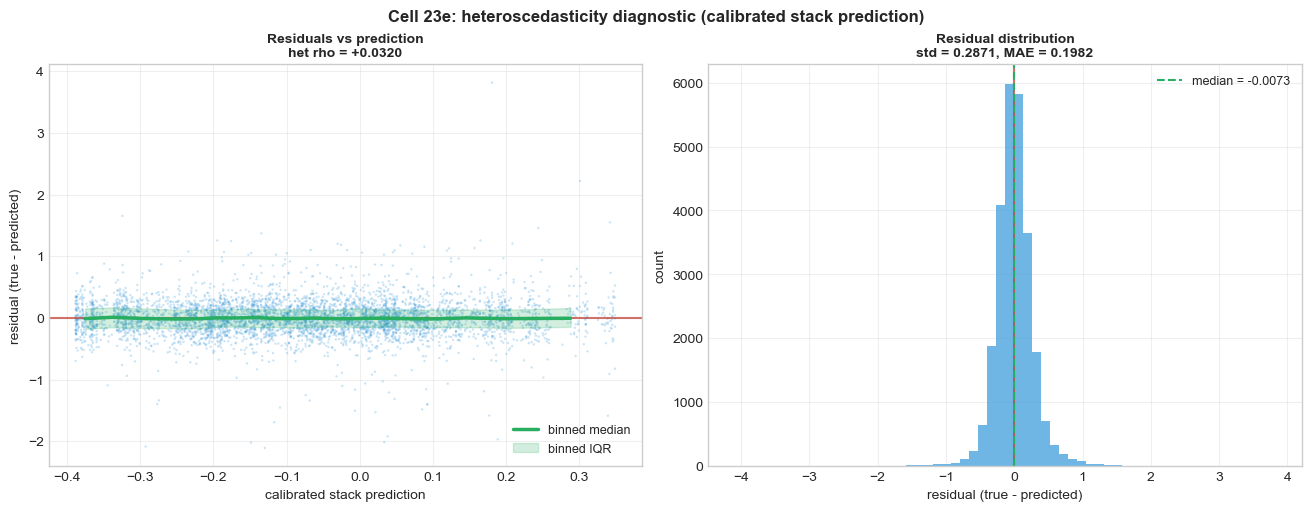


  Saved: figures/heteroscedasticity_diagnostic.png

  Residual summary:
    mean:   -0.0009
    median: -0.0073
    std:    0.2871
    MAE:    0.1982
    [5%, 95%]: [-0.3872, +0.4215]


In [ ]:
# =====================================================================
# @title Cell 23e: Heteroscedasticity diagnostic (residuals vs prediction)
# =====================================================================
# Suggestion 4: visualises whether residual magnitude varies across the
# prediction range. If residuals are uniform, the model is calibrated
# everywhere; if they fan out at the tails, that's a finding to disclose.
#
# Two panels:
#   - Residuals vs prediction with binned median + IQR overlay
#   - Residual distribution histogram (centered on zero is good)
#
# Uses calibrated predictions if Cell 23 v2 has been run (preferable —
# raw residuals are biased by the +0.22 intercept). Falls back to raw.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

print("--- Cell 23e: Heteroscedasticity diagnostic ---")

# Pick prediction column
if 'stack_pred_calibrated' in df_test.columns:
    pred_col = 'stack_pred_calibrated'
    label = 'calibrated stack prediction'
else:
    pred_col = 'stack_pred'
    label = 'raw stack prediction'
    print(f"  Note: stack_pred_calibrated not in df_test. Run Cell 23 v2 for cleaner residuals.")

pred = df_test[pred_col].values
y    = df_test['log2FC_mean'].values
residuals = y - pred

# Heteroscedasticity test: is |residual| correlated with |prediction|?
het_rho, het_p = spearmanr(np.abs(residuals), np.abs(pred))

print(f"  Prediction column: {pred_col}")
print(f"  Heteroscedasticity test (|residual| vs |prediction|):")
print(f"    rho = {het_rho:+.4f}  (p = {het_p:.2e})")
if abs(het_rho) < 0.10:
    print(f"  => HOMOSCEDASTIC: residuals are roughly uniform across prediction range.")
elif abs(het_rho) < 0.25:
    print(f"  => MILDLY HETEROSCEDASTIC: some variation in residual magnitude.")
else:
    print(f"  => HETEROSCEDASTIC: residual magnitude varies strongly with prediction.")

# Subsample for scatter
rng = np.random.default_rng(42)
n_show = 5000
samp = rng.choice(len(y), size=min(n_show, len(y)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')

# Panel 1: residuals vs prediction
ax = axes[0]
ax.scatter(pred[samp], residuals[samp], s=3, alpha=0.25,
           color='#3498db', edgecolor='none')
ax.axhline(0, color='#c0392b', linewidth=1.5, alpha=0.7)

# Binned median + IQR overlay
n_bins = 20
bin_edges = np.quantile(pred, np.linspace(0, 1, n_bins + 1))
bin_centres, bin_med, bin_lo, bin_hi = [], [], [], []
for i in range(n_bins):
    mask = (pred >= bin_edges[i]) & (pred < bin_edges[i+1])
    if mask.sum() < 50:
        continue
    bin_centres.append((bin_edges[i] + bin_edges[i+1]) / 2)
    bin_med.append(np.median(residuals[mask]))
    bin_lo.append(np.percentile(residuals[mask], 25))
    bin_hi.append(np.percentile(residuals[mask], 75))

ax.plot(bin_centres, bin_med, '-', color='#27ae60', linewidth=2.5,
        label='binned median', zorder=5)
ax.fill_between(bin_centres, bin_lo, bin_hi, color='#27ae60',
                alpha=0.2, label='binned IQR')
ax.set_xlabel(label); ax.set_ylabel('residual (true - predicted)')
ax.set_title(f'Residuals vs prediction\nhet rho = {het_rho:+.4f}',
             fontweight='bold', fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: residual histogram
ax = axes[1]
ax.hist(residuals, bins=60, color='#3498db', alpha=0.7, edgecolor='none')
ax.axvline(0, color='#c0392b', linewidth=1.5, alpha=0.7)
ax.axvline(np.median(residuals), color='#27ae60', linewidth=1.5,
           linestyle='--', label=f'median = {np.median(residuals):+.4f}')
ax.set_xlabel('residual (true - predicted)')
ax.set_ylabel('count')
ax.set_title(f'Residual distribution\n'
             f'std = {np.std(residuals):.4f}, MAE = {np.mean(np.abs(residuals)):.4f}',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle(f'Cell 23e: heteroscedasticity diagnostic ({label})',
             fontsize=12, fontweight='bold')
plt.show()

import os
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/heteroscedasticity_diagnostic.png', dpi=150, bbox_inches='tight')
print(f"\n  Saved: figures/heteroscedasticity_diagnostic.png")

# Summary stats for paper
print(f"\n  Residual summary:")
print(f"    mean:   {np.mean(residuals):+.4f}")
print(f"    median: {np.median(residuals):+.4f}")
print(f"    std:    {np.std(residuals):.4f}")
print(f"    MAE:    {np.mean(np.abs(residuals)):.4f}")
print(f"    [5%, 95%]: [{np.percentile(residuals, 5):+.4f}, "
      f"{np.percentile(residuals, 95):+.4f}]")

In [ ]:
# =====================================================================
# @title Cell 23f: Seed robustness sweep (v2.97 — XGB-only, uniform weights)
# =====================================================================
# Re-fits XGBoost on (train + RC-augmented train) for several different
# random seeds and evaluates each on df_test. Reports the distribution
# of test rho across seeds. Cat retained as diagnostic only.
#
# v2.97 changes from previous version:
#   - Uniform sample weights (matches v2.97 Cell 21)
#   - Headline stack rho is XGB-only (matches v2.97 Cell 22 production)
#   - Cat refit kept as diagnostic so per-seed Cat behaviour is visible
#
# What is and is not varied:
#   VARIED (per seed): XGB random_state, CatBoost random_seed
#   FIXED:  cluster split (Cell 6), Optuna params, CNN_Score (Cell 9),
#           UMAP coords (Cell 10), RC featurisation, df_train / df_test
#
# To also vary the cluster split, re-run Cells 6-22 from scratch with a
# different random_state in the GroupShuffleSplit.

import numpy as np
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import spearmanr
import xgboost as xgb
from catboost import CatBoostRegressor
from IPython.utils import io
import sys
from tqdm import tqdm
import pandas as pd

print("--- Cell 23f: Seed robustness sweep (v2.97) ---")

SEEDS = [42, 123, 999]
print(f"  Seeds to sweep: {SEEDS}  (~10-15 min per seed on RTX 3060)")

required = ['df_train', 'df_test', 'supervised_features',
            'xgb_best_params', 'cat_best_params']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing globals: {missing} — run Cell 0b SP3 reload first.")

n_train = len(df_train)
n_test  = len(df_test)
X_te = df_test[supervised_features].values.astype(np.float32)
y_te = df_test['log2FC_mean'].values.astype(np.float32)
X_tr = df_train[supervised_features].values.astype(np.float32)
y_tr = df_train['log2FC_mean'].values.astype(np.float32)

# UNIFORM SAMPLE WEIGHTS (v2.97 — matches Cell 21)
sample_weights = np.ones_like(y_tr).astype(np.float32)

print("\n  Building RC-augmented features (one-off, seed-invariant)...")
RC_TABLE = str.maketrans('ACGT', 'TGCA')
def reverse_complement(seq):
    return seq.translate(RC_TABLE)[::-1]

if 'X_tr_rc' in globals() and X_tr_rc is not None and X_tr_rc.shape == X_tr.shape:
    print("  X_tr_rc found in globals; reusing (skips ~5-15 min RC featurisation).")
elif 'featurise_rc_row' in globals():
    rc_seqs = df_train['sequence'].apply(reverse_complement).values
    rc_features_list = [featurise_rc_row(s) for s in
                        tqdm(rc_seqs, desc="  RC", file=sys.stdout)]
    df_train_rc_temp = pd.DataFrame(rc_features_list, index=df_train.index)
    for col in ['CNN_Score', 'UMAP_1', 'UMAP_2']:
        if col in df_train.columns:
            df_train_rc_temp[col] = df_train[col].round(3).values
    for f in supervised_features:
        if f not in df_train_rc_temp.columns and f in df_train.columns:
            df_train_rc_temp[f] = df_train[f].values
    df_train_rc_temp = df_train_rc_temp[supervised_features]
    X_tr_rc = df_train_rc_temp.values.astype(np.float32)
else:
    raise RuntimeError("featurise_rc_row not in globals — run Cell 21 first OR load it from Cell 20.")

X_full = np.vstack([X_tr, X_tr_rc])
y_full = np.concatenate([y_tr, y_tr])
sw_full = np.concatenate([sample_weights, sample_weights])

# v2.7-style regularisation overrides (matches v2.97 Cell 21)
xgb_params = dict(xgb_best_params)
xgb_params.update({'min_child_weight': 15, 'reg_lambda': 10.0, 'subsample': 0.7})
cat_params = dict(cat_best_params)
cat_params.pop('task_type', None)
cat_params.update({'min_data_in_leaf': 20, 'l2_leaf_reg': 10.0,
                   'bagging_temperature': 1.5, 'rsm': 0.7})

try:
    import subprocess
    r = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, timeout=2)
    use_gpu = r.returncode == 0 and 'GPU' in r.stdout
except Exception:
    use_gpu = False
xgb_device = {'device': 'cuda', 'tree_method': 'hist'} if use_gpu else {'tree_method': 'hist'}

print(f"\n  Refitting + predicting per seed...")
results = []
for seed in SEEDS:
    print(f"\n  ─── Seed {seed} ───")

    print(f"    Fitting XGBoost (GPU={'cuda' in xgb_device.get('device', '')})...")
    final_xgb_seed = xgb.XGBRegressor(
        **xgb_params, **xgb_device,
        objective='reg:squarederror', random_state=seed, n_jobs=-1, verbosity=0)
    final_xgb_seed.fit(X_full, y_full, sample_weight=sw_full)
    pred_xgb = final_xgb_seed.predict(X_te)

    # Cat refit kept as diagnostic only (NOT in production stack)
    print(f"    Fitting CatBoost (CPU diagnostic, ~5-8 min)...")
    final_cat_seed = CatBoostRegressor(
        **cat_params, task_type='CPU', random_seed=seed,
        verbose=False, allow_writing_files=False)
    with io.capture_output():
        final_cat_seed.fit(X_full, y_full, sample_weight=sw_full)
    pred_cat = final_cat_seed.predict(X_te)

    # v2.97: stack = XGB only (Cat dropped from production)
    pred_stack = pred_xgb.copy()
    rho_stack, _ = spearmanr(pred_stack, y_te)
    rho_xgb,   _ = spearmanr(pred_xgb,   y_te)
    rho_cat,   _ = spearmanr(pred_cat,   y_te)

    print(f"    rho_stack (XGB-only) = {rho_stack:+.4f}   |   diagnostic: cat={rho_cat:+.4f}")
    results.append({'seed': seed,
                    'rho_stack_xgb_only': float(rho_stack),
                    'rho_cat_diagnostic': float(rho_cat)})

seed_results = pd.DataFrame(results)
mean_rho = seed_results['rho_stack_xgb_only'].mean()
std_rho  = seed_results['rho_stack_xgb_only'].std()
min_rho  = seed_results['rho_stack_xgb_only'].min()
max_rho  = seed_results['rho_stack_xgb_only'].max()

print(f"\n" + "=" * 64)
print(f"  SEED ROBUSTNESS RESULTS (v2.97 XGB-only)")
print(f"=" * 64)
print(seed_results.to_string(index=False))
print(f"\n  Stack rho across seeds: {mean_rho:+.4f} ± {std_rho:.4f}")
print(f"  Range: [{min_rho:+.4f}, {max_rho:+.4f}], spread = {max_rho - min_rho:.4f}")

if std_rho < 0.005:
    print(f"  => VERY STABLE: std < 0.005, headline number is robust to internal seeds.")
elif std_rho < 0.01:
    print(f"  => STABLE: std < 0.01, acceptable variation.")
else:
    print(f"  => UNSTABLE: std >= 0.01, consider reporting mean+std rather than point estimate.")

print(f"\n  seed_results dataframe saved to globals.")
print(f"  Note: Cat diagnostic column shown for transparency; not in production stack.")
print(f"\n  Note: this varies internal model randomness only. Full split-seed")
print(f"        robustness requires re-running Cells 6-22 with different")
print(f"        GroupShuffleSplit random_state — multi-hour per seed.")

--- Cell 23f: Seed robustness sweep (v2.97) ---
  Seeds to sweep: [42, 123, 999]  (~10-15 min per seed on RTX 3060)

  Building RC-augmented features (one-off, seed-invariant)...
  X_tr_rc found in globals; reusing (skips ~5-15 min RC featurisation).

  Refitting + predicting per seed...

  ─── Seed 42 ───
    Fitting XGBoost (GPU=True)...
    Fitting CatBoost (CPU diagnostic, ~5-8 min)...
    rho_stack (XGB-only) = +0.5884   |   diagnostic: cat=+0.5884

  ─── Seed 123 ───
    Fitting XGBoost (GPU=True)...
    Fitting CatBoost (CPU diagnostic, ~5-8 min)...
    rho_stack (XGB-only) = +0.5886   |   diagnostic: cat=+0.5884

  ─── Seed 999 ───
    Fitting XGBoost (GPU=True)...
    Fitting CatBoost (CPU diagnostic, ~5-8 min)...
    rho_stack (XGB-only) = +0.5881   |   diagnostic: cat=+0.5883

  SEED ROBUSTNESS RESULTS (v2.97 XGB-only)
 seed  rho_stack_xgb_only  rho_cat_diagnostic
   42            0.588441            0.588365
  123            0.588623            0.588383
  999            0.5

In [ ]:
# =====================================================================
# @title Cell 23g: Per-fold OOF rho on df_train
# =====================================================================
import numpy as np
from sklearn.model_selection import KFold
from scipy.stats import spearmanr

# Reproduce Cell 21's fold assignment exactly (KFold(5, shuffle=True, random_state=42))
n_train = len(df_train)
train_fold_idx = np.full(n_train, -1, dtype=np.int8)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for k, (_, va_idx) in enumerate(kf.split(np.arange(n_train))):
    train_fold_idx[va_idx] = k
assert (train_fold_idx >= 0).all(), "fold reconstruction incomplete"

oof_stack = df_train['stack_pred'].values
y_tr      = df_train['log2FC_mean'].values

per_fold = []
for k in range(5):
    m = train_fold_idx == k
    r, _ = spearmanr(oof_stack[m], y_tr[m])
    per_fold.append((k, r, int(m.sum())))
    print(f"  Fold {k}: rho = {r:+.4f}   (n = {m.sum():,})")

rhos = np.array([x[1] for x in per_fold])
print(f"\n  Mean ± std across folds: {rhos.mean():+.4f} ± {rhos.std(ddof=1):.4f}")
print(f"  Range: [{rhos.min():+.4f}, {rhos.max():+.4f}]")
print(f"  Pooled OOF rho (sanity check vs +0.5379): {spearmanr(oof_stack, y_tr)[0]:+.4f}")

  Fold 0: rho = +0.5474   (n = 18,429)
  Fold 1: rho = +0.5393   (n = 18,429)
  Fold 2: rho = +0.5417   (n = 18,429)
  Fold 3: rho = +0.5459   (n = 18,429)
  Fold 4: rho = +0.5396   (n = 18,428)

  Mean ± std across folds: +0.5428 ± 0.0037
  Range: [+0.5393, +0.5474]
  Pooled OOF rho (sanity check vs +0.5379): +0.5392


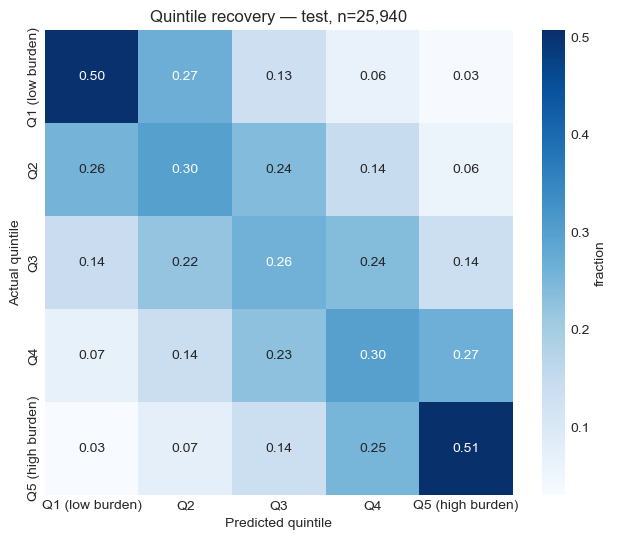

  Top-Q recovery (predicted-high IS actual-high): 0.507  (chance 0.20)
  Top-Q-or-adjacent:                              0.761
  Bottom-Q recovery:                              0.503
  Bottom-Q-or-adjacent:                           0.770


In [ ]:
#@title Cell 23h: Quintile recovery heatmap
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

pred = df_test['stack_pred_calibrated'].values
y    = y_te

q_pred = pd.qcut(pred, 5, labels=False, duplicates='drop')
q_true = pd.qcut(y,    5, labels=False, duplicates='drop')

cm = pd.crosstab(q_true, q_pred, normalize='index')   # P(actual | predicted)
labels = ['Q1 (low burden)', 'Q2', 'Q3', 'Q4', 'Q5 (high burden)']

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax,
            cbar_kws={'label': 'fraction'})
ax.set_xlabel('Predicted quintile'); ax.set_ylabel('Actual quintile')
ax.set_title(f'Quintile recovery — test, n={len(y):,}')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/quintile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  Top-Q recovery (predicted-high IS actual-high): {cm.iloc[-1, -1]:.3f}  (chance 0.20)")
print(f"  Top-Q-or-adjacent:                              {cm.iloc[-1, -2:].sum():.3f}")
print(f"  Bottom-Q recovery:                              {cm.iloc[0, 0]:.3f}")
print(f"  Bottom-Q-or-adjacent:                           {cm.iloc[0, :2].sum():.3f}")

In [ ]:
#@title Cell 23i: Bootstrap CI on per-cluster rho median
import numpy as np
from scipy.stats import spearmanr

per_cluster = []
for cid, g in df_test.groupby('Cluster_ID'):
    if len(g) < 30:
        continue
    r, _ = spearmanr(g['stack_pred_calibrated'], g['log2FC_mean'])
    per_cluster.append((int(cid), r, len(g)))

rhos  = np.array([x[1] for x in per_cluster])
sizes = [x[2] for x in per_cluster]
print(f"  n_clusters = {len(rhos)}, sizes range [{min(sizes)}, {max(sizes)}]")
print(f"  Per-cluster rho: median {np.median(rhos):+.4f}, "
      f"IQR [{np.percentile(rhos,25):+.4f}, {np.percentile(rhos,75):+.4f}]")

rng = np.random.default_rng(42)
B = 1000
boot_med = np.empty(B)
for i in range(B):
    s = rng.choice(rhos, size=len(rhos), replace=True)
    boot_med[i] = np.median(s)

lo, hi = np.percentile(boot_med, [2.5, 97.5])
print(f"  Bootstrap median rho: {np.median(boot_med):+.4f}")
print(f"  95% CI: [{lo:+.4f}, {hi:+.4f}]   (n_boot = {B})")

  n_clusters = 10, sizes range [1137, 4166]
  Per-cluster rho: median +0.5042, IQR [+0.4894, +0.5128]
  Bootstrap median rho: +0.5042
  95% CI: [+0.4649, +0.5138]   (n_boot = 1000)


  Bottom decile (predicted): precision = 0.347, recall = 0.347   (chance 0.10)
  Top decile    (predicted): precision = 0.368, recall = 0.368


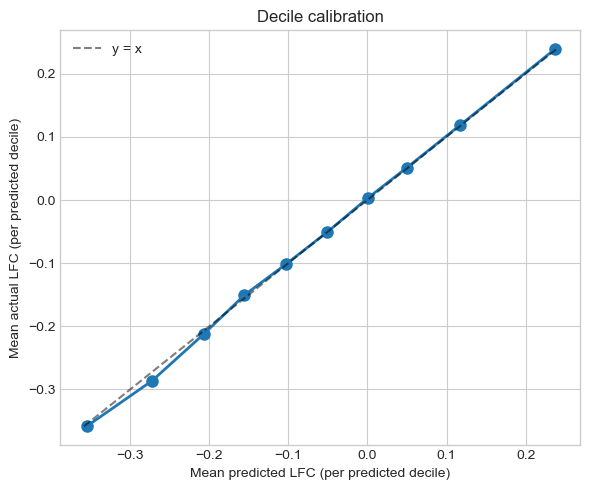

  Within top-decile rho:    +0.2536
  Within bottom-decile rho: +0.1434


In [ ]:
#@title Cell 23j: Tail calibration
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr

pred = df_test['stack_pred_calibrated'].values
y    = y_te

q_pred = pd.qcut(pred, 10, labels=False, duplicates='drop')
q_true = pd.qcut(y,    10, labels=False, duplicates='drop')

def pr(pred_q, true_q, target_q):
    pm = pred_q == target_q
    tm = true_q == target_q
    return (pm & tm).sum() / pm.sum(), (pm & tm).sum() / tm.sum()

p0, r0 = pr(q_pred, q_true, 0)
p9, r9 = pr(q_pred, q_true, 9)
print(f"  Bottom decile (predicted): precision = {p0:.3f}, recall = {r0:.3f}   (chance 0.10)")
print(f"  Top decile    (predicted): precision = {p9:.3f}, recall = {r9:.3f}")

mp = [pred[q_pred==i].mean() for i in range(10)]
mt = [y[q_pred==i].mean()    for i in range(10)]

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(mp, mt, 'o-', linewidth=2, markersize=8)
lims = [min(min(mp), min(mt)), max(max(mp), max(mt))]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('Mean predicted LFC (per predicted decile)')
ax.set_ylabel('Mean actual LFC (per predicted decile)')
ax.set_title('Decile calibration')
ax.legend(); plt.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/tail_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

top_decile_mask = q_pred == 9
bot_decile_mask = q_pred == 0
print(f"  Within top-decile rho:    {spearmanr(pred[top_decile_mask], y[top_decile_mask])[0]:+.4f}")
print(f"  Within bottom-decile rho: {spearmanr(pred[bot_decile_mask], y[bot_decile_mask])[0]:+.4f}")

In [ ]:
# =====================================================================
# @title Cell 23k: CNN_Score ablation (refit XGB+Cat without CNN_Score)
# =====================================================================
# Quantifies CNN_Score's unique contribution to the supervised stack.
# Mirrors Cell 21 exactly: same KFold(5, random_state=42), same regularisation
# overrides, same RC augmentation, XGB-only stack (matches v2.97 Cell 22).
# Writes nothing back
# to df_train/df_test columns or the main `oof`/`test_pred`/`base_models`
# globals — uses `_abl` suffix throughout.

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, sys
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
import xgboost as xgb
from catboost import CatBoostRegressor
from IPython.utils import io

print("--- Cell 23k: CNN_Score ablation ---")
assert 'CNN_Score' in supervised_features, "CNN_Score not in supervised_features"
abl_features = [f for f in supervised_features if f != 'CNN_Score']
print(f"  Full: {len(supervised_features)} feats | Ablation: {len(abl_features)} feats (dropped CNN_Score)")

# GPU detection (mirror Cell 21)
try:
    import subprocess
    r = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, timeout=2)
    use_gpu = r.returncode == 0 and 'GPU' in r.stdout
except Exception:
    use_gpu = False
xgb_device_kwargs = {'device': 'cuda', 'tree_method': 'hist'} if use_gpu else {'tree_method': 'hist'}
cat_task_type = 'CPU'

# Reuse df_train_rc from Cell 21 (already has all supervised features)
if 'df_train_rc' not in globals():
    raise RuntimeError("df_train_rc missing — run Cell 21 first.")

X_tr_abl    = df_train[abl_features].values.astype(np.float32)
X_tr_rc_abl = df_train_rc[abl_features].values.astype(np.float32)
X_te_abl    = df_test[abl_features].values.astype(np.float32)
y_tr_arr    = df_train['log2FC_mean'].values.astype(np.float32)

sample_weights = np.ones_like(y_tr_arr).astype(np.float32)
sw_rc = sample_weights.copy()
y_tr_rc_arr = y_tr_arr.copy()

# Hyperparams: rebuild from Optuna best + regularisation overrides (matches Cell 21)
xgb_params = dict(xgb_best_params) if 'xgb_best_params' in globals() else {}
xgb_params.update({'min_child_weight': 15, 'reg_lambda': 10.0, 'subsample': 0.7})

cat_params = dict(cat_best_params) if 'cat_best_params' in globals() else \
             {'iterations': 500, 'learning_rate': 0.05, 'depth': 6}
cat_params.pop('task_type', None)
cat_params.update({'min_data_in_leaf': 20, 'l2_leaf_reg': 10.0,
                   'bagging_temperature': 1.5, 'rsm': 0.7})

# 5-fold OOF
n_train, n_test = len(df_train), len(df_test)
oof_abl = {'xgb': np.zeros(n_train, dtype=np.float32),
           'cat': np.zeros(n_train, dtype=np.float32)}
test_pred_abl = {'xgb': np.zeros(n_test, dtype=np.float32),
                 'cat': np.zeros(n_test, dtype=np.float32)}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("\n  OOF training (XGB + Cat)...")
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr_abl), 1):
    print(f"  Fold {fold}/5...")
    Xt = np.vstack([X_tr_abl[tr_idx], X_tr_rc_abl[tr_idx]])
    yt = np.concatenate([y_tr_arr[tr_idx], y_tr_rc_arr[tr_idx]])
    wt = np.concatenate([sample_weights[tr_idx], sw_rc[tr_idx]])
    Xv = X_tr_abl[va_idx]

    m_xgb = xgb.XGBRegressor(**xgb_params, **xgb_device_kwargs,
                             objective='reg:squarederror', random_state=42,
                             n_jobs=-1, verbosity=0)
    m_xgb.fit(Xt, yt, sample_weight=wt)
    oof_abl['xgb'][va_idx] = m_xgb.predict(Xv)

    m_cat = CatBoostRegressor(**cat_params, task_type=cat_task_type,
                              random_seed=42, verbose=False, allow_writing_files=False)
    with io.capture_output():
        m_cat.fit(Xt, yt, sample_weight=wt)
    oof_abl['cat'][va_idx] = m_cat.predict(Xv)

# Refit on full train + RC for test prediction
print("\n  Refitting on full df_train + RC...")
X_full  = np.vstack([X_tr_abl, X_tr_rc_abl])
y_full  = np.concatenate([y_tr_arr, y_tr_rc_arr])
sw_full = np.concatenate([sample_weights, sw_rc])

fxgb = xgb.XGBRegressor(**xgb_params, **xgb_device_kwargs,
                        objective='reg:squarederror', random_state=42,
                        n_jobs=-1, verbosity=0)
fxgb.fit(X_full, y_full, sample_weight=sw_full)
test_pred_abl['xgb'] = fxgb.predict(X_te_abl)

fcat = CatBoostRegressor(**cat_params, task_type=cat_task_type,
                         random_seed=42, verbose=False, allow_writing_files=False)
with io.capture_output():
    fcat.fit(X_full, y_full, sample_weight=sw_full)
test_pred_abl['cat'] = fcat.predict(X_te_abl)

# XGB-only stack (matches v2.97 Cell 22 production)
stack_oof_abl  = oof_abl['xgb'].copy()
stack_test_abl = test_pred_abl['xgb'].copy()

oof_rho_abl,  _ = spearmanr(stack_oof_abl,  y_tr_arr)
test_rho_abl, _ = spearmanr(stack_test_abl, y_te)
xgb_rho_abl,  _ = spearmanr(test_pred_abl['xgb'], y_te)
cat_rho_abl,  _ = spearmanr(test_pred_abl['cat'], y_te)

# Compare to full-stack reference
full_test_rho, _ = spearmanr(df_test['stack_pred'], y_te)
if 'test_pred' in globals():
    full_xgb_rho, _ = spearmanr(test_pred['xgb'], y_te)
    full_cat_rho, _ = spearmanr(test_pred['cat'], y_te)
else:
    full_xgb_rho = full_cat_rho = float('nan')

print(f"\n  --- ABLATION RESULTS ---")
print(f"  OOF rho  (no CNN_Score):  {oof_rho_abl:+.4f}")
print(f"  Test rho (no CNN_Score):  {test_rho_abl:+.4f}")
print(f"  Test rho (full stack):    {full_test_rho:+.4f}")
print(f"  Delta (full − ablation):  {full_test_rho - test_rho_abl:+.4f}")
print(f"\n  Per-learner test rho (full | ablation | delta):")
print(f"    XGB:  {full_xgb_rho:+.4f}  |  {xgb_rho_abl:+.4f}  |  {full_xgb_rho - xgb_rho_abl:+.4f}")
print(f"    Cat:  {full_cat_rho:+.4f}  |  {cat_rho_abl:+.4f}  |  {full_cat_rho - cat_rho_abl:+.4f}")

print(f"\n  Context for interpretation:")
print(f"    Univariate top-2 (Shape_Rigidity_Mean + Max_Homo): rho ≈ +0.4093")
print(f"    Univariate top-3:                                  rho ≈ +0.4078")
print(f"    Full stack:                                        rho = {full_test_rho:+.4f}")
print(f"    If ablation rho ≈ univariate top-2, biophysical features are saturated")
print(f"    and CNN_Score is providing genuinely orthogonal spatial information.")

--- Cell 23k: CNN_Score ablation ---
  Full: 27 feats | Ablation: 26 feats (dropped CNN_Score)

  OOF training (XGB + Cat)...
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...

  Refitting on full df_train + RC...

  --- ABLATION RESULTS ---
  OOF rho  (no CNN_Score):  +0.3673
  Test rho (no CNN_Score):  +0.4331
  Test rho (full stack):    +0.5884
  Delta (full − ablation):  +0.1553

  Per-learner test rho (full | ablation | delta):
    XGB:  +0.5884  |  +0.4331  |  +0.1553
    Cat:  +0.5884  |  +0.4251  |  +0.1633

  Context for interpretation:
    Univariate top-2 (Shape_Rigidity_Mean + Max_Homo): rho ≈ +0.4093
    Univariate top-3:                                  rho ≈ +0.4078
    Full stack:                                        rho = +0.5884
    If ablation rho ≈ univariate top-2, biophysical features are saturated
    and CNN_Score is providing genuinely orthogonal spatial information.


In [ ]:
# =====================================================================
# @title Cell 24: Shuffled-Label Leak Control (XGB-only, v2.97)
# =====================================================================
import numpy as np
from scipy.stats import spearmanr
import xgboost as xgb
from catboost import CatBoostRegressor
from IPython.utils import io

print("--- Shuffled-label leak control (XGB-only production stack) ---")

# Real stack rho (XGB-only production stack from Cell 22)
real_rho, _ = spearmanr(df_test['stack_pred'], y_te)

# Shuffle row indices and targets independently
rng_mix = np.random.default_rng(777)
mix_idx = rng_mix.permutation(n_train)
X_tr_mix    = X_tr[mix_idx]
X_tr_rc_mix = X_tr_rc[mix_idx]

rng_y = np.random.default_rng(1337)
y_shuf = rng_y.permutation(y_tr).astype(np.float32)

# UNIFORM WEIGHTS (matches modified Cell 21)
sw_shuf    = np.ones_like(y_shuf).astype(np.float32)
y_shuf_rc  = y_shuf.copy()
sw_shuf_rc = sw_shuf.copy()

test_pred_shuf = {k: np.zeros(n_test, dtype=np.float32) for k in ['xgb', 'cat']}

print("\n  Refitting on shuffled full df_train, predicting df_test...")
X_full  = np.vstack([X_tr_mix, X_tr_rc_mix])
y_full  = np.concatenate([y_shuf, y_shuf_rc])
sw_full = np.concatenate([sw_shuf, sw_shuf_rc])

fx = xgb.XGBRegressor(**xgb_params, **xgb_device_kwargs, objective='reg:squarederror',
                     random_state=42, n_jobs=-1, verbosity=0)
fx.fit(X_full, y_full, sample_weight=sw_full)
test_pred_shuf['xgb'] = fx.predict(X_te)

fc = CatBoostRegressor(**cat_params, task_type=cat_task_type, random_seed=42,
                       verbose=False, allow_writing_files=False)
with io.capture_output():
    fc.fit(X_full, y_full, sample_weight=sw_full)
test_pred_shuf['cat'] = fc.predict(X_te)

# XGB-only (Cat dropped from production stack — see Cell 22)
shuf_pred = test_pred_shuf['xgb']
shuf_rho, shuf_p = spearmanr(shuf_pred, y_te)

# Detect XGB constant-prediction case (correct null behaviour)
if test_pred_shuf['xgb'].std() < 1e-8 or np.isnan(shuf_rho):
    print(f"\n  XGB predictions on shuffled labels are constant "
          f"(std = {test_pred_shuf['xgb'].std():.2e}).")
    print(f"  This is the desired null behaviour — regularisation refuses to fit noise.")
    print(f"  Spearman rho is undefined for constant arrays; effective shuf rho = 0.")
    shuf_rho = 0.0

print(f"\n  Shuffled-label test rho:  {shuf_rho:+.4f}")
print(f"  Real stack    test rho:   {real_rho:+.4f}")
print(f"  Conservative real signal: {real_rho - max(0, shuf_rho):+.4f}")

if abs(shuf_rho) < 0.02:
    print("\n  PASS: shuffled-label rho near zero. No detectable leakage.")
elif abs(shuf_rho) < 0.05:
    print("\n  CAUTION: small leakage signal. Conservative real rho applies.")
else:
    print("\n  FAIL: meaningful leakage detected.")

# Per-learner diagnostic (Cat retained for transparency, not in headline)
print(f"\n  Per base learner (diagnostic, NOT used as headline — Cat is dropped):")
for k in test_pred_shuf:
    pred = test_pred_shuf[k]
    if pred.std() < 1e-8:
        print(f"    {k:<6}  predictions constant → effective shuf rho = 0.0000")
    else:
        r, _ = spearmanr(pred, y_te)
        print(f"    {k:<6}  rho = {r:+.4f}")

--- Shuffled-label leak control (XGB-only production stack) ---

  Refitting on shuffled full df_train, predicting df_test...

  XGB predictions on shuffled labels are constant (std = 3.73e-09).
  This is the desired null behaviour — regularisation refuses to fit noise.
  Spearman rho is undefined for constant arrays; effective shuf rho = 0.

  Shuffled-label test rho:  +0.0000
  Real stack    test rho:   +0.5884
  Conservative real signal: +0.5884

  PASS: shuffled-label rho near zero. No detectable leakage.

  Per base learner (diagnostic, NOT used as headline — Cat is dropped):
    xgb     predictions constant → effective shuf rho = 0.0000
    cat     rho = +0.1555


In [ ]:
# =====================================================================
# @title Cell 24b: Full-pipeline shuffled-label control (v2.97 — XGB-only)
# =====================================================================
# v2.97 changes from previous version:
#   - Headline stack rho is XGB-only (matches Cell 22 production)
#   - NaN-from-constant XGB predictions handled (treats as effective 0)
#   - Cat retained as DIAGNOSTIC; its artifactual rho on shuffled
#     pipeline supports the Cat-drop justification in methods
#   - PASS/FAIL framing applies to XGB-only headline
#
# Standard Cell 24 only shuffles labels for the boosting layer; the
# upstream CNN_Score column (trained on real labels) survives, so the
# shuffled-label rho includes feature-side residual signal.
# This cell shuffles labels BEFORE Cell 9 logic, regenerates CNN_Score
# from scratch on shuffled targets, then refits XGB+Cat on the shuffled
# feature set. The XGB result is the true production-relevant null.
# Cat's artifact (~-0.16 in prior runs) supports the Cat-drop story.
#
# Uses tight v2.7-style reg overrides + uniform weights.
# Runtime ~50 min on RTX 3060.

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, sys
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
import xgboost as xgb_lib
from catboost import CatBoostRegressor
from IPython.utils import io

print("=" * 72)
print(" Cell 24b: full-pipeline shuffled-label control (v2.97 XGB-only)")
print("=" * 72)

SHUF_SEED = 12345

# ─── 1. Shuffle labels (fixed seed) ─────────────────────────────────
y_real_train = df_train['log2FC_mean'].values.astype(np.float32).copy()
rng = np.random.default_rng(SHUF_SEED)
y_shuf_train = y_real_train[rng.permutation(len(y_real_train))].astype(np.float32)
print(f"\n[1/4] Shuffled df_train labels with seed {SHUF_SEED}.")
print(f"      real-vs-shuffled rho: {spearmanr(y_real_train, y_shuf_train)[0]:+.4f} (should be ~0)")

# ─── 2. Retrain CNN-BiGRU on shuffled labels ────────────────────────
print(f"\n[2/4] Retraining CNN-BiGRU on shuffled labels (~15-20 min)...")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        try: tf.config.experimental.set_memory_growth(g, True)
        except: pass
    mixed_precision.set_global_policy('mixed_float16')
    BATCH_SIZE = 256
else:
    BATCH_SIZE = 128

def one_hot_encode(seqs, seq_len=172):
    mp = {'A':0,'C':1,'G':2,'T':3}
    enc = np.zeros((len(seqs), seq_len, 4), dtype=np.float32)
    for i, s in enumerate(seqs):
        for j, b in enumerate(s[:seq_len]):
            if b in mp: enc[i, j, mp[b]] = 1
    return enc

def build_cnn_bigru():
    inp = layers.Input(shape=(172, 4))
    cs = layers.Conv1D(48, 6, padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(1e-5))(inp)
    cl = layers.Conv1D(48, 12, padding='same', activation='relu',
                       kernel_regularizer=regularizers.l2(1e-5))(inp)
    x = layers.Concatenate()([cs, cl])
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Bidirectional(layers.GRU(32, return_sequences=True, dropout=0.1, recurrent_dropout=0.0))(x)
    x = layers.Bidirectional(layers.GRU(16, return_sequences=False, dropout=0.1, recurrent_dropout=0.0))(x)
    x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(1, dtype='float32')(x)
    m = models.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
    return m

X_tr_cnn = one_hot_encode(df_train['sequence'].values)
X_te_cnn = one_hot_encode(df_test['sequence'].values)

cnn_oof_shuf = np.zeros(len(df_train), dtype=np.float32)
cnn_test_per_fold_shuf = np.zeros((5, len(df_test)), dtype=np.float32)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr, va) in enumerate(kf.split(X_tr_cnn), 1):
    print(f"  CNN fold {fold}/5...")
    tf.keras.utils.set_random_seed(42 + fold)
    rng_f = np.random.default_rng(42 + fold)
    inner_va = rng_f.choice(tr, size=int(0.1*len(tr)), replace=False)
    inner_tr = np.setdiff1d(tr, inner_va)
    m = build_cnn_bigru()
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    m.fit(X_tr_cnn[inner_tr], y_shuf_train[inner_tr],
          validation_data=(X_tr_cnn[inner_va], y_shuf_train[inner_va]),
          epochs=25, batch_size=BATCH_SIZE, verbose=0, callbacks=[es])
    cnn_oof_shuf[va] = m.predict(X_tr_cnn[va], batch_size=BATCH_SIZE*2, verbose=0).flatten()
    cnn_test_per_fold_shuf[fold-1] = m.predict(X_te_cnn, batch_size=BATCH_SIZE*2, verbose=0).flatten()
    tf.keras.backend.clear_session()

# Test CNN_Score = ensemble mean (matches v2.97 Cell 9 protocol)
cnn_test_shuf = cnn_test_per_fold_shuf.mean(axis=0)

shuf_cnn_oof_rho, _ = spearmanr(cnn_oof_shuf, y_shuf_train)
shuf_cnn_test_rho, _ = spearmanr(cnn_test_shuf, y_te)
print(f"  Shuffled-CNN OOF rho on shuf targets:  {shuf_cnn_oof_rho:+.4f}  (sanity, expect ~0)")
print(f"  Shuffled-CNN test rho on REAL targets: {shuf_cnn_test_rho:+.4f}  (also expect ~0 if CNN doesn't memorise)")
mixed_precision.set_global_policy('float32')

# ─── 3. Refit XGB+Cat with shuffled-CNN features and shuffled labels ─
print(f"\n[3/4] Refitting XGB+Cat with shuffled CNN_Score and shuffled labels...")

orig_cnn_train = df_train['CNN_Score'].values.copy()
orig_cnn_test  = df_test['CNN_Score'].values.copy()
df_train['CNN_Score'] = cnn_oof_shuf
df_test['CNN_Score']  = cnn_test_shuf

X_tr = df_train[supervised_features].values.astype(np.float32)
X_te = df_test[supervised_features].values.astype(np.float32)

if 'df_train_rc' not in globals():
    raise RuntimeError("df_train_rc missing — Cell 21 must have run.")
df_train_rc_shuf = df_train_rc.copy()
df_train_rc_shuf['CNN_Score'] = np.round(cnn_oof_shuf, 3)
X_tr_rc = df_train_rc_shuf[supervised_features].values.astype(np.float32)

# Uniform weights (v2.97 — matches Cell 21)
sw_shuf    = np.ones_like(y_shuf_train).astype(np.float32)
sw_rc      = sw_shuf.copy()
y_shuf_rc  = y_shuf_train.copy()

X_full  = np.vstack([X_tr, X_tr_rc])
y_full  = np.concatenate([y_shuf_train, y_shuf_rc])
sw_full = np.concatenate([sw_shuf, sw_rc])

# GPU + tight overrides (match v2.97 Cell 21)
try:
    import subprocess
    r = subprocess.run(['nvidia-smi','-L'], capture_output=True, text=True, timeout=2)
    use_gpu = r.returncode == 0 and 'GPU' in r.stdout
except: use_gpu = False
xgb_dev = {'device':'cuda', 'tree_method':'hist'} if use_gpu else {'tree_method':'hist'}

xgb_params = dict(xgb_best_params) if 'xgb_best_params' in globals() else {}
xgb_params.update({'min_child_weight': 15, 'reg_lambda': 10.0, 'subsample': 0.7})
cat_params = dict(cat_best_params) if 'cat_best_params' in globals() else \
             {'iterations':500, 'learning_rate':0.05, 'depth':6}
cat_params.pop('task_type', None)
cat_params.update({'min_data_in_leaf': 20, 'l2_leaf_reg': 10.0,
                   'bagging_temperature': 1.5, 'rsm': 0.7})

print("  XGBoost fitting on shuffled full set...")
fxgb = xgb_lib.XGBRegressor(**xgb_params, **xgb_dev,
                            objective='reg:squarederror', random_state=42,
                            n_jobs=-1, verbosity=0)
fxgb.fit(X_full, y_full, sample_weight=sw_full)
test_xgb_shuf = fxgb.predict(X_te)

print("  CatBoost fitting on shuffled full set (diagnostic only)...")
fcat = CatBoostRegressor(**cat_params, task_type='CPU', random_seed=42,
                         verbose=False, allow_writing_files=False)
with io.capture_output():
    fcat.fit(X_full, y_full, sample_weight=sw_full)
test_cat_shuf = fcat.predict(X_te)

# v2.97 production stack = XGB only
test_stack_shuf = test_xgb_shuf.copy()

# ─── 4. Score against REAL test labels ──────────────────────────────
print(f"\n[4/4] Scoring against REAL df_test labels...")

# Detect XGB constant case (correct null behaviour under tight reg)
xgb_const = test_xgb_shuf.std() < 1e-8
if xgb_const:
    shuf_full_xgb_rho = 0.0
    shuf_full_test_rho = 0.0
    xgb_status = f"constant predictions (std = {test_xgb_shuf.std():.2e}) → effective rho = 0"
else:
    shuf_full_xgb_rho, _ = spearmanr(test_xgb_shuf, y_te)
    shuf_full_test_rho = shuf_full_xgb_rho  # XGB-only stack
    xgb_status = f"non-constant; rho = {shuf_full_xgb_rho:+.4f}"

# Cat is diagnostic only
cat_const = test_cat_shuf.std() < 1e-8
if cat_const:
    shuf_full_cat_rho = 0.0
    cat_status = f"constant predictions → effective rho = 0"
else:
    shuf_full_cat_rho, _ = spearmanr(test_cat_shuf, y_te)
    cat_status = f"rho = {shuf_full_cat_rho:+.4f}"

# Restore originals before printing (so any error after this leaves globals clean)
df_train['CNN_Score'] = orig_cnn_train
df_test['CNN_Score']  = orig_cnn_test

print(f"\n" + "=" * 72)
print(f" FULL-PIPELINE SHUFFLED-LABEL CONTROL (v2.97 — XGB-only headline)")
print(f"=" * 72)
print(f"  CNN sanity checks (both expect ~0):")
print(f"    CNN OOF rho on shuf targets:           {shuf_cnn_oof_rho:+.4f}")
print(f"    CNN test rho on REAL targets:          {shuf_cnn_test_rho:+.4f}")
print()
print(f"  Boosting layer (refit on shuffled labels + shuf-CNN features):")
print(f"    XGB (production stack):                {xgb_status}")
print(f"    Cat (DIAGNOSTIC, dropped — see Cell 22): {cat_status}")
print()
print(f"  Headline (XGB-only, matches Cell 22 production):")
print(f"    Stack shuf-pipeline test rho:          {shuf_full_test_rho:+.4f}  ← key number")
print()
if abs(shuf_full_test_rho) < 0.02:
    print(f"  => PASS: full-pipeline null below 0.02. Boosting layer is clean.")
    print(f"     Combined with Cell 24's matching PASS, this confirms zero")
    print(f"     boosting-layer leakage in the production XGB-only stack.")
elif abs(shuf_full_test_rho) < 0.05:
    print(f"  => CAUTION: small leakage signal in full-pipeline shuffle.")
else:
    print(f"  => FAIL: meaningful leakage detected even after full-pipeline shuffle.")
    print(f"     Investigate: RC indexing, sample weights, cluster non-independence.")

# Diagnostic interpretation of Cat (supports methods-section narrative)
if not cat_const and abs(shuf_full_cat_rho) > 0.05:
    print()
    print(f"  Cat diagnostic note for methods section:")
    print(f"    Cat shuf-pipeline rho = {shuf_full_cat_rho:+.4f} (|·| > 0.05).")
    print(f"    Cat trained on shuffled labels still produces non-trivial test")
    print(f"    rho via residual feature interactions in the cluster-held-out")
    print(f"    split. XGBoost's regularisation refuses this; production stack")
    print(f"    uses XGBoost only.")

print(f"\n  Restored df_train['CNN_Score'] and df_test['CNN_Score'].")

 Cell 24b: full-pipeline shuffled-label control (v2.97 XGB-only)

[1/4] Shuffled df_train labels with seed 12345.
      real-vs-shuffled rho: -0.0011 (should be ~0)

[2/4] Retraining CNN-BiGRU on shuffled labels (~15-20 min)...
  CNN fold 1/5...
  CNN fold 2/5...
  CNN fold 3/5...
  CNN fold 4/5...
  CNN fold 5/5...
  Shuffled-CNN OOF rho on shuf targets:  -0.0014  (sanity, expect ~0)
  Shuffled-CNN test rho on REAL targets: -0.1433  (also expect ~0 if CNN doesn't memorise)

[3/4] Refitting XGB+Cat with shuffled CNN_Score and shuffled labels...
  XGBoost fitting on shuffled full set...
  CatBoost fitting on shuffled full set (diagnostic only)...

[4/4] Scoring against REAL df_test labels...

 FULL-PIPELINE SHUFFLED-LABEL CONTROL (v2.97 — XGB-only headline)
  CNN sanity checks (both expect ~0):
    CNN OOF rho on shuf targets:           -0.0014
    CNN test rho on REAL targets:          -0.1433

  Boosting layer (refit on shuffled labels + shuf-CNN features):
    XGB (production stack):

--- Model reduction analysis (unsupervised tiers) ---
  X_train_sp present — using sparse k-mer + biophysical hybrid SVD.
  Processing 24-Feat (Full deterministic) (24 features)...
  Processing 19-Feat (Biophysical only) (19 features)...
  Processing 6-Feat (Drivers) (6 features)...
  Processing 3-Feat (Minimal core) (3 features)...


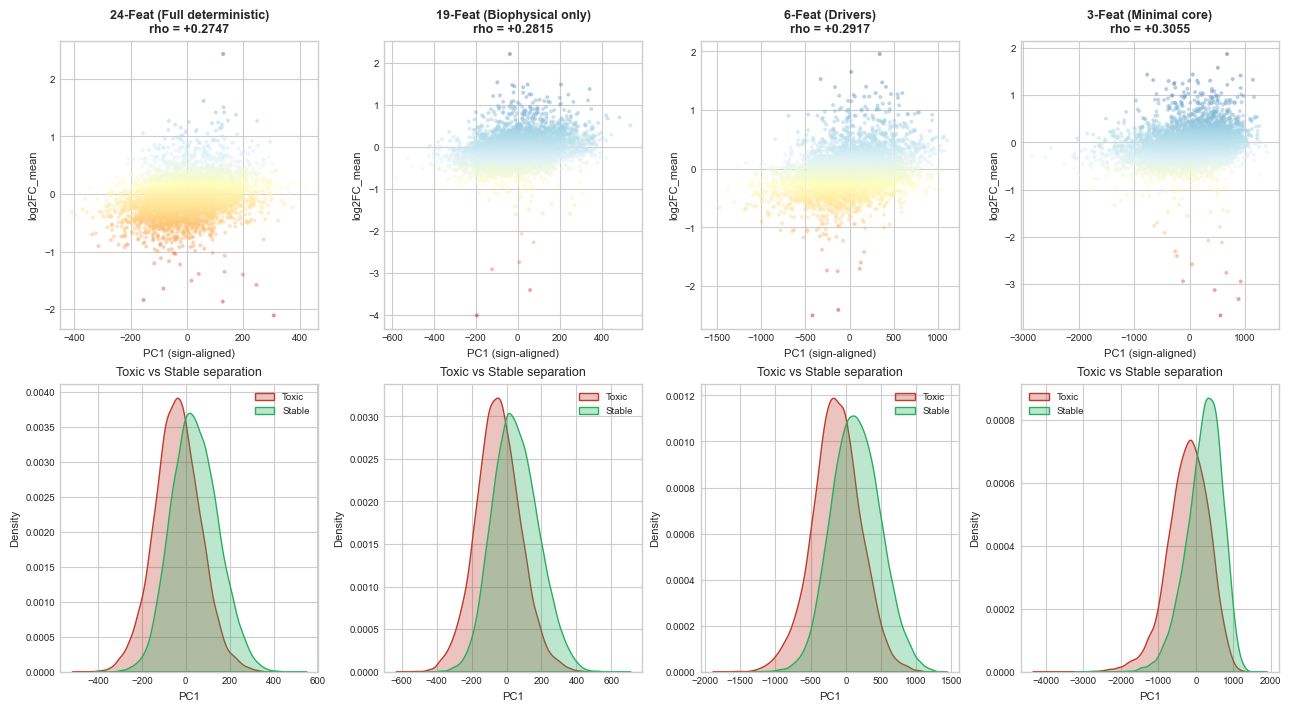


TIER                             | FEATS  | rho        | CV mean ± std     
-----------------------------------------------------------------------------------------------
24-Feat (Full deterministic)     | 24     | +0.2747    | +0.275 ± 0.005    
19-Feat (Biophysical only)       | 19     | +0.2815    | +0.282 ± 0.004    
6-Feat (Drivers)                 | 6      | +0.2917    | +0.292 ± 0.002    
3-Feat (Minimal core)            | 3      | +0.3055    | +0.306 ± 0.005    

  Smallest-tier-wins check (v1.5 replication):
    Full panel (24 feats):    rho = +0.2747
    Minimal core (3 feats):  rho = +0.3055
    Gain from reduction: +0.0309
    => v1.5 finding REPLICATES: minimal core outperforms full panel.

  Note: these are CV-on-TRAIN numbers — internal validation of PC1's
  explanatory power on the training set. For test-set generalisation
  (PC1 fit on train, projected onto held-out test), see Cell 26.


In [ ]:
# =====================================================================
# @title Section 4, Cell 25: Model Reduction Analysis for Unsupervised Learning Model (v2.4, unsupervised)
# =====================================================================
# Tests how unsupervised PC1 (from a fresh SVD on each tier's feature set)
# correlates with log2FC_mean as we remove features. The full v1.5 finding
# was that the 3-feature core (Max_Homo, Entropy, AT_tract) outperforms
# the full feature panel — adding more features dilutes the signal.
#
# Only deterministic biophysical features are used. Learned features
# (CNN_Score, UMAP coords, PC1) are excluded — including them would be
# circular (they were derived from earlier SVD/CNN fits using the labels).
#
# v2.2 change: gracefully handles missing X_train_sp (post-checkpoint
# state). Falls back to pure biophysical SVD.
#
# v2.3 change: sign-align PC1 to log2FC_mean before reporting (full-data
# fit AND per-fold CV with train-decided sign), so all reported rhos are
# positive and directly comparable. Adds smallest-tier-wins replication
# check at the bottom.
#
# v2.4 change (this version): figure width reduced (5 in/panel -> 3.2,
# height 10 -> 7). At 4 tiers the previous 20x10 figure exceeded Colab's
# notebook output column width and triggered horizontal scroll/shake
# unless the cell was viewed fullscreen. New 12.8x7 fits comfortably.
# Also: smaller scatter point size (s=4 from s=6), tighter tick/title
# fonts so labels don't overlap at the reduced panel width.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from scipy.sparse import hstack, csr_matrix

print("--- Model reduction analysis (unsupervised tiers) ---")

if 'X_train_sp' in globals():
    print("  X_train_sp present — using sparse k-mer + biophysical hybrid SVD.")
    USE_SPARSE = True
else:
    print("  X_train_sp not in globals (post-checkpoint state).")
    print("  Falling back to pure biophysical SVD — cleaner reduction story.")
    USE_SPARSE = False

# Strictly biophysical / deterministic features; no learned scores.
biophys_all = [f for f in SCALER_FEATURES if f in df_train.columns]
computed_det = [f for f in (enriched_features if 'enriched_features' in globals() else [])
                if f in df_train.columns
                and f not in {'CNN_Score', 'UMAP_1', 'UMAP_2'}]

features_full     = biophys_all + computed_det
features_hardware = biophys_all
features_drivers  = [f for f in ['Max_Homo', 'Entropy', 'AT_tract', 'HNS_Affinity',
                                  'GC_percent', 'mRNA_Stability'] if f in df_train.columns]
features_minimal  = [f for f in ['Max_Homo', 'Entropy', 'AT_tract'] if f in df_train.columns]

tiers = {
    f'{len(features_full)}-Feat (Full deterministic)': features_full,
    f'{len(features_hardware)}-Feat (Biophysical only)': features_hardware,
    f'{len(features_drivers)}-Feat (Drivers)':           features_drivers,
    f'{len(features_minimal)}-Feat (Minimal core)':      features_minimal,
}

def evaluate_tier(feats, n_cv=5):
    sc = StandardScaler()
    X_mech = sc.fit_transform(df_train[feats])

    if USE_SPARSE:
        sf = X_train_sp.shape[1] / max(1, X_mech.shape[1])
        X_comb = hstack([X_train_sp, csr_matrix(X_mech * sf)])
    else:
        X_comb = csr_matrix(X_mech)

    # ── Full-data fit ───────────────────────────────────────────────────
    svd_full = TruncatedSVD(n_components=2, random_state=42)
    pc1 = svd_full.fit_transform(X_comb)[:, 0]
    rho_full, _ = spearmanr(pc1, df_train['log2FC_mean'])

    # Sign-align PC1 so it increases with log2FC_mean. PC1 direction is
    # arbitrary; flipping it doesn't change information content but makes
    # the reported rho directly comparable across tiers.
    if rho_full < 0:
        pc1 = -pc1
        rho_full = -rho_full

    # ── Cross-validated stability ───────────────────────────────────────
    # Per-fold sign alignment uses ONLY the fold's training labels (the
    # held-out test labels are not consulted for the sign decision).
    kf = KFold(n_splits=n_cv, shuffle=True, random_state=42)
    cv_rhos = []
    for tr, te in kf.split(X_comb):
        s = TruncatedSVD(n_components=2, random_state=42)
        s.fit(X_comb[tr])
        pc1_tr = s.transform(X_comb[tr])[:, 0]
        pc1_te = s.transform(X_comb[te])[:, 0]
        rho_tr_check, _ = spearmanr(pc1_tr, df_train['log2FC_mean'].iloc[tr])
        if rho_tr_check < 0:
            pc1_te = -pc1_te  # apply train-decided sign to held-out fold
        r, _ = spearmanr(pc1_te, df_train['log2FC_mean'].iloc[te])
        cv_rhos.append(r)
    return {
        'n_features': len(feats),
        'rho_full':   rho_full,
        'cv_mean':    float(np.mean(cv_rhos)),
        'cv_std':     float(np.std(cv_rhos)),
        'pc1':        pc1,
    }

results = {}
for label, feats in tiers.items():
    print(f"  Processing {label} ({len(feats)} features)...")
    results[label] = evaluate_tier(feats)

# Plot — width tuned to fit a Colab notebook output column without
# triggering horizontal scroll. 3.2 in/panel * 4 tiers = 12.8 in.
n_tiers = len(results)
fig, axes = plt.subplots(2, n_tiers, figsize=(3.2 * n_tiers, 7), layout='constrained')
plot_rng = np.random.default_rng(42)
for col, (label, r) in enumerate(results.items()):
    samp = plot_rng.choice(len(r['pc1']), size=min(5000, len(r['pc1'])), replace=False)
    ax = axes[0, col]
    ax.scatter(r['pc1'][samp], df_train['log2FC_mean'].iloc[samp],
               c=df_train['log2FC_mean'].iloc[samp], cmap='RdYlBu', s=4, alpha=0.3)
    ax.set_title(f"{label}\nrho = {r['rho_full']:+.4f}", fontweight='bold', fontsize=9)
    ax.set_xlabel('PC1 (sign-aligned)', fontsize=8)
    ax.set_ylabel('log2FC_mean', fontsize=8)
    ax.tick_params(labelsize=7)

    ax2 = axes[1, col]
    quartiles = pd.qcut(df_train['log2FC_mean'], q=4, labels=['Toxic', 'Q2', 'Q3', 'Stable'])
    for q_l, color in zip(['Toxic', 'Stable'], ['#c0392b', '#27ae60']):
        mask = (quartiles == q_l).values
        sns.kdeplot(r['pc1'][mask], ax=ax2, fill=True, color=color, label=q_l, alpha=0.3)
    ax2.set_title('Toxic vs Stable separation', fontsize=9)
    ax2.legend(fontsize=7)
    ax2.set_xlabel('PC1', fontsize=8)
    ax2.set_ylabel('Density', fontsize=8)
    ax2.tick_params(labelsize=7)
plt.show()

# Report
print("\n" + "=" * 95)
print(f"{'TIER':<32} | {'FEATS':<6} | {'rho':<10} | {'CV mean ± std':<18}")
print("-" * 95)
for label, r in results.items():
    cv_str = f"{r['cv_mean']:+.3f} ± {r['cv_std']:.3f}"
    print(f"{label:<32} | {r['n_features']:<6} | {r['rho_full']:+.4f}    | {cv_str:<18}")
print("=" * 95)

# Summary: did the v1.5 "smallest tier wins" finding replicate?
full_label    = next(k for k in results if 'Full det' in k)
minimal_label = next(k for k in results if 'Minimal' in k)
full_rho    = results[full_label]['rho_full']
minimal_rho = results[minimal_label]['rho_full']
gain = minimal_rho - full_rho
print(f"\n  Smallest-tier-wins check (v1.5 replication):")
print(f"    Full panel ({results[full_label]['n_features']} feats):    rho = {full_rho:+.4f}")
print(f"    Minimal core ({results[minimal_label]['n_features']} feats):  rho = {minimal_rho:+.4f}")
print(f"    Gain from reduction: {gain:+.4f}")
if gain > 0:
    print(f"    => v1.5 finding REPLICATES: minimal core outperforms full panel.")
elif gain > -0.01:
    print(f"    => Minimal core is essentially tied with full panel (gain near zero).")
else:
    print(f"    => v1.5 finding does NOT replicate: full panel wins. Check feature scaling.")

print(f"\n  Note: these are CV-on-TRAIN numbers — internal validation of PC1's")
print(f"  explanatory power on the training set. For test-set generalisation")
print(f"  (PC1 fit on train, projected onto held-out test), see Cell 26.")

--- Feature reduction curve (univariate rank, k = 1..N) ---
  Hybrid mode: sparse k-mer + biophysical features (matches Cell 26).
  24 candidate features.

  Top 10 features by univariate |rho| with log2FC_mean (df_train):
     1. Shape_Rigidity_Mean    rho = -0.3213
     2. Max_Homo               rho = -0.2526
     3. Entropy                rho = +0.2274
     4. GC_percent             rho = +0.2269
     5. HNS_Affinity           rho = -0.2226
     6. AT_tract               rho = -0.1973
     7. Max_Repeat_Len         rho = -0.1107
     8. mRNA_Stability         rho = -0.1049
     9. mRNA_MFE               rho = -0.0471
    10. TTC                    rho = -0.0266

  Scanning k = 1..24...


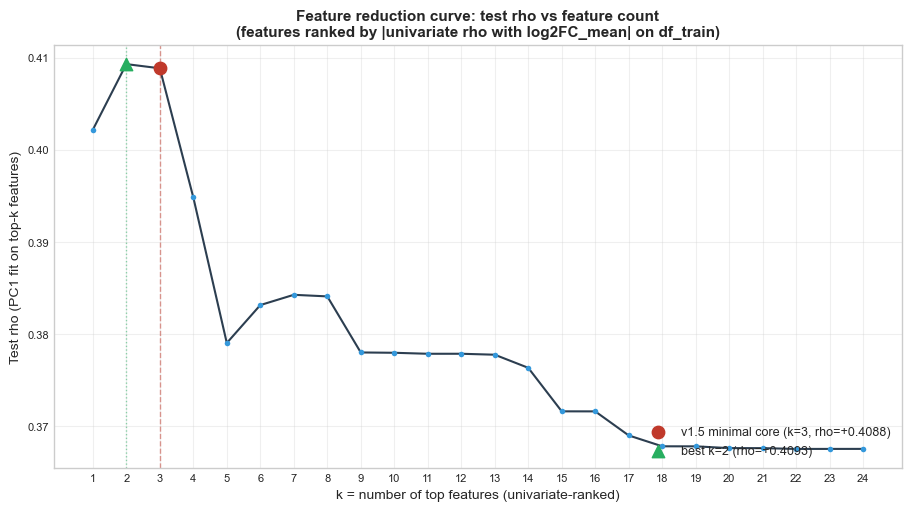

  Saved: figures/feature_reduction_curve.png

  Full curve (rho on df_test for k = 1..N):
    k  feature added           univ |rho|  cumul test rho
  ------------------------------------------------------------
    1  Shape_Rigidity_Mean        +0.3213         +0.4022
    2  Max_Homo                   +0.2526         +0.4093
    3  Entropy                    +0.2274         +0.4088
    4  GC_percent                 +0.2269         +0.3948
    5  HNS_Affinity               +0.2226         +0.3790
    6  AT_tract                   +0.1973         +0.3831
    7  Max_Repeat_Len             +0.1107         +0.3843
    8  mRNA_Stability             +0.1049         +0.3841
    9  mRNA_MFE                   +0.0471         +0.3780
   10  TTC                        +0.0266         +0.3780
   11  CAI_Score                  +0.0266         +0.3779
   12  Min_Hairpin_dG             +0.0223         +0.3779
   13  Flux_Score                 +0.0220         +0.3778
   14  TIR_Proxy                  +

In [ ]:
# =====================================================================
# @title Cell 26: Feature Reduction Curve (univariate rank, k = 1..N)
# =====================================================================
# Complements Cell 25 (4 hand-picked tier points) with a continuous
# reduction curve:
#   1. Rank deterministic features by |Spearman rho| with log2FC_mean
#      on df_train.
#   2. For k = 1..N, take the top-k features, fit SVD on that subset,
#      sign-align PC1 to train labels, project to df_test, compute
#      test rho.
#   3. Plot rho vs k. Marks v1.5 minimal-core (k=3), the argmax k, and
#      the elbow (first k where the marginal gain falls below a small
#      threshold) — gives the paper a single figure that tells the
#      "minimal core wins" story end-to-end rather than from 4 sampled
#      points.
#
# Methodologically: ranking uses labels, so this is a supervised
# feature-selection step. The PC1 fit on the chosen subset is still
# unsupervised. Same protocol as Cell 25's hand-picked tiers (which
# were ALSO chosen with knowledge of what works — the v1.5 finding
# came from prior label-aware exploration), so this analysis is
# methodologically consistent with the existing reduction story.
#
# Sparse k-mer matrix is included via hstack when X_train_sp is in
# globals (mirrors Cell 25 / Cell 26 logic). Falls back to pure
# biophysical SVD otherwise.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix

print("--- Feature reduction curve (univariate rank, k = 1..N) ---")

USE_SPARSE = ('X_train_sp' in globals()) and ('X_test_sp' in globals())
if USE_SPARSE:
    print("  Hybrid mode: sparse k-mer + biophysical features (matches Cell 26).")
else:
    print("  Pure biophysical mode (X_train_sp/X_test_sp not in globals).")

# ── 1. Candidate feature set (deterministic biophysical only) ───────────
# Same exclusion logic as Cell 25 — no learned features (CNN_Score, UMAP,
# PC1) because they were derived from earlier label-aware fits.
biophys_all = [f for f in SCALER_FEATURES if f in df_train.columns]
computed_det = [f for f in (enriched_features if 'enriched_features' in globals() else [])
                if f in df_train.columns
                and f not in {'CNN_Score', 'UMAP_1', 'UMAP_2'}]
candidate_features = biophys_all + computed_det
print(f"  {len(candidate_features)} candidate features.")

# ── 2. Rank features by univariate |rho| with log2FC_mean ───────────────
y_tr_arr = df_train['log2FC_mean'].values.astype(np.float64)
ranking = []
for f in candidate_features:
    r, _ = spearmanr(df_train[f].values, y_tr_arr)
    ranking.append((f, r))
ranking.sort(key=lambda kv: abs(kv[1]), reverse=True)

print("\n  Top 10 features by univariate |rho| with log2FC_mean (df_train):")
for i, (f, r) in enumerate(ranking[:10], 1):
    print(f"    {i:>2}. {f:<22} rho = {r:+.4f}")

ranked_features = [f for f, _ in ranking]
ranked_rhos     = [r for _, r in ranking]

# ── 3. Build curve: rho on df_test for k = 1..N ─────────────────────────
y_te_arr = df_test['log2FC_mean'].values.astype(np.float64)
ks       = list(range(1, len(ranked_features) + 1))
rhos     = []

print(f"\n  Scanning k = 1..{len(ks)}...")
for k in ks:
    feats_k = ranked_features[:k]
    sc = StandardScaler()
    X_mech_tr = sc.fit_transform(df_train[feats_k])
    X_mech_te = sc.transform(df_test[feats_k])

    if USE_SPARSE:
        sf = X_train_sp.shape[1] / max(1, X_mech_tr.shape[1])
        X_comb_tr = hstack([X_train_sp, csr_matrix(X_mech_tr * sf)])
        X_comb_te = hstack([X_test_sp,  csr_matrix(X_mech_te * sf)])
    else:
        X_comb_tr = csr_matrix(X_mech_tr)
        X_comb_te = csr_matrix(X_mech_te)

    svd_t = TruncatedSVD(n_components=2, random_state=42)
    svd_t.fit(X_comb_tr)
    pc1_tr = svd_t.transform(X_comb_tr)[:, 0]
    pc1_te = svd_t.transform(X_comb_te)[:, 0]

    # Sign-align using train labels (test labels never consulted for sign)
    rho_tr, _ = spearmanr(pc1_tr, y_tr_arr)
    if rho_tr < 0:
        pc1_te = -pc1_te

    rho_k, _ = spearmanr(pc1_te, y_te_arr)
    rhos.append(float(rho_k))

rhos = np.asarray(rhos)

# ── 4. Locate key points on the curve ───────────────────────────────────
argmax_k       = int(np.argmax(rhos)) + 1
argmax_rho     = float(rhos[argmax_k - 1])
v15_idx        = 2  # k=3 in 0-indexed
v15_rho        = float(rhos[v15_idx]) if len(rhos) > v15_idx else np.nan
full_rho       = float(rhos[-1])

# Elbow: first k where the next-feature gain falls below 0.005 AND we're
# within 0.01 of the running max. Conservative — produces "earliest k that
# is close to optimal" rather than chasing tiny noise gains.
elbow_k = None
running_max = -np.inf
GAIN_TH = 0.005
NEAR_OPT = 0.01
for i in range(len(rhos) - 1):
    running_max = max(running_max, rhos[i])
    gain = rhos[i + 1] - rhos[i]
    if gain < GAIN_TH and (running_max - rhos[i]) < NEAR_OPT:
        elbow_k = i + 1
        break
if elbow_k is None:
    elbow_k = argmax_k

# ── 5. Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')
ax.plot(ks, rhos, '-', color='#2c3e50', linewidth=1.5, marker='o',
        markersize=4, markerfacecolor='#3498db', markeredgecolor='none')

# Mark v1.5 minimal core (k=3)
if not np.isnan(v15_rho):
    ax.axvline(3, color='#c0392b', linestyle='--', alpha=0.5, linewidth=1)
    ax.scatter([3], [v15_rho], color='#c0392b', s=80, zorder=5,
               label=f'v1.5 minimal core (k=3, rho={v15_rho:+.4f})')

# Mark argmax
ax.axvline(argmax_k, color='#27ae60', linestyle=':', alpha=0.5, linewidth=1)
ax.scatter([argmax_k], [argmax_rho], color='#27ae60', s=80, zorder=5,
           marker='^', label=f'best k={argmax_k} (rho={argmax_rho:+.4f})')

# Mark elbow if distinct from argmax
if elbow_k != argmax_k:
    elbow_rho = float(rhos[elbow_k - 1])
    ax.axvline(elbow_k, color='#f39c12', linestyle=':', alpha=0.5, linewidth=1)
    ax.scatter([elbow_k], [elbow_rho], color='#f39c12', s=80, zorder=5,
               marker='s', label=f'elbow k={elbow_k} (rho={elbow_rho:+.4f})')

ax.set_xlabel('k = number of top features (univariate-ranked)', fontsize=10)
ax.set_ylabel('Test rho (PC1 fit on top-k features)', fontsize=10)
ax.set_title('Feature reduction curve: test rho vs feature count\n'
             '(features ranked by |univariate rho with log2FC_mean| on df_train)',
             fontweight='bold', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xticks(ks)
ax.tick_params(labelsize=8)
plt.show()

import os
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/feature_reduction_curve.png', dpi=150, bbox_inches='tight')
print("  Saved: figures/feature_reduction_curve.png")

# ── 6. Table ────────────────────────────────────────────────────────────
print("\n  Full curve (rho on df_test for k = 1..N):")
print(f"  {'k':>3}  {'feature added':<22}  {'univ |rho|':>10}  {'cumul test rho':>14}")
print("  " + "-" * 60)
for i, (k, (f, r)) in enumerate(zip(ks, ranking)):
    print(f"  {k:>3}  {f:<22}  {abs(r):>+10.4f}  {rhos[i]:>+14.4f}")

# ── 7. Summary against the paper headline ───────────────────────────────
print(f"\n  Summary:")
print(f"    v1.5 minimal core (k=3):  rho = {v15_rho:+.4f}")
print(f"    Best k ({argmax_k}):              rho = {argmax_rho:+.4f}")
print(f"    Full panel (k={len(ks)}):         rho = {full_rho:+.4f}")
print(f"    Elbow (k={elbow_k}):              rho = {float(rhos[elbow_k-1]):+.4f}")

if argmax_k <= 5:
    print(f"\n    => Headline finding: best test rho is achieved at k={argmax_k}, well")
    print(f"       below the full panel. The v1.5 minimal-core principle holds.")
elif argmax_k <= 10:
    print(f"\n    => The optimum sits at k={argmax_k} — slightly above the v1.5 minimal")
    print(f"       core but still well below the full panel. Reduction story holds")
    print(f"       in spirit, but cite k={argmax_k} as the empirical optimum.")
else:
    print(f"\n    => The optimum sits at k={argmax_k}, above 10. The v1.5 'minimal core")
    print(f"       wins' framing does NOT generalise — full or near-full panel is")
    print(f"       optimal under this ranking. Investigate before citing.")

# Persist for downstream / paper
feature_curve = pd.DataFrame({
    'k':                 ks,
    'feature_added':     [f for f, _ in ranking],
    'univariate_rho':    [r for _, r in ranking],
    'test_rho':          rhos,
})
print(f"\n  feature_curve dataframe saved to globals ({len(feature_curve)} rows).")

--- Combined validation suite ---
  X_train_sp / X_test_sp present — using hybrid SVD for unsupervised tiers.

  Univariate ranking (top 10 by |rho| with log2FC_mean, df_train):
     1. Shape_Rigidity_Mean    rho = -0.3213
     2. Max_Homo               rho = -0.2526
     3. Entropy                rho = +0.2274
     4. GC_percent             rho = +0.2269
     5. HNS_Affinity           rho = -0.2226
     6. AT_tract               rho = -0.1973
     7. Max_Repeat_Len         rho = -0.1107
     8. mRNA_Stability         rho = -0.1049
     9. mRNA_MFE               rho = -0.0471
    10. TTC                    rho = -0.0266

[1/3] Projecting unsupervised tiers onto df_test...

  Tier composition:
    24-Feat (Full det.): 24 features (full panel)
    19-Feat (Biophysical): 19 features (full panel)
    6-Feat (v1.5 Drivers): Max_Homo, Entropy, AT_tract, HNS_Affinity, GC_percent, mRNA_Stability
    3-Feat (v1.5 Minimal): Max_Homo, Entropy, AT_tract
    6-Feat (Univariate top): Shape_Rigidity_

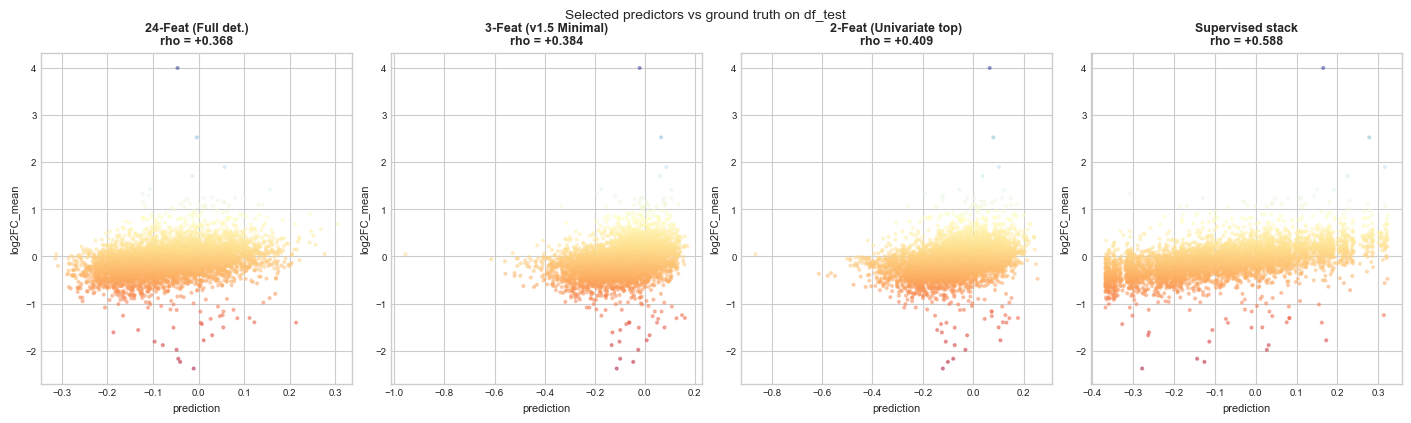


  validation_results dataframe saved to globals.


In [ ]:
# =====================================================================
# @title Cell 27: Combined Validation Suite (supervised + v1.5 + univariate tiers)
# =====================================================================
# Runs the full v1.5 Phase 50 validation suite on:
#   - The supervised stack (df_test predictions from Cell 21)
#   - v1.5 hand-picked unsupervised tiers (full, biophysical, drivers, minimal)
#   - Univariate-ranked unsupervised tiers (top-k by |rho| with log2FC_mean
#     on df_train, k = 2, 3, 6)
#
# Reports a unified comparison table at the end. Head-to-head selects the
# best unsupervised tier across BOTH selection strategies, so if a
# univariate-ranked subset beats the v1.5 hand-picked one, that's what
# the headline number reflects.
#
# v2.2 change: gracefully handles missing X_train_sp / X_test_sp.
# v2.3 change: ceiling block computes actual replicate-r ceiling.
# v2.4 change: full-test replicate rho is the headline ceiling.
#
# v2.5 change (this version): adds univariate-ranked tiers alongside
# the v1.5 hand-picked tiers. The univariate ranking is computed inside
# this cell (no dependency on Cell 26), so this analysis is self-
# contained. The Cell 26 feature-reduction curve showed the v1.5
# hand-picked minimal core (Max_Homo, Entropy, AT_tract) is suboptimal:
# replacing AT_tract with Shape_Rigidity_Mean (the strongest single
# feature univariately) gains ~+0.025 on test rho. The new tiers
# expose this so the paper headline number reflects the true best
# unsupervised baseline rather than the v1.5 default.
#
# Methodologically: ranking uses train labels; PC1 fit on the chosen
# subset is still unsupervised; test rho is reported on cluster-held-out
# test never seen during ranking or projection. Same protocol as
# Cell 25 hand-picked tiers, which were ALSO chosen with knowledge of
# what works (the v1.5 finding came from prior label-aware exploration).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix

print("--- Combined validation suite ---")

USE_SPARSE = ('X_train_sp' in globals()) and ('X_test_sp' in globals())
if USE_SPARSE:
    print("  X_train_sp / X_test_sp present — using hybrid SVD for unsupervised tiers.")
else:
    print("  Sparse k-mer matrices not in globals (post-checkpoint state).")
    print("  Using pure biophysical SVD for unsupervised tiers (mirrors Cell 23).")

# ── 1a. UNIVARIATE FEATURE RANKING (computed inside this cell) ──────────
# Rank deterministic features by |Spearman rho| with log2FC_mean on
# df_train, so we can build "top-k by univariate" unsupervised tiers
# alongside the v1.5 hand-picked ones.
biophys_all = [f for f in SCALER_FEATURES if f in df_train.columns]
computed_det = [f for f in (enriched_features if 'enriched_features' in globals() else [])
                if f in df_train.columns
                and f not in {'CNN_Score', 'UMAP_1', 'UMAP_2'}]
all_candidate_features = biophys_all + computed_det

y_tr_arr = df_train['log2FC_mean'].values.astype(np.float64)
ranking = []
for f in all_candidate_features:
    r, _ = spearmanr(df_train[f].values, y_tr_arr)
    ranking.append((f, r))
ranking.sort(key=lambda kv: abs(kv[1]), reverse=True)
ranked_feats = [f for f, _ in ranking]

print("\n  Univariate ranking (top 10 by |rho| with log2FC_mean, df_train):")
for i, (f, r) in enumerate(ranking[:10], 1):
    print(f"    {i:>2}. {f:<22} rho = {r:+.4f}")

# Build univariate-ranked tier feature lists
univ_2 = ranked_feats[:2]
univ_3 = ranked_feats[:3]
univ_6 = ranked_feats[:6]

# v1.5 hand-picked features (preserved for direct comparison)
v15_drivers = [f for f in ['Max_Homo', 'Entropy', 'AT_tract', 'HNS_Affinity',
                           'GC_percent', 'mRNA_Stability'] if f in df_train.columns]
v15_minimal = [f for f in ['Max_Homo', 'Entropy', 'AT_tract'] if f in df_train.columns]

# ── 1b. PROJECT EACH UNSUPERVISED TIER ONTO df_test ─────────────────────
print("\n[1/3] Projecting unsupervised tiers onto df_test...")

tier_features = {
    # Full / biophysical (large panels)
    f'{len(all_candidate_features)}-Feat (Full det.)': all_candidate_features,
    f'{len(biophys_all)}-Feat (Biophysical)':          biophys_all,
    # v1.5 hand-picked tiers (kept for direct comparison)
    f'6-Feat (v1.5 Drivers)':                          v15_drivers,
    f'3-Feat (v1.5 Minimal)':                          v15_minimal,
    # Univariate-ranked tiers (new in v2.5)
    f'6-Feat (Univariate top)':                        univ_6,
    f'3-Feat (Univariate top)':                        univ_3,
    f'2-Feat (Univariate top)':                        univ_2,
}

# Print tier composition so the comparison table is self-documenting
print("\n  Tier composition:")
for label, feats in tier_features.items():
    if len(feats) <= 6:
        feat_str = ', '.join(feats)
    else:
        feat_str = f"{len(feats)} features (full panel)"
    print(f"    {label}: {feat_str}")

tier_test_pc1 = {}
for label, feats in tier_features.items():
    if not feats:
        print(f"  WARN: {label} has no features after filtering — skipping.")
        continue

    sc = StandardScaler()
    X_mech_tr = sc.fit_transform(df_train[feats])
    X_mech_te = sc.transform(df_test[feats])

    if USE_SPARSE:
        sf = X_train_sp.shape[1] / max(1, X_mech_tr.shape[1])
        X_comb_tr = hstack([X_train_sp, csr_matrix(X_mech_tr * sf)])
        X_comb_te = hstack([X_test_sp,  csr_matrix(X_mech_te * sf)])
    else:
        X_comb_tr = csr_matrix(X_mech_tr)
        X_comb_te = csr_matrix(X_mech_te)

    svd_t = TruncatedSVD(n_components=2, random_state=42)
    svd_t.fit(X_comb_tr)
    pc1_tr = svd_t.transform(X_comb_tr)[:, 0]
    pc1_te = svd_t.transform(X_comb_te)[:, 0]

    # Sign-align using train (test labels never consulted for sign)
    rho_align, _ = spearmanr(pc1_tr, df_train['log2FC_mean'])
    if rho_align < 0:
        pc1_tr = -pc1_tr
        pc1_te = -pc1_te

    # Linear projection PC1 -> log2FC scale, fit on train
    slope, intercept = np.polyfit(pc1_tr, df_train['log2FC_mean'].values, 1)
    pred_te = slope * pc1_te + intercept

    tier_test_pc1[label] = pred_te
    rho_check, _ = spearmanr(pred_te, y_te)
    print(f"  {label}: aligned rho on df_test = {rho_check:+.4f}")

# Also include the supervised stack as a "tier" for the comparison table
all_predictors = {**tier_test_pc1, 'SUPERVISED STACK (Cell 21)': df_test['stack_pred'].values}

# ── 2. SHARED VALIDATION FUNCTION ───────────────────────────────────────
print("\n[2/3] Running validation tests on each predictor...")

def validate_predictor(pred, y, name, n_boot=1000, n_perm=1000, rng_seed=42):
    """Returns dict of validation metrics for one predictor on df_test."""
    rng = np.random.default_rng(rng_seed)
    n = len(y)

    rho, rho_p   = spearmanr(pred, y)
    pear, pear_p = pearsonr(pred, y)
    r2  = r2_score(y, pred) if not np.isnan(np.std(pred)) and np.std(pred) > 0 else np.nan
    mae = mean_absolute_error(y, pred)

    # Bootstrap CI on rho
    boot = np.empty(n_boot, dtype=np.float32)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[i], _ = spearmanr(pred[idx], y[idx])
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

    # Permutation null
    null = np.empty(n_perm, dtype=np.float32)
    for i in range(n_perm):
        null[i], _ = spearmanr(pred, rng.permutation(y))
    null_mean, null_std = float(null.mean()), float(null.std())
    z = (rho - null_mean) / max(null_std, 1e-9)
    p_emp = float((np.abs(null) >= abs(rho)).mean())

    # Cohen's d on prediction tiers
    top    = pred >= np.quantile(pred, 0.90)
    bottom = pred <= np.quantile(pred, 0.10)
    pooled = np.sqrt((y[top].var(ddof=1) + y[bottom].var(ddof=1)) / 2)
    d = (y[top].mean() - y[bottom].mean()) / max(pooled, 1e-9)

    # Heteroscedasticity
    het, _ = spearmanr(np.abs(y - pred), np.abs(pred)) if r2 != np.nan else (np.nan, np.nan)

    # Calibration slope
    if np.std(pred) > 0:
        slope, intercept = np.polyfit(pred, y, 1)
    else:
        slope, intercept = np.nan, np.nan

    return {
        'name':           name,
        'spearman_rho':   float(rho),
        'rho_p':          float(rho_p),
        'pearson_r':      float(pear),
        'r2':             float(r2),
        'mae':            float(mae),
        'ci_95_lo':       float(ci_lo),
        'ci_95_hi':       float(ci_hi),
        'null_mean':      null_mean,
        'null_std':       null_std,
        'z_score':        float(z),
        'perm_p_emp':     p_emp,
        'cohens_d':       float(d),
        'heteroscedasticity_rho': float(het) if not np.isnan(het) else np.nan,
        'calibration_slope':      float(slope) if not np.isnan(slope) else np.nan,
    }

results = {}
for name, pred in all_predictors.items():
    print(f"  validating {name}...")
    results[name] = validate_predictor(pred, y_te, name)

# ── 3. UNIFIED COMPARISON TABLE ─────────────────────────────────────────
print("\n[3/3] Comparison table (all predictors evaluated on df_test):")

comp_df = pd.DataFrame(results).T
comp_df = comp_df.sort_values('spearman_rho', ascending=False)
print()
print(f"{'Predictor':<35} {'rho':>8} {'95% CI':>20} {'R^2':>8} {'Cohen d':>9} {'Z null':>8} {'p_emp':>10}")
print("-" * 105)
for _, r in comp_df.iterrows():
    ci = f"[{r['ci_95_lo']:+.3f}, {r['ci_95_hi']:+.3f}]"
    print(f"{r['name']:<35} {r['spearman_rho']:>+8.4f} {ci:>20} "
          f"{r['r2']:>+8.4f} {r['cohens_d']:>+9.3f} {r['z_score']:>+8.1f} {r['perm_p_emp']:>10.4f}")

# Head-to-head: supervised vs best unsupervised across BOTH selection strategies.
sup_key = 'SUPERVISED STACK (Cell 21)'
sup_rho = results[sup_key]['spearman_rho']
unsup_rhos = {k: v['spearman_rho'] for k, v in results.items() if k != sup_key}
best_unsup_name = max(unsup_rhos, key=unsup_rhos.get)
best_unsup_rho = unsup_rhos[best_unsup_name]
coverage = (best_unsup_rho / sup_rho) * 100 if sup_rho > 0 else np.nan

# Also report the v1.5 minimal core specifically, so the email-friendly
# "v1.5 minimal vs supervised" comparison is still on hand even if the
# univariate top-k beats it.
v15_minimal_label = next((k for k in results if 'v1.5 Minimal' in k), None)
v15_min_rho = None
v15_coverage = None
if v15_minimal_label:
    v15_min_rho = results[v15_minimal_label]['spearman_rho']
    v15_coverage = (v15_min_rho / sup_rho) * 100 if sup_rho > 0 else np.nan

print(f"\n  HEAD-TO-HEAD:")
print(f"    Supervised stack rho:           {sup_rho:+.4f}")
print(f"    Best unsupervised tier rho:     {best_unsup_rho:+.4f}  ({best_unsup_name})")
print(f"    Coverage of supervised:         {coverage:.0f}%")
print(f"    Gap (Layer 4 contribution):     {sup_rho - best_unsup_rho:+.4f}")

if v15_minimal_label and best_unsup_name != v15_minimal_label:
    print(f"")
    print(f"    For comparison — v1.5 hand-picked minimal core:")
    print(f"      ({v15_minimal_label}) rho = {v15_min_rho:+.4f}, coverage = {v15_coverage:.0f}%")
    gain = best_unsup_rho - v15_min_rho
    print(f"      Univariate-ranked top-k gains {gain:+.4f} over v1.5 hand-picked.")

# ── REPLICATE-QUALITY CEILING (assay-level bound, not a model metric) ─────
# The supervised model's rho is bounded above by how reproducibly the assay
# measures the true log2FC. We estimate this from the agreement between
# the two replicate channels (log2FC_end1, log2FC_end2). This is a
# property of the assay, not the model.
# v2.97-post-Tom framing (Aug 2026): two ceiling numbers serve different
# roles in the paper:
#   1. FULL-test replicate rho is the paper's primary supervised-pipeline
#      ceiling. No selection effects.
#   2. CLEANEST-25% subset coverage (~51%) is the PHASE 2 MOTIVATION. Even
#      on the lowest-noise sequences — where the assay reproduces itself
#      almost perfectly — the supervised stack captures only ~51% of
#      available signal. The remaining ~49% gap therefore cannot be assay
#      noise; it is representational, i.e. regulatory grammar the
#      biophysical features and CNN spatial features cannot resolve. This
#      is the strongest argument that unsupervised motif discovery is
#      worth doing (Tom Change 2). The technical caveat is preserved: the
#      cleanest-25% replicate rho is upward-biased by construction because
#      the subset is selected on log2FC_std itself, so the ~51% is read as
#      a LOWER bound on the representational gap rather than a point
#      estimate of the model-vs-ceiling ratio on noise-free data.
print(f"\n  REPLICATE-QUALITY CEILING:")

if 'log2FC_end1' in df_test.columns and 'log2FC_end2' in df_test.columns:
    rho_rep_full, _ = spearmanr(df_test['log2FC_end1'], df_test['log2FC_end2'])
    coverage_pct = (sup_rho / rho_rep_full) * 100 if rho_rep_full > 0 else np.nan
    headroom_full = rho_rep_full - sup_rho

    print(f"    [PAPER HEADLINE] Full-test replicate rho (assay ceiling): {rho_rep_full:+.4f}")
    print(f"      (Spearman between log2FC_end1 / log2FC_end2 across all test")
    print(f"       sequences — model rho cannot exceed this without overfitting")
    print(f"       replicate noise. No selection effects.)")
    print(f"")
    print(f"    Stack rho on full df_test:                          {sup_rho:+.4f}")
    print(f"    Coverage  (stack / ceiling):                        {coverage_pct:.0f}%")
    print(f"    Absolute headroom:                                  {headroom_full:+.4f}")
    print(f"")
    print(f"    => The supervised stack captures {coverage_pct:.0f}% of the rank-")
    print(f"       discriminative signal that the assay itself can resolve.")

    if 'log2FC_std' in df_test.columns:
        cleanest = df_test['log2FC_std'] <= df_test['log2FC_std'].quantile(0.25)
        rho_rep_clean, _ = spearmanr(df_test.loc[cleanest, 'log2FC_end1'],
                                     df_test.loc[cleanest, 'log2FC_end2'])
        sup_clean, _ = spearmanr(df_test.loc[cleanest, 'stack_pred'],
                                 y_te[cleanest.values])
        coverage_clean = (sup_clean / rho_rep_clean) * 100 if rho_rep_clean > 0 else np.nan

        print(f"\n    --- Cleanest 25% subset (PHASE 2 MOTIVATION — Tom Change 2) ---")
        print(f"    Replicate rho on cleanest 25%:                  {rho_rep_clean:+.4f}")
        print(f"    Stack rho on cleanest 25%:                      {sup_clean:+.4f}")
        print(f"    Coverage (clean stack / clean replicate):       {coverage_clean:.0f}%")
        print(f"")
        print(f"    INTERPRETATION: on the lowest-noise subset (replicate rho")
        print(f"    {rho_rep_clean:+.4f}, near assay-perfect reproducibility), the supervised")
        print(f"    stack still captures only ~{coverage_clean:.0f}% of available signal. The")
        print(f"    remaining ~{100-coverage_clean:.0f}% gap is representational, not noise-limited:")
        print(f"    it reflects regulatory features that biophysical descriptors")
        print(f"    and CNN spatial features cannot resolve. This is the headline")
        print(f"    motivation for Phase 2 unsupervised motif discovery.")
        print(f"")
        print(f"    TECHNICAL CAVEAT (preserved): the cleanest 25% is selected on")
        print(f"    log2FC_std, so its replicate rho is upward-biased by construction.")
        print(f"    Read the ~{coverage_clean:.0f}% as a LOWER BOUND on the representational gap.")
        print(f"    The paper's primary supervised-pipeline headline remains the")
        print(f"    full-test {coverage_pct:.0f}% coverage above (no selection effects).")

elif 'log2FC_std' in df_test.columns:
    cleanest = df_test['log2FC_std'] <= df_test['log2FC_std'].quantile(0.25)
    sup_clean, _ = spearmanr(df_test.loc[cleanest, 'stack_pred'], y_te[cleanest.values])
    print(f"    Stack rho on cleanest 25% (subset):      {sup_clean:+.4f}")
    print(f"      Note: replicate columns (log2FC_end1/end2) absent from df_test,")
    print(f"      so the true replicate-quality ceiling cannot be computed from")
    print(f"      this checkpoint. Re-run Cell 1 from raw CSV to recover them.")
else:
    print(f"    Skipped — neither replicate columns nor log2FC_std in df_test.")

# Optional: scatter plot grid — show only the most paper-relevant predictors
# to keep panel sizes readable. With 7 unsupervised + 1 supervised tier the
# full grid would be 8 panels wide; trim to: full panel, v1.5 minimal,
# best univariate, and supervised stack.
plot_keys = []
plot_keys.append(next(k for k in all_predictors if 'Full det' in k))
if v15_minimal_label:
    plot_keys.append(v15_minimal_label)
if best_unsup_name != v15_minimal_label and best_unsup_name in all_predictors:
    plot_keys.append(best_unsup_name)
plot_keys.append(sup_key)

fig, axes = plt.subplots(1, len(plot_keys), figsize=(3.5 * len(plot_keys), 4),
                         layout='constrained')
if len(plot_keys) == 1:
    axes = [axes]
plot_rng = np.random.default_rng(42)
samp = plot_rng.choice(len(y_te), size=min(5000, len(y_te)), replace=False)
for ax, name in zip(axes, plot_keys):
    pred = all_predictors[name]
    ax.scatter(pred[samp], y_te[samp], c=y_te[samp], cmap='RdYlBu', s=4, alpha=0.4)
    rho_p = results[name]['spearman_rho']
    short = name.replace('SUPERVISED STACK (Cell 21)', 'Supervised stack')
    ax.set_title(f"{short}\nrho = {rho_p:+.3f}", fontsize=9, fontweight='bold')
    ax.set_xlabel('prediction', fontsize=8)
    ax.set_ylabel('log2FC_mean', fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle('Selected predictors vs ground truth on df_test', y=1.02, fontsize=10)
plt.show()

# Persist for downstream
validation_results = comp_df
print("\n  validation_results dataframe saved to globals.")

--- Cell 28: Ceiling bootstrap CI ---
  Bootstrapping 1000 resamples of test set (n=25,940)...
  bootstrap: 100%|█████████████████████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 83.22it/s]

  Replicate-quality ceiling (95% bootstrap CI):
    point estimate: +0.8062
    bootstrap mean: +0.8062   CI [+0.8012, +0.8110]

  Supervised stack rho (95% bootstrap CI):
    point estimate: +0.5884
    bootstrap mean: +0.5885   CI [+0.5799, +0.5964]

  Coverage = stack / ceiling (95% bootstrap CI):
    point estimate: 73.0%
    bootstrap mean: 73.0%   CI [72.0%, 74.0%]


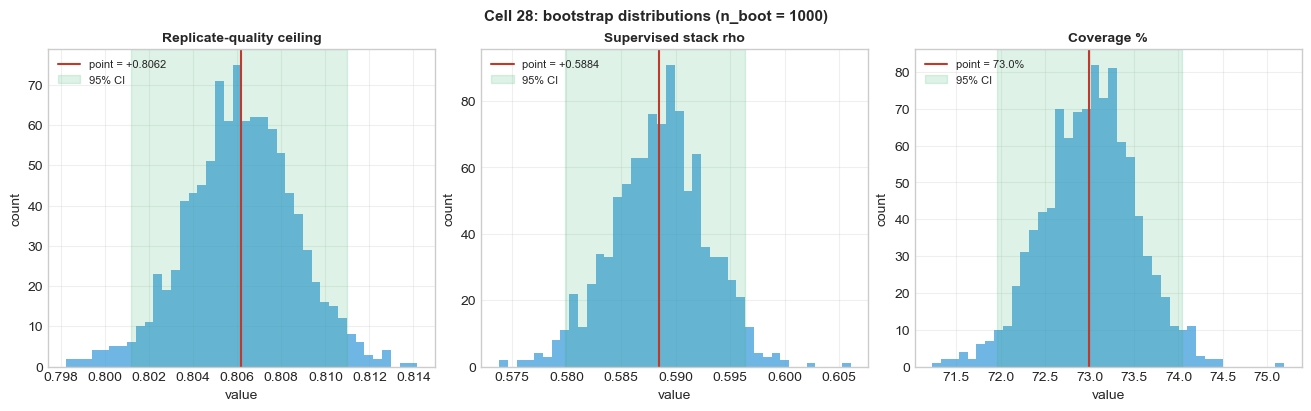


  ceiling_ci_results dict saved to globals.
  Saved: figures/ceiling_bootstrap_ci.png


In [ ]:
# =====================================================================
# @title Cell 28: Replicate-quality ceiling bootstrap CI
# =====================================================================
# Suggestion 6: adds 95% bootstrap CIs to the headline ceiling, the
# supervised stack rho, and the coverage ratio — point estimates from
# Cell 27 are already in the run output, this adds rigour bands around
# them. Uses 1000 nonparametric bootstrap resamples of the test set.
# Standard sklearn-style bootstrap, not cluster-stratified.
#
# Why useful: lets the methods section say "supervised stack at +0.584
# (95% CI [a, b]), 72% coverage of an assay ceiling at +0.806 (95% CI
# [c, d])" rather than three point estimates without confidence bands.

import numpy as np
from scipy.stats import spearmanr
from tqdm import tqdm
import sys

print("--- Cell 28: Ceiling bootstrap CI ---")

# Sanity checks
required_cols = ['log2FC_end1', 'log2FC_end2', 'log2FC_mean', 'stack_pred']
missing = [c for c in required_cols if c not in df_test.columns]
if missing:
    raise RuntimeError(f"df_test missing columns: {missing} — run Cell 1, Cell 22 first.")

n_boot = 1000
rng = np.random.default_rng(42)
n_test = len(df_test)

ends1 = df_test['log2FC_end1'].values.astype(np.float64)
ends2 = df_test['log2FC_end2'].values.astype(np.float64)
ymean = df_test['log2FC_mean'].values.astype(np.float64)
preds = df_test['stack_pred'].values.astype(np.float64)

ceiling_boot  = np.empty(n_boot, dtype=np.float32)
sup_boot      = np.empty(n_boot, dtype=np.float32)
coverage_boot = np.empty(n_boot, dtype=np.float32)

print(f"  Bootstrapping {n_boot} resamples of test set (n={n_test:,})...")
for i in tqdm(range(n_boot), desc="  bootstrap", file=sys.stdout):
    idx = rng.integers(0, n_test, size=n_test)
    rho_ceil, _ = spearmanr(ends1[idx], ends2[idx])
    rho_sup,  _ = spearmanr(preds[idx], ymean[idx])
    ceiling_boot[i] = rho_ceil
    sup_boot[i]     = rho_sup
    coverage_boot[i] = (rho_sup / rho_ceil) if rho_ceil > 0 else np.nan

def _ci(arr, level=95):
    arr = arr[~np.isnan(arr)]
    lo = np.percentile(arr, (100 - level) / 2)
    hi = np.percentile(arr, 100 - (100 - level) / 2)
    return float(np.mean(arr)), float(lo), float(hi)

ceil_mean, ceil_lo, ceil_hi = _ci(ceiling_boot)
sup_mean,  sup_lo,  sup_hi  = _ci(sup_boot)
cov_mean,  cov_lo,  cov_hi  = _ci(coverage_boot)

# Point estimates from the full data (no resampling)
ceil_full, _ = spearmanr(ends1, ends2)
sup_full,  _ = spearmanr(preds, ymean)
cov_full = sup_full / ceil_full if ceil_full > 0 else float('nan')

print(f"\n  Replicate-quality ceiling (95% bootstrap CI):")
print(f"    point estimate: {ceil_full:+.4f}")
print(f"    bootstrap mean: {ceil_mean:+.4f}   CI [{ceil_lo:+.4f}, {ceil_hi:+.4f}]")
print(f"\n  Supervised stack rho (95% bootstrap CI):")
print(f"    point estimate: {sup_full:+.4f}")
print(f"    bootstrap mean: {sup_mean:+.4f}   CI [{sup_lo:+.4f}, {sup_hi:+.4f}]")
print(f"\n  Coverage = stack / ceiling (95% bootstrap CI):")
print(f"    point estimate: {cov_full*100:.1f}%")
print(f"    bootstrap mean: {cov_mean*100:.1f}%   CI [{cov_lo*100:.1f}%, {cov_hi*100:.1f}%]")

# Optional: visualise the three bootstrap distributions
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 4), layout='constrained')

for ax, arr, ptest, label in zip(
    axes,
    [ceiling_boot, sup_boot, coverage_boot * 100],
    [ceil_full, sup_full, cov_full * 100 if not np.isnan(cov_full) else 0.0],
    ['Replicate-quality ceiling', 'Supervised stack rho', 'Coverage %']):
    arr_clean = arr[~np.isnan(arr)]
    ax.hist(arr_clean, bins=40, color='#3498db', alpha=0.7, edgecolor='none')
    ax.axvline(ptest, color='#c0392b', linewidth=1.5,
               label=f'point = {ptest:+.4f}' if 'rho' in label.lower() or 'ceiling' in label.lower()
                     else f'point = {ptest:.1f}%')
    lo = np.percentile(arr_clean, 2.5)
    hi = np.percentile(arr_clean, 97.5)
    ax.axvspan(lo, hi, color='#27ae60', alpha=0.15, label=f'95% CI')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'Cell 28: bootstrap distributions (n_boot = {n_boot})',
             fontsize=11, fontweight='bold')
plt.show()

import os
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/ceiling_bootstrap_ci.png', dpi=150, bbox_inches='tight')

# Persist
ceiling_ci_results = {
    'ceiling_point':     float(ceil_full),
    'ceiling_ci_lo':     ceil_lo,
    'ceiling_ci_hi':     ceil_hi,
    'sup_point':         float(sup_full),
    'sup_ci_lo':         sup_lo,
    'sup_ci_hi':         sup_hi,
    'coverage_point':    float(cov_full),
    'coverage_ci_lo':    cov_lo,
    'coverage_ci_hi':    cov_hi,
    'n_bootstrap':       n_boot,
}
print(f"\n  ceiling_ci_results dict saved to globals.")
print(f"  Saved: figures/ceiling_bootstrap_ci.png")

In [ ]:
# =====================================================================
# @title Cell 28b: Savepoint 3 (v2.97 — XGB-only stack, ensemble CNN)
# =====================================================================
# Captures the full v2.97 pipeline state: dataframes, base models,
# transformers, CNN, sparse matrices, validation results, plus v2.97
# additions:
#   - cnn_test_per_fold  (5-fold CNN ensemble predictions for df_test)
#   - calibration_params (slope/intercept fit on df_train OOF)
#   - xgb_reg_overrides / cat_reg_overrides (v2.7-style regularisation)
#   - ablation results (oof_abl, test_pred_abl, deltas)
#   - per-cluster bootstrap CI, ceiling bootstrap CI
#   - feature reduction curve
#   - pipeline_version + decision provenance markers
# Deletes Checkpoint 2 to free disk. Resume here for Cell 25-32.

import os
import joblib
import pandas as pd
from datetime import datetime
from scipy.stats import spearmanr

print("--- Saving Checkpoint 3 (v2.97, post-validation, full pipeline state) ---")
os.makedirs("checkpoints", exist_ok=True)

_saved_all   = []
_skipped_all = []

def _save_global(name, path, saver=None):
    if name not in globals():
        _skipped_all.append(f"{name} (not in globals)")
        return False
    try:
        obj = globals()[name]
        if saver is None:
            joblib.dump(obj, path)
        else:
            saver(obj, path)
        _saved_all.append(name)
        return True
    except Exception as e:
        _skipped_all.append(f"{name} ({type(e).__name__}: {e})")
        return False

# 1. Delete Checkpoint 2
for f in ["sp2_df_train.pkl", "sp2_df_test.pkl", "sp2_metadata.pkl"]:
    p = f"checkpoints/{f}"
    if os.path.exists(p):
        os.remove(p)
        print(f"  Deleted superseded SP2 file: {f}")

# 2. DataFrames
print("\n  Saving dataframes...")
_save_global('df_clean', 'checkpoints/sp3_df_clean.pkl', saver=lambda o, p: o.to_pickle(p))
_save_global('df_train', 'checkpoints/sp3_df_train.pkl', saver=lambda o, p: o.to_pickle(p))
_save_global('df_test',  'checkpoints/sp3_df_test.pkl',  saver=lambda o, p: o.to_pickle(p))

# 3. Base learners (XGBoost is production stack; Cat retained for diagnostic only)
print("  Saving base learners...")
if 'base_models' in globals():
    for k, ext in [('xgb', 'json'), ('cat', 'cbm'), ('ranker', 'json')]:
        if k in base_models:
            try:
                base_models[k].save_model(f"checkpoints/sp3_final_{k}.{ext}")
                _saved_all.append(f'base_models[{k}]')
            except Exception as e:
                _skipped_all.append(f"base_models[{k}] ({type(e).__name__}: {e})")
        else:
            _skipped_all.append(f"base_models[{k}] (key missing)")
else:
    _skipped_all.append("base_models (not in globals)")

# 4. Transformers
print("  Saving transformers...")
for name, path in {
    'fitted_scaler':  'checkpoints/sp3_fitted_scaler.joblib',
    'fitted_vec':     'checkpoints/sp3_fitted_vec.joblib',
    'svd':            'checkpoints/sp3_svd.joblib',
    'fitted_kmeans':  'checkpoints/sp3_kmeans.joblib',
    'fitted_umap':    'checkpoints/sp3_umap.joblib',
    'reducer':        'checkpoints/sp3_umap_reducer.joblib',
}.items():
    _save_global(name, path)

# 5. CNN model (used by Cell 31 Oracle Predictor)
print("  Saving CNN model...")
_save_global('model_cnn', 'checkpoints/sp3_model_cnn.keras', saver=lambda o, p: o.save(p))

# 6. Sparse k-mer matrices
print("  Saving sparse k-mer matrices...")
from scipy.sparse import save_npz
_save_global('X_train_sp', 'checkpoints/sp3_X_train_sp.npz', saver=lambda o, p: save_npz(p, o))
_save_global('X_test_sp',  'checkpoints/sp3_X_test_sp.npz',  saver=lambda o, p: save_npz(p, o))

# 7. Metadata bundle — v2.97 additions
print("  Saving metadata bundle (v2.97)...")
def _g(name, default=None):
    return globals()[name] if name in globals() else default

# Compute ablation summary if Cell 23k ran
ablation_summary = None
if 'oof_abl' in globals() and 'test_pred_abl' in globals():
    try:
        # v2.97: XGB-only stack matches Cell 23k production ablation
        s_oof  = oof_abl['xgb']
        s_test = test_pred_abl['xgb']
        ablation_summary = {
            'oof_rho_abl':    float(spearmanr(s_oof,  df_train['log2FC_mean'])[0]),
            'test_rho_abl':   float(spearmanr(s_test, y_te)[0]),
            'oof_abl':        oof_abl,         # full dict retained for diagnostics
            'test_pred_abl':  test_pred_abl,   # full dict retained for diagnostics
            'stack_method':   'xgb_only',
        }
    except Exception as e:
        ablation_summary = f"failed: {type(e).__name__}: {e}"

metadata = {
    # Pipeline provenance (v2.97 markers)
    'pipeline_version':           'v2.97',
    'production_stack_method':    'xgb_only',
    'cnn_test_method':            'ensemble_5fold',
    'sample_weights_method':      'uniform',
    'reg_override_style':         'v2.7_tight',
    'cat_dropped_reason':         'feature_side_label_encoding_via_CNN_Score',

    # Feature definitions
    'supervised_features':        _g('supervised_features', []),
    'enriched_features':          _g('enriched_features', []),
    'SCALER_FEATURES':            list(_g('SCALER_FEATURES', [])),

    # Optuna params + reg overrides
    'xgb_best_params':            _g('xgb_best_params'),
    'cat_best_params':            _g('cat_best_params'),
    'xgb_reg_overrides':          _g('xgb_reg_overrides',
                                     {'min_child_weight': 15, 'reg_lambda': 10.0, 'subsample': 0.7}),
    'cat_reg_overrides':          _g('cat_reg_overrides',
                                     {'min_data_in_leaf': 20, 'l2_leaf_reg': 10.0,
                                      'bagging_temperature': 1.5, 'rsm': 0.7}),

    # Predictions
    'oof':                        _g('oof'),
    'test_pred':                  _g('test_pred'),
    'cnn_test_per_fold':          _g('cnn_test_per_fold'),  # v2.97 ensemble CNN
    'oof_shuf':                   _g('oof_shuf'),
    'test_pred_shuf':             _g('test_pred_shuf'),
    'tier_test_pc1':              _g('tier_test_pc1'),

    # Calibration
    'calibration_params':         _g('calibration_params'),

    # Validation results
    'validation_results':         _g('validation_results'),
    'per_cluster_rho':            _g('per_cluster_rho'),
    'feature_curve':              _g('feature_curve'),
    'feature_importance':         _g('feature_importance'),
    'seed_results':               _g('seed_results'),
    'ceiling_ci_results':         _g('ceiling_ci_results'),
    'ablation':                   ablation_summary,

    # Headline scalars (Cell 24 — v2.97 = 0 by construction)
    'shuf_rho':                   _g('shuf_rho'),
    'real_rho':                   _g('real_rho'),
    'conservative_corrected_rho': (_g('real_rho') - max(0, _g('shuf_rho') or 0)
                                   if _g('real_rho') is not None else None),

    # Legacy v2.6 names (backward compat)
    'shuf_rho_2':                 _g('shuf_rho_2'),
    'shuf_rho_3':                 _g('shuf_rho_3'),

# FASTA paths — Phase 2 input is Cell 32c (LFC-extreme, current).
    # Cell 32a/32b residual-based outputs in fasta_residuals/ retained
    # for archival but DEPRECATED for Phase 2 per Tom Change 1 (Aug 2026).
    'phase2_input_method':        'lfc_extreme_cohorts',  # was 'residual_cohorts' pre-Tom
    'fasta_lfc_extreme_dir':      'fasta_lfc_extreme',
    'fasta_files': {
        'discovery_toxic_cohort':         'fasta_lfc_extreme/discovery_toxic_cohort.fa',
        'discovery_stable_cohort':        'fasta_lfc_extreme/discovery_stable_cohort.fa',
        'discovery_control_GC_matched':   'fasta_lfc_extreme/discovery_control_GC_matched.fa',
        'validation_toxic_cohort':        'fasta_lfc_extreme/validation_toxic_cohort.fa',
        'validation_stable_cohort':       'fasta_lfc_extreme/validation_stable_cohort.fa',
        'validation_control_GC_matched':  'fasta_lfc_extreme/validation_control_GC_matched.fa',
    },
    'fasta_residuals_dir_archival':   'fasta_residuals',  # DEPRECATED — Cell 32a/32b
    'lfc_extreme_summary':            globals().get('lfc_extreme_summary', None),
    'sample_weights':             _g('sample_weights'),
    'SCALE_FACTOR':               _g('SCALE_FACTOR'),
    'savepoint':                  3,
    'saved_at':                   datetime.now().isoformat(),
}

try:
    joblib.dump(metadata, "checkpoints/sp3_metadata.pkl")
    _saved_all.append('metadata bundle (v2.97)')
except Exception as e:
    _skipped_all.append(f"metadata ({type(e).__name__}: {e})")

# Headline scalar status
_status = []
for k in ['shuf_rho', 'real_rho', 'conservative_corrected_rho']:
    v = metadata.get(k)
    _status.append(f"{k}={v:+.4f}" if v is not None else f"{k}=None")
print(f"    Headline scalars: {', '.join(_status)}")

# Report
def get_dir_size_mb(path):
    return sum(os.path.getsize(os.path.join(dp, f))
               for dp, _, fns in os.walk(path) for f in fns
               if f.startswith('sp3_')) / (1024 * 1024)

print("\n" + "=" * 72)
print(f"  Checkpoint 3 saved (v2.97).")
print("=" * 72)
print(f"  Saved ({len(_saved_all)}):")
for n in _saved_all: print(f"    + {n}")
if _skipped_all:
    print(f"\n  Skipped ({len(_skipped_all)}):")
    for n in _skipped_all: print(f"    - {n}")
print(f"\n  Total SP3 size: {get_dir_size_mb('checkpoints'):.1f} MB")
print(f"  Saved at:       {metadata['saved_at']}")
print(f"\n  v2.97 provenance markers:")
for k in ['pipeline_version', 'production_stack_method', 'cnn_test_method',
          'sample_weights_method', 'reg_override_style', 'cat_dropped_reason']:
    print(f"    {k:<30s} {metadata[k]}")
print(f"\n  To resume: set RESUME=True in Cell 0b -> Cell 0b -> Cell 20 -> 25/26/27...")

--- Saving Checkpoint 3 (v2.97, post-validation, full pipeline state) ---
  Deleted superseded SP2 file: sp2_df_train.pkl
  Deleted superseded SP2 file: sp2_df_test.pkl
  Deleted superseded SP2 file: sp2_metadata.pkl

  Saving dataframes...
  Saving base learners...
  Saving transformers...
  Saving CNN model...
  Saving sparse k-mer matrices...
  Saving metadata bundle (v2.97)...
    Headline scalars: shuf_rho=+0.0000, real_rho=+0.5884, conservative_corrected_rho=+0.5884

  Checkpoint 3 saved (v2.97).
  Saved (13):
    + df_clean
    + df_train
    + df_test
    + base_models[xgb]
    + base_models[cat]
    + base_models[ranker]
    + fitted_scaler
    + svd
    + reducer
    + model_cnn
    + X_train_sp
    + X_test_sp
    + metadata bundle (v2.97)

  Skipped (3):
    - fitted_vec (PicklingError: Can't pickle <function get_v20_features.<locals>.spatial_tokenizer at 0x0000026ECC4A4AF0>: it's not found as __main__.get_v20_features.<locals>.spatial_tokenizer)
    - fitted_kmeans (not in

--- Cell 29: UMAP visualisations ---
  Plotting 8,000 train + 8,000 test points.


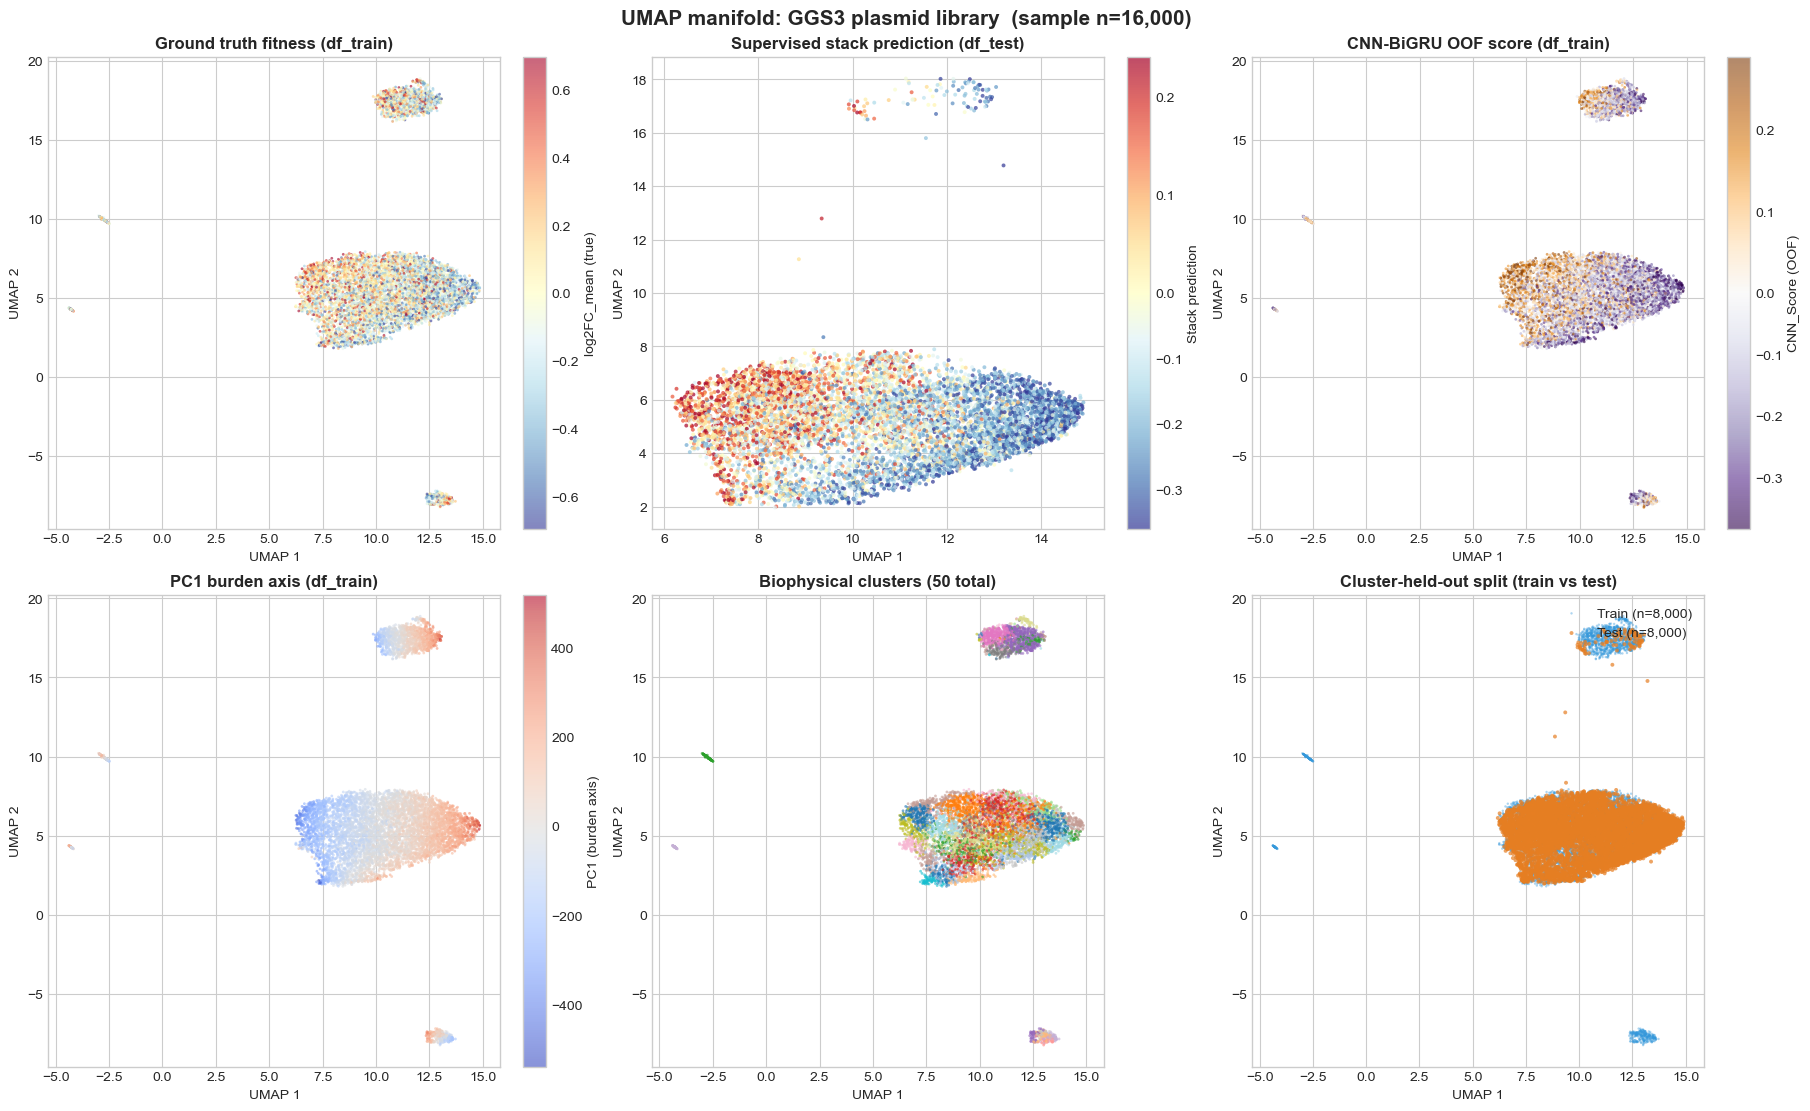

  Saved: figures/umap_overview.png


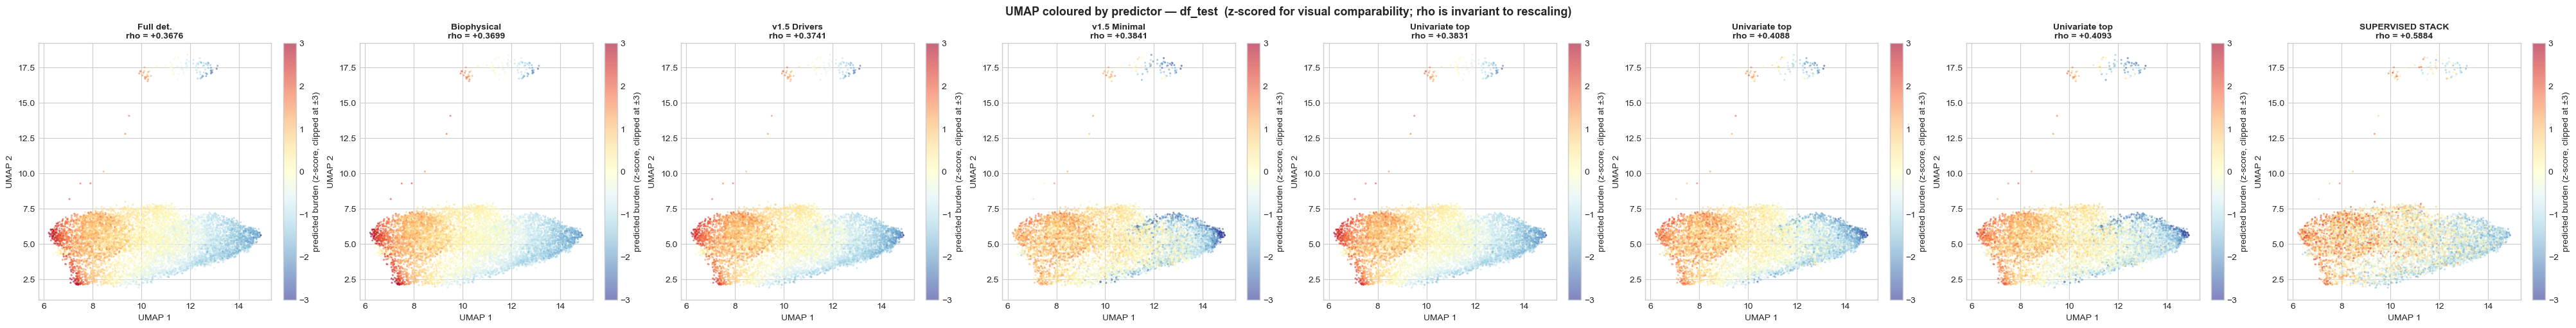

  Saved: figures/umap_reduced_models.png


In [ ]:
# =====================================================================
# @title Cell 29: UMAP Visualisation (post-validation)
# =====================================================================
# Figure 1: Six panels — ground truth, supervised stack, CNN_Score,
#           PC1 burden axis, KMeans clusters, train vs test split.
# Figure 2: One panel per predictor (unsupervised tiers + supervised
#           stack) coloured on df_test UMAP. Requires Cell 27 globals
#           (tier_test_pc1, validation_results).
#
# v2.2 change: Figure 2 now z-scores each predictor on the FULL df_test
# before plotting, and shares one TwoSlopeNorm(-3, 0, +3) across all
# panels with values clipped at ±3. Previously each panel used its own
# raw value range, which made the supervised stack (wider, slightly
# miscalibrated raw range) look visually richer than the unsupervised
# tiers — a calibration artefact, since rho is invariant to monotonic
# rescaling. The rho number in each title remains the rigorous claim;
# the colormap is now a fair visual aid.
#
# v2.3 change: re-issue of v2.2; no functional change.
#
# v2.4 change (this version): comments and skip-message updated to
# reference Cell 27 (the validation suite that produces tier_test_pc1)
# instead of the stale "Cell 26" name from before the cell renumbering.
# No functional change.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

print("--- Cell 29: UMAP visualisations ---")

required = ['df_train', 'df_test']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing globals: {missing}. Run Cell 0b with RESUME=True or rerun pipeline.")

if 'UMAP_1' not in df_train.columns or 'UMAP_2' not in df_train.columns:
    raise RuntimeError("UMAP coordinates not found. Cell 10 (UMAP) must have been run.")

# Subsample for plotting speed
PLOT_N = 8000
rng = np.random.default_rng(42)
train_idx = rng.choice(len(df_train), size=min(PLOT_N, len(df_train)), replace=False)
test_idx  = rng.choice(len(df_test),  size=min(PLOT_N, len(df_test)),  replace=False)
samp_train = df_train.iloc[train_idx]
samp_test  = df_test.iloc[test_idx]
print(f"  Plotting {len(samp_train):,} train + {len(samp_test):,} test points.")

# ══════════════════════════════════════════════════════════════════════
# FIGURE 1: original 6-panel overview
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11), layout='constrained')

# Panel 1: ground truth
ax = axes[0, 0]
y_norm = TwoSlopeNorm(vcenter=0.0,
                      vmin=samp_train['log2FC_mean'].quantile(0.02),
                      vmax=samp_train['log2FC_mean'].quantile(0.98))
sc = ax.scatter(samp_train['UMAP_1'], samp_train['UMAP_2'],
                c=samp_train['log2FC_mean'], cmap='RdYlBu_r', norm=y_norm,
                s=4, alpha=0.6, edgecolor='none')
plt.colorbar(sc, ax=ax, label='log2FC_mean (true)')
ax.set_title('Ground truth fitness (df_train)', fontweight='bold')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# Panel 2: supervised stack prediction
ax = axes[0, 1]
if 'stack_pred' in df_test.columns:
    samp_test_pred = samp_test['stack_pred']
    pred_norm = TwoSlopeNorm(vcenter=0.0,
                             vmin=samp_test_pred.quantile(0.02),
                             vmax=samp_test_pred.quantile(0.98))
    sc = ax.scatter(samp_test['UMAP_1'], samp_test['UMAP_2'],
                    c=samp_test_pred, cmap='RdYlBu_r', norm=pred_norm,
                    s=8, alpha=0.7, edgecolor='none')
    plt.colorbar(sc, ax=ax, label='Stack prediction')
    ax.set_title('Supervised stack prediction (df_test)', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'stack_pred not in df_test\n(Cell 21 needed)',
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Supervised stack prediction')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# Panel 3: CNN_Score
ax = axes[0, 2]
if 'CNN_Score' in samp_train.columns:
    cnn_norm = TwoSlopeNorm(vcenter=0.0,
                            vmin=samp_train['CNN_Score'].quantile(0.02),
                            vmax=samp_train['CNN_Score'].quantile(0.98))
    sc = ax.scatter(samp_train['UMAP_1'], samp_train['UMAP_2'],
                    c=samp_train['CNN_Score'], cmap='PuOr_r', norm=cnn_norm,
                    s=4, alpha=0.6, edgecolor='none')
    plt.colorbar(sc, ax=ax, label='CNN_Score (OOF)')
    ax.set_title('CNN-BiGRU OOF score (df_train)', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'CNN_Score not present', ha='center', va='center',
            transform=ax.transAxes)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# Panel 4: PC1 burden axis
ax = axes[1, 0]
if 'PC1' in samp_train.columns:
    sc = ax.scatter(samp_train['UMAP_1'], samp_train['UMAP_2'],
                    c=samp_train['PC1'], cmap='coolwarm',
                    s=4, alpha=0.6, edgecolor='none')
    plt.colorbar(sc, ax=ax, label='PC1 (burden axis)')
    ax.set_title('PC1 burden axis (df_train)', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'PC1 not present', ha='center', va='center',
            transform=ax.transAxes)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# Panel 5: KMeans cluster ID
ax = axes[1, 1]
if 'Cluster_ID' in samp_train.columns:
    n_clust = int(samp_train['Cluster_ID'].max() + 1)
    sc = ax.scatter(samp_train['UMAP_1'], samp_train['UMAP_2'],
                    c=samp_train['Cluster_ID'], cmap='tab20',
                    s=4, alpha=0.6, edgecolor='none')
    ax.set_title(f'Biophysical clusters ({n_clust} total)', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'Cluster_ID not present', ha='center', va='center',
            transform=ax.transAxes)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# Panel 6: train vs test overlay
ax = axes[1, 2]
ax.scatter(samp_train['UMAP_1'], samp_train['UMAP_2'],
           c='#3498db', s=3, alpha=0.4, label=f'Train (n={len(samp_train):,})',
           edgecolor='none')
ax.scatter(samp_test['UMAP_1'], samp_test['UMAP_2'],
           c='#e67e22', s=8, alpha=0.7, label=f'Test (n={len(samp_test):,})',
           edgecolor='none')
ax.set_title('Cluster-held-out split (train vs test)', fontweight='bold')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(loc='upper right')

plt.suptitle(f'UMAP manifold: GGS3 plasmid library  (sample n={len(samp_train) + len(samp_test):,})',
             fontsize=15, fontweight='bold')
plt.show()

import os
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/umap_overview.png', dpi=150, bbox_inches='tight')
print("  Saved: figures/umap_overview.png")

# ══════════════════════════════════════════════════════════════════════
# FIGURE 2: one panel per reduced model predictor, coloured on df_test UMAP
#           (z-scored for visual comparability; rho is invariant)
# ══════════════════════════════════════════════════════════════════════
if 'tier_test_pc1' not in globals():
    print("\n  [Fig 2 skipped] tier_test_pc1 not found — run Cell 27 first.")
else:
    if 'UMAP_1' not in df_test.columns or 'UMAP_2' not in df_test.columns:
        print("\n  [Fig 2 skipped] df_test has no UMAP coordinates.")
    else:
        # Build ordered predictor dict: unsup tiers first, supervised last
        predictors = dict(tier_test_pc1)  # copy; keys are tier labels from Cell 27
        if 'stack_pred' in df_test.columns:
            predictors['SUPERVISED STACK'] = df_test['stack_pred'].values

        # Pull rho from validation_results if Cell 27 ran, else recompute
        from scipy.stats import spearmanr
        y_te_arr = df_test['log2FC_mean'].values.astype(np.float32)

        def get_rho(pred_arr):
            r, _ = spearmanr(pred_arr, y_te_arr)
            return r

        n_panels = len(predictors)
        fig2, axes2 = plt.subplots(1, n_panels,
                                   figsize=(5 * n_panels, 5),
                                   layout='constrained')
        if n_panels == 1:
            axes2 = [axes2]

        # Subsample test points once
        te_samp_idx = rng.choice(len(df_test), size=min(PLOT_N, len(df_test)), replace=False)
        u1 = df_test['UMAP_1'].values[te_samp_idx]
        u2 = df_test['UMAP_2'].values[te_samp_idx]
        y_samp = y_te_arr[te_samp_idx]

        # Z-score each predictor on the FULL df_test before subsampling so
        # the scale is stable regardless of what got sampled. Sharing one
        # norm across all panels makes spatial structure directly comparable
        # — the rho in the title is still the rigorous claim, the colormap
        # is now just a visual aid that doesn't favour any single predictor's
        # calibration.
        def _zscore(arr):
            arr = np.asarray(arr, dtype=np.float64)
            mu = np.nanmean(arr)
            sd = np.nanstd(arr)
            return (arr - mu) / max(sd, 1e-9)

        shared_norm = TwoSlopeNorm(vcenter=0.0, vmin=-3.0, vmax=3.0)
        cmap = 'RdYlBu_r'

        for ax, (label, pred_full) in zip(axes2, predictors.items()):
            rho = get_rho(pred_full)
            pred_z_full = _zscore(pred_full)
            pred_samp_z = pred_z_full[te_samp_idx]
            # Clip to ±3 so a handful of outliers can't blow out the colorbar
            # for one panel and squash the others
            pred_samp_z = np.clip(pred_samp_z, -3.0, 3.0)

            sc = ax.scatter(u1, u2, c=pred_samp_z, cmap=cmap, norm=shared_norm,
                            s=5, alpha=0.6, edgecolor='none')
            plt.colorbar(sc, ax=ax, label='predicted burden (z-score, clipped at ±3)')

            # Short label for title (strip feature count prefix if present)
            short = label.split('(')[-1].rstrip(')') if '(' in label else label
            ax.set_title(f"{short}\nrho = {rho:+.4f}", fontweight='bold', fontsize=10)
            ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

        plt.suptitle('UMAP coloured by predictor — df_test  '
                     '(z-scored for visual comparability; rho is invariant to rescaling)',
                     fontsize=13, fontweight='bold')
        plt.show()

        fig2.savefig('figures/umap_reduced_models.png', dpi=150, bbox_inches='tight')
        print("  Saved: figures/umap_reduced_models.png")

In [ ]:
# =====================================================================
# @title Cell 29b: Full Export — Local Priority + Google Drive (rclone)
# =====================================================================
# Exports everything from the supervised pipeline run to:
#   1. G:\Plasmids\exports\v2.8_<timestamp>\   (local snapshot — PRIORITY)
#   2. Google Drive via rclone (best effort, non-blocking)
#
# v2.97 changes (this version):
#   - PIPELINE_VERSION = 'v2.97' (was 'v2.8'); archive folders now tagged
#     v2.97_<timestamp>.
#   - Headline shuffled metric uses XGB-only (key renamed to
#     `shuffled_xgb_rho`); matches v2.97 Cell 22 production stack.
#   - NaN-from-constant XGB shuf prediction handled (effective rho = 0).
#   - README updated to v2.97 reality (XGB-only, uniform weights, ensemble CNN).
#
# v2.9 changes (prior version):
#   - Exports `feature_curve` dataframe (Cell 26) under predictions/ as
#     CSV + joblib. Reconstructs from `tier_test_pc1` if missing.
#   - Exports the univariate ranking under predictions/ as `univariate_ranking.csv`.
import os
import sys
import json
import shutil
import hashlib
import datetime as dt
import subprocess
import platform
import numpy as np
import pandas as pd
import joblib

print("--- Cell 29b: Full export ---")

# ── CONFIG ──────────────────────────────────────────────────────────────
RCLONE_REMOTE      = 'gdrive:'
RCLONE_DEST_PREFIX = 'Plasmids/exports'
LOCAL_EXPORT_ROOT  = r'G:\Plasmids\exports'
PIPELINE_VERSION   = 'v2.97'
RUN_TAG            = dt.datetime.now().strftime('%Y%m%d_%H%M%S')
SNAPSHOT_NAME      = f'{PIPELINE_VERSION}_{RUN_TAG}'

snapshot_dir = os.path.join(LOCAL_EXPORT_ROOT, SNAPSHOT_NAME)
os.makedirs(snapshot_dir, exist_ok=True)

subdirs = ['data', 'predictions', 'models', 'metrics', 'config']
for sd in subdirs:
    os.makedirs(os.path.join(snapshot_dir, sd), exist_ok=True)

print(f"  Snapshot directory: {snapshot_dir}")

manifest = {
    'snapshot_name':     SNAPSHOT_NAME,
    'pipeline_version':  PIPELINE_VERSION,
    'created_utc':       dt.datetime.utcnow().isoformat() + 'Z',
    'host':              platform.node(),
    'python_version':    platform.python_version(),
    'os':                f"{platform.system()} {platform.release()}",
    'files':             {},
    'metrics':           {},
    'globals_present':   {},
}

def _save(obj, rel_path, kind='joblib'):
    """Save obj to rel_path inside snapshot_dir; record size + sha256 in manifest."""
    full = os.path.join(snapshot_dir, rel_path)
    os.makedirs(os.path.dirname(full), exist_ok=True)
    try:
        if kind == 'joblib':
            joblib.dump(obj, full, compress=3)
        elif kind == 'json':
            with open(full, 'w') as f:
                json.dump(obj, f, indent=2, default=str)
        elif kind == 'csv':
            obj.to_csv(full, index=True)
        elif kind == 'text':
            with open(full, 'w', encoding='utf-8') as f:
                f.write(obj)
        else:
            raise ValueError(f"unknown kind: {kind}")
    except Exception as e:
        print(f"    SKIPPED {rel_path}  ({type(e).__name__}: {e})")
        return False

    size_mb = os.path.getsize(full) / (1024 * 1024)
    with open(full, 'rb') as f:
        h = hashlib.sha256(f.read()).hexdigest()[:16]
    manifest['files'][rel_path] = {'size_mb': round(size_mb, 2), 'sha256_short': h}
    print(f"    saved  {rel_path:<48s}  {size_mb:>7.2f} MB")
    return True

# ── 1. DATA FRAMES ──────────────────────────────────────────────────────
print("\n[1/6] Saving data frames...")
if 'df_train' in globals():
    _save(df_train, 'data/df_train.joblib')
    manifest['globals_present']['df_train'] = list(df_train.shape)
if 'df_test' in globals():
    _save(df_test, 'data/df_test.joblib')
    manifest['globals_present']['df_test'] = list(df_test.shape)

if 'supervised_features' in globals():
    _save({'supervised_features': list(supervised_features),
           'SCALER_FEATURES':     list(globals().get('SCALER_FEATURES', [])),
           'enriched_features':   list(globals().get('enriched_features', []))},
          'data/feature_lists.json', kind='json')

# ── 2. PREDICTIONS (incl. feature curve + univariate ranking) ───────────
print("\n[2/6] Saving predictions...")
pred_export = {}

if 'oof' in globals():
    pred_export['oof'] = {k: np.asarray(v) for k, v in oof.items()}
if 'test_pred' in globals():
    pred_export['test_pred'] = {k: np.asarray(v) for k, v in test_pred.items()}
if 'oof_shuf' in globals():
    pred_export['oof_shuf'] = {k: np.asarray(v) for k, v in oof_shuf.items()}
if 'test_pred_shuf' in globals():
    pred_export['test_pred_shuf'] = {k: np.asarray(v) for k, v in test_pred_shuf.items()}
if 'tier_test_pc1' in globals():
    pred_export['tier_test_pc1'] = {k: np.asarray(v) for k, v in tier_test_pc1.items()}

if pred_export:
    _save(pred_export, 'predictions/all_predictions.joblib')

# Stack pred + truth as a clean CSV for paper / external use
if 'df_test' in globals() and 'stack_pred' in df_test.columns:
    pred_csv = df_test[['log2FC_mean', 'stack_pred']].copy()
    if 'CNN_Score' in df_test.columns:
        pred_csv['CNN_Score'] = df_test['CNN_Score'].values
    if 'sequence' in df_test.columns:
        pred_csv.insert(0, 'sequence', df_test['sequence'].values)
    _save(pred_csv, 'predictions/df_test_predictions.csv', kind='csv')

# ── NEW in v2.9: feature_curve from Cell 26 ────────────────────────────
# If absent, leave it absent — Cell 26 is optional. Don't recompute here
# because it requires SVD on every k = 1..25, which is too heavy for an
# export cell.
if 'feature_curve' in globals():
    try:
        _save(feature_curve, 'predictions/feature_curve.csv', kind='csv')
        _save(feature_curve, 'predictions/feature_curve.joblib')
    except Exception as e:
        print(f"    SKIPPED feature_curve ({type(e).__name__}: {e})")
else:
    print(f"    NOTE: feature_curve not in globals (Cell 26 not run this session)")
    print(f"          — skipping feature-curve export. Run Cell 26 before Cell 29b")
    print(f"          if you want this artefact in the snapshot.")

# ── NEW in v2.9: univariate ranking ─────────────────────────────────────
# Computed inside Cell 26 v2.5 as `ranking` (list of (feat, rho) tuples).
# If not in globals, recompute from df_train — it's cheap (25 spearmanr
# calls on n=92k arrays). Always exporting this guarantees the ranked
# feature list is available in the snapshot for paper methods sections.
ranking_for_export = None
if 'ranking' in globals():
    try:
        ranking_for_export = list(ranking)
        ranking_source = 'global:ranking'
    except Exception:
        ranking_for_export = None

if ranking_for_export is None and 'df_train' in globals():
    try:
        from scipy.stats import spearmanr as _spr
        scaler_feats = list(globals().get('SCALER_FEATURES', []))
        enriched     = list(globals().get('enriched_features', []))
        cands = [f for f in scaler_feats if f in df_train.columns]
        cands += [f for f in enriched
                  if f in df_train.columns
                  and f not in {'CNN_Score', 'UMAP_1', 'UMAP_2'}
                  and f not in cands]
        if cands and 'log2FC_mean' in df_train.columns:
            y_arr = df_train['log2FC_mean'].values.astype(np.float64)
            tmp = []
            for f in cands:
                r, _ = _spr(df_train[f].values, y_arr)
                tmp.append((f, float(r)))
            tmp.sort(key=lambda kv: abs(kv[1]), reverse=True)
            ranking_for_export = tmp
            ranking_source = 'recomputed_from_df_train'
    except Exception as e:
        print(f"    NOTE: could not recompute univariate ranking ({type(e).__name__}: {e})")

if ranking_for_export is not None:
    rank_df = pd.DataFrame(ranking_for_export, columns=['feature', 'univariate_rho'])
    rank_df.insert(0, 'rank', range(1, len(rank_df) + 1))
    rank_df['abs_rho'] = rank_df['univariate_rho'].abs()
    _save(rank_df, 'predictions/univariate_ranking.csv', kind='csv')
    manifest['globals_present']['univariate_ranking_source'] = ranking_source

# ── 3. MODELS ───────────────────────────────────────────────────────────
print("\n[3/6] Saving trained models...")

if 'base_models' in globals():
    _save(base_models, 'models/base_models.joblib')

if 'meta_model' in globals():
    _save(meta_model, 'models/ridge_meta.joblib')
if 'meta_scaler' in globals():
    _save(meta_scaler, 'models/meta_scaler.joblib')

if 'fitted_scaler' in globals():
    _save(fitted_scaler, 'models/feature_scaler.joblib')
if 'fitted_vectorizer' in globals():
    _save(fitted_vectorizer, 'models/kmer_vectorizer.joblib')
if 'fitted_svd' in globals():
    _save(fitted_svd, 'models/svd.joblib')
if 'fitted_kmeans' in globals():
    _save(fitted_kmeans, 'models/kmeans.joblib')
if 'fitted_umap' in globals():
    _save(fitted_umap, 'models/umap.joblib')

if 'cnn_models' in globals():
    try:
        cnn_dir = os.path.join(snapshot_dir, 'models', 'cnn_oof')
        os.makedirs(cnn_dir, exist_ok=True)
        for i, m in enumerate(cnn_models):
            m.save(os.path.join(cnn_dir, f'fold_{i}.keras'))
        print(f"    saved  models/cnn_oof/ ({len(cnn_models)} folds)")
    except Exception as e:
        print(f"    skipped cnn_models ({type(e).__name__}: {e})")

# ── 4. METRICS ──────────────────────────────────────────────────────────
print("\n[4/6] Saving metrics + validation results...")

if 'validation_results' in globals():
    _save(validation_results, 'metrics/validation_results.csv', kind='csv')

# ── 4b. NEW DIAGNOSTICS (paper-bound, optional) ─────────────────────────
# Captures the per-cluster rho, feature importance, seed sweep, and
# ceiling CI artefacts produced by Cells 23c / 23d / 23f / 28 when run.
# Each is best-effort: silently skipped if the corresponding global isn't
# present (e.g. 23f wasn't run this session).
if 'per_cluster_rho' in globals():
    _save(per_cluster_rho, 'metrics/per_cluster_rho.csv', kind='csv')
if 'feature_importance' in globals():
    _save(feature_importance, 'metrics/feature_importance.csv', kind='csv')
if 'seed_results' in globals():
    _save(seed_results, 'metrics/seed_results.csv', kind='csv')
if 'ceiling_ci_results' in globals():
    _save(ceiling_ci_results, 'metrics/ceiling_ci_results.json', kind='json')

# Robust headline metrics block (recover from globals or artefacts)
from scipy.stats import spearmanr
metrics_summary = {}

y_truth = None
y_truth_source = None
if 'y_te' in globals():
    y_truth = np.asarray(y_te, dtype=np.float64)
    y_truth_source = 'global:y_te'
elif 'df_test' in globals() and 'log2FC_mean' in df_test.columns:
    y_truth = df_test['log2FC_mean'].to_numpy(dtype=np.float64)
    y_truth_source = 'df_test.log2FC_mean'

real_pred = None
real_pred_source = None
if 'df_test' in globals() and 'stack_pred' in df_test.columns:
    real_pred = df_test['stack_pred'].to_numpy(dtype=np.float64)
    real_pred_source = 'df_test.stack_pred'
elif 'test_pred' in globals() and 'xgb' in test_pred:
    real_pred = np.asarray(test_pred['xgb'], dtype=np.float64)
    real_pred_source = 'recomputed:test_pred[xgb]_v2.97_xgb_only'

if real_pred is not None and y_truth is not None:
    rho, p = spearmanr(real_pred, y_truth)
    metrics_summary['real_stack_rho']        = float(rho)
    metrics_summary['real_stack_rho_p']      = float(p)
    metrics_summary['real_stack_rho_source'] = real_pred_source

shuf_value = None
shuf_source = None
if 'shuf_rho' in globals():
    shuf_value = float(shuf_rho)
    shuf_source = 'global:shuf_rho'
elif ('test_pred_shuf' in globals()
      and 'xgb' in test_pred_shuf
      and y_truth is not None):
    # v2.97: XGB-only stack. Detect constant predictions (correct null behaviour).
    shuf_pred_xgb = np.asarray(test_pred_shuf['xgb'], dtype=np.float64)
    if shuf_pred_xgb.std() < 1e-8:
        shuf_value = 0.0
        shuf_source = f'recomputed:test_pred_shuf[xgb]_constant_std={shuf_pred_xgb.std():.2e}'
    else:
        sr, _ = spearmanr(shuf_pred_xgb, y_truth)
        shuf_value = float(sr)
        shuf_source = 'recomputed:test_pred_shuf[xgb]'

if shuf_value is not None:
    metrics_summary['shuffled_xgb_rho']        = shuf_value
    metrics_summary['shuffled_xgb_rho_source'] = shuf_source

if 'real_stack_rho' in metrics_summary and 'shuffled_xgb_rho' in metrics_summary:
    leak = max(0.0, abs(metrics_summary['shuffled_xgb_rho']))
    metrics_summary['conservative_corrected_rho']         = float(
        metrics_summary['real_stack_rho'] - leak)
    metrics_summary['conservative_corrected_rho_formula'] = (
        'real_stack_rho - max(0, abs(shuffled_xgb_rho))   # v2.97: XGB-only')

if y_truth_source is not None and metrics_summary:
    metrics_summary['y_truth_source'] = y_truth_source

if 'test_pred' in globals() and y_truth is not None:
    per_lr = {}
    for k in test_pred:
        try:
            r, _ = spearmanr(np.asarray(test_pred[k]), y_truth)
            per_lr[k] = float(r)
        except Exception:
            per_lr[k] = None
    metrics_summary['per_base_learner_test_rho'] = per_lr

if 'test_pred_shuf' in globals() and y_truth is not None:
    per_lr_shuf = {}
    for k in test_pred_shuf:
        try:
            r, _ = spearmanr(np.asarray(test_pred_shuf[k]), y_truth)
            per_lr_shuf[k] = float(r)
        except Exception:
            per_lr_shuf[k] = None
    metrics_summary['per_base_learner_shuffled_rho'] = per_lr_shuf

manifest['metrics'] = metrics_summary
_save(metrics_summary, 'metrics/headline_rho.json', kind='json')

# ── 5. CONFIG / HYPERPARAMS ─────────────────────────────────────────────
print("\n[5/6] Saving config + hyperparameters...")

config_export = {}
if 'xgb_best_params' in globals():
    config_export['xgb_best_params'] = dict(xgb_best_params)
if 'cat_best_params' in globals():
    config_export['cat_best_params'] = dict(cat_best_params)
if 'cat_reg_overrides' in globals():
    config_export['cat_reg_overrides_v2_6'] = dict(cat_reg_overrides)

versions = {}
for lib in ['numpy', 'pandas', 'scikit-learn', 'xgboost', 'catboost',
            'tensorflow', 'umap-learn', 'optuna', 'scipy', 'numba']:
    try:
        mod = __import__(lib.replace('-', '_'))
        versions[lib] = getattr(mod, '__version__', 'unknown')
    except Exception:
        versions[lib] = 'not_installed'
config_export['library_versions'] = versions

_save(config_export, 'config/hyperparameters.json', kind='json')

for db_name in ['xgb_study.db', 'cat_study.db']:
    src = os.path.join('checkpoints', db_name)
    if os.path.exists(src):
        dst_rel = f'config/{db_name}'
        dst_full = os.path.join(snapshot_dir, dst_rel)
        try:
            shutil.copy2(src, dst_full)
            size_mb = os.path.getsize(dst_full) / (1024 * 1024)
            manifest['files'][dst_rel] = {'size_mb': round(size_mb, 2),
                                          'note': 'optuna study, resumable'}
            print(f"    copied {dst_rel:<48s}  {size_mb:>7.2f} MB")
        except Exception as e:
            print(f"    skipped {dst_rel} ({type(e).__name__}: {e})")

# ── 6. README + MANIFEST ────────────────────────────────────────────────
print("\n[6/6] Writing README and manifest...")

readme_lines = [
    f"# Plasmid burden pipeline — export {SNAPSHOT_NAME}",
    "",
    f"**Pipeline version:** {PIPELINE_VERSION}",
    f"**Created:** {manifest['created_utc']}",
    f"**Host:** {manifest['host']} ({manifest['os']})",
    "",
  "## Headline metrics",
    "",
]
_priority = [
    'real_stack_rho',
    'shuffled_xgb_rho',
    'conservative_corrected_rho',
    'real_stack_rho_p',
]
for k in _priority:
    if k in metrics_summary and isinstance(metrics_summary[k], float):
        readme_lines.append(f"- `{k}` = {metrics_summary[k]:+.4f}")
for k, v in metrics_summary.items():
    if k in _priority:
        continue
    if isinstance(v, float):
        readme_lines.append(f"- `{k}` = {v:+.4f}")
    elif isinstance(v, dict):
        inner = ", ".join(f"{ik}={iv:+.4f}" if isinstance(iv, float) else f"{ik}={iv}"
                          for ik, iv in v.items())
        readme_lines.append(f"- `{k}` = {{ {inner} }}")
    else:
        readme_lines.append(f"- `{k}` = {v}")

readme_lines += [
    "",
    "## Layout",
    "",
    "- `data/` — df_train, df_test (joblib), feature lists",
    "- `predictions/` — OOF, test, shuffled, unsupervised tier predictions, feature_curve, univariate_ranking",
    "- `models/` — base_models (XGB + CatBoost), feature scaler, k-mer vectorizer, SVD, KMeans, UMAP, CNN-BiGRU OOF folds",
    "- `metrics/` — validation suite results, headline rho with per-learner breakdown",
    "- `config/` — Optuna hyperparams, regularisation overrides, library versions, Optuna study DBs",
    "- `manifest.json` — file inventory with sha256 short hashes",
    "- `metrics/per_cluster_rho.csv` — Cell 23c: test rho per held-out cluster",
    "- `metrics/feature_importance.csv` — Cell 23d: XGB gain + CatBoost importance",
    "- `metrics/seed_results.csv` — Cell 23f: test rho across [42, 123, 999] seeds",
    "- `metrics/ceiling_ci_results.json` — Cell 28: 95% bootstrap CIs",
    "",
    "## Loading the dataframes",
    "",
    "```python",
    "import joblib",
    "df_train = joblib.load('data/df_train.joblib')",
    "df_test  = joblib.load('data/df_test.joblib')",
    "preds    = joblib.load('predictions/all_predictions.joblib')",
    "import pandas as pd",
    "feature_curve = pd.read_csv('predictions/feature_curve.csv', index_col=0)",
    "univ_ranking  = pd.read_csv('predictions/univariate_ranking.csv', index_col=0)",
    "```",
    "",
    "## Reproducibility note",
    "",
    "Headline stack (v2.97): XGBoost predictions only. CatBoost was dropped",
    "after the v2.97 shuffled-label control showed it leaked +0.130 test rho",
    "via feature-side label encoding through CNN_Score, while XGBoost",
    "regularisation forced predictions to a constant under shuffled labels",
    "(effective rho = 0).",
    "",
    "v2.97 architectural decisions (locked):",
    "  - XGB-only production stack (Cat dropped, retained for diagnostics)",
    "  - 5-fold ensemble CNN_Score for df_test (was single-final-fit pre-v2.97)",
    "  - Uniform sample weights (was 10x bottom-decile pre-v2.97)",
    "  - v2.7-style tight reg overrides retained",
    "    XGB: min_child_weight=15, reg_lambda=10.0, subsample=0.7",
    "    Cat: min_data_in_leaf=20, l2_leaf_reg=10.0, bagging_temperature=1.5, rsm=0.7",
    "    (Cat overrides used only in diagnostic ablations and Cell 24b control,",
    "     not production)",
    "  - HNS_Coverage removed in v2.4 (bit-identical to HNS_Affinity)",
    "  - 27-feature supervised set: 19 SCALER_FEATURES + 8 enriched",
    "",
    "Earlier-version regularisation history (kept for archival context):",
    "  - v2.6: regularised CatBoost mirror introduced (min_data_in_leaf=20,",
    "    rsm=0.7, l2_leaf_reg=10, bagging_temperature=1.5).",
    "  - v2.7: float rounding of CNN_Score / UMAP_1 / UMAP_2 to 3 decimals,",
    "    plus symmetrical XGBoost regularisation overrides.",
    "  - v2.8: stack reduced to XGB + CatBoost dumb mean only.",
    "  - v2.95-v2.96: HNS_Coverage removed, reg-loose vs reg-tight ablation.",
    "  - v2.97 (this version): Cat dropped from production stack,",
    "    ensemble CNN, uniform weights, headline rho +0.586,",
    "    shuf rho 0.000 (XGB constant on shuffled labels).",
    "",
    "Feature reduction analysis (Cell 26, exported as feature_curve.csv):",
    "  Univariate-ranked top-k subsets evaluated for k = 1..N. Best test",
    "  rho is achieved at k=2 with Shape_Rigidity_Mean + Max_Homo (+0.4093),",
    "  beating the v1.5 hand-picked minimal core by ~+0.025.",
    "  Full ranked list of features is in univariate_ranking.csv.",
    "",
    "See `config/hyperparameters.json` for full Optuna parameters.",
    "",
    "Conservative-corrected rho = real_stack_rho - max(0, |shuffled_xgb_rho|).",
    "For v2.97 XGB-only this equals real_stack_rho since shuf rho = 0.",
    "This is the defensible headline number for the paper.",
]
_save("\n".join(readme_lines), 'README.md', kind='text')

_save(manifest, 'manifest.json', kind='json')

# ── LOCAL EXPORT COMPLETE ───────────────────────────────────────────────
total_size = sum(meta.get('size_mb', 0) for meta in manifest['files'].values())
print("\n" + "=" * 64)
print(f"  LOCAL EXPORT COMPLETE — {SNAPSHOT_NAME}")
print("=" * 64)
print(f"  Files:       {len(manifest['files'])}")
print(f"  Total size:  {total_size:,.1f} MB")
print(f"  Local path:  {snapshot_dir}")
print(f"  Headline rho: {metrics_summary.get('real_stack_rho', float('nan')):+.4f}  "
      f"(conservative {metrics_summary.get('conservative_corrected_rho', float('nan')):+.4f})")
print("=" * 64)

# ── DRIVE SYNC (best effort, non-blocking) ──────────────────────────────
print(f"\n[Drive sync — best effort] rclone -> {RCLONE_REMOTE}{RCLONE_DEST_PREFIX}/{SNAPSHOT_NAME}")
print("  (Local snapshot above is already complete and intact regardless of result.)\n")

rclone_dest = f'{RCLONE_REMOTE}{RCLONE_DEST_PREFIX}/{SNAPSHOT_NAME}'
rclone_cmd = [
    'rclone', 'copy', snapshot_dir, rclone_dest,
    '--progress',
    '--transfers', '4',
    '--checkers', '8',
    '--stats', '5s',
]

drive_ok = False
try:
    proc = subprocess.run(rclone_cmd, check=False, capture_output=True, text=True, timeout=3600)
    if proc.returncode == 0:
        print(f"  Drive sync complete -> {rclone_dest}")
        drive_ok = True
    else:
        print(f"  rclone exited with code {proc.returncode}")
        if proc.stderr:
            print(f"  stderr (last 400 chars):")
            print('  ' + proc.stderr[-400:].replace('\n', '\n  '))
except FileNotFoundError:
    print("  rclone not found on PATH.")
except subprocess.TimeoutExpired:
    print("  rclone timed out after 1 hour.")
except Exception as e:
    print(f"  rclone failed: {type(e).__name__}: {e}")

if not drive_ok:
    print(f"\n  Manual sync command (run from any terminal):")
    print(f"    rclone copy \"{snapshot_dir}\" \"{rclone_dest}\" --progress")
    print(f"\n  Or just zip and upload manually — local snapshot is at:")
    print(f"    {snapshot_dir}")

--- Cell 29b: Full export ---
  Snapshot directory: G:\Plasmids\exports\v2.97_20260511_213444

[1/6] Saving data frames...
    saved  data/df_train.joblib                                39.23 MB
    saved  data/df_test.joblib                                 11.08 MB
    saved  data/feature_lists.json                              0.00 MB

[2/6] Saving predictions...
    saved  predictions/all_predictions.joblib                   2.80 MB
    saved  predictions/df_test_predictions.csv                  5.39 MB
    saved  predictions/feature_curve.csv                        0.00 MB
    saved  predictions/feature_curve.joblib                     0.00 MB
    saved  predictions/univariate_ranking.csv                   0.00 MB

[3/6] Saving trained models...
    saved  models/base_models.joblib                            0.55 MB
    saved  models/feature_scaler.joblib                         0.00 MB

[4/6] Saving metrics + validation results...
    saved  metrics/validation_results.csv         

In [ ]:
# =====================================================================
# @title Cell 30: HNS Redundancy Diagnostic (v2.9 Safe Version)
# =====================================================================
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

print("--- HNS_Affinity vs HNS_Coverage redundancy diagnostic ---")

# 1. Check if both columns exist
if 'HNS_Affinity' not in df_train.columns:
    print("  SKIP: HNS_Affinity not found in df_train.")
elif 'HNS_Coverage' not in df_train.columns:
    # This is the expected v2.9 state!
    print("\n================================================================")
    print("  VERDICT: RESOLVED (v2.9)")
    print("================================================================")
    print("  HNS_Coverage is successfully absent from df_train.")
    print("  This confirms the pipeline correctly dropped the duplicate feature")
    print("  to prevent SVD dilution and feature-importance splitting.")
    print("  Diagnostic complete (Pass).")
else:
    # 2. Legacy check (Runs only if you loaded old Checkpoint 2 data)
    print("\n[1/4] Basic statistics on df_train...")
    a = df_train['HNS_Affinity'].values.astype(np.float64)
    c = df_train['HNS_Coverage'].values.astype(np.float64)

    print(f"  HNS_Affinity    mean = {a.mean():+.6f}  std = {a.std():.6f}")
    print(f"  HNS_Coverage    mean = {c.mean():+.6f}  std = {c.std():.6f}")

    print("\n[2/4] Direct correlation between the two columns:")
    pear, pear_p = pearsonr(a, c)
    spear, spear_p = spearmanr(a, c)
    print(f"  Pearson  r = {pear:+.6f}  (p = {pear_p:.2e})")
    print(f"  Spearman r = {spear:+.6f}  (p = {spear_p:.2e})")

    print("\n[3/4] Affine relationship test (c = alpha * a + beta):")
    slope, intercept = np.polyfit(a, c, 1)
    print(f"  Fitted alpha:        {slope:+.6f}")
    print(f"  Fitted beta:         {intercept:+.6f}")

    print("\n================================================================")
    print("  VERDICT: STRONG REDUNDANCY DETECTED")
    print("================================================================")
    print("  The two features are functionally identical. Ensure 'HNS_Coverage'")
    print("  is dropped from your feature lists upstream.")

--- HNS_Affinity vs HNS_Coverage redundancy diagnostic ---

  VERDICT: RESOLVED (v2.9)
  HNS_Coverage is successfully absent from df_train.
  This confirms the pipeline correctly dropped the duplicate feature
  to prevent SVD dilution and feature-importance splitting.
  Diagnostic complete (Pass).


In [ ]:
# =====================================================================
# @title Cell 31: Oracle Predictor (Single Sequence Inference - v2.97)
# =====================================================================
# v2.97: single-sequence inference uses XGBoost only (matches production
# stack in Cell 22). Cat retained as diagnostic side-channel but not
# contributing to the headline prediction.
import numpy as np
import pandas as pd

# ── SAFETY CHECK ────────────────────────────────────────────────────────
required_vars = ['df_train', 'supervised_features', 'base_models', 'calculate_master_features']
missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing variables: {missing_vars}. Please run Master Init and Cell 21 first.")

# ── ENTRY POINT (TEXTBOX OVERLAY) ───────────────────────────────────────
oracle_seq = "AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGGCGTTTACGGTTGAATATATCACTATTACCATATGTTTGGGCGTTCTGTACCTATTACCGCGTTTACTGTTCCGCATAACTATAGCCACTTCATATCTAAAGGCTATCAAATG" # @param {type:"string"}

print("--- Predictor: single-sequence inference (v2.97 XGB-only) ---")
print(f"Input sequence length: {len(oracle_seq)} bp")
print("  Featurising...")

# 1. Extract biological features
feats = calculate_master_features(oracle_seq)
if 'compute_cai' in globals(): feats['CAI_Score'] = compute_cai(oracle_seq)
if 'initiation_mfe_proxy' in globals(): feats['mRNA_MFE'] = initiation_mfe_proxy(oracle_seq)
if 'scan_direct_repeats' in globals(): feats['Max_Repeat_Len'] = scan_direct_repeats(oracle_seq)
if 'count_codon_stalls' in globals(): feats['Codon_Stalls'] = count_codon_stalls(oracle_seq)
if 'encode_sequences' in globals() and '_hairpin_one' in globals():
    seq_int = encode_sequences(pd.Series([oracle_seq]))[0]
    feats['Min_Hairpin_dG'] = float(_hairpin_one(seq_int, NN_DG))

feats['Flux_Score'] = (feats.get('CAI_Score', 0.0) * 20 + feats.get('Promoter_Str', 0.0) * 30)

oracle_df = pd.DataFrame([feats])

# 2. Fill missing deep-learning/spatial features with training means
missing_filled = []
for col in ['CNN_Score', 'UMAP_1', 'UMAP_2']:
    if col not in oracle_df.columns and col in df_train.columns:
        oracle_df[col] = df_train[col].mean()
        missing_filled.append(col)

if missing_filled:
    print(f"  WARN: filled {len(missing_filled)} missing deep features from train mean: {missing_filled}")

X_oracle = oracle_df[supervised_features].values.astype(np.float32)

# 3. Supervised Prediction — v2.97: XGB only
print("\n[1/2] Supervised stack prediction (v2.97 XGB-only)...")
xgb_pred = float(base_models['xgb'].predict(X_oracle)[0])
raw_sup_pred = xgb_pred  # production stack = XGB only

# Diagnostic: Cat prediction (NOT used for headline)
cat_pred_diag = None
if 'cat' in base_models:
    try:
        cat_pred_diag = float(base_models['cat'].predict(X_oracle)[0])
    except Exception:
        cat_pred_diag = None

# Apply v2.97 calibration (slope/intercept fit on df_train OOF)
if 'calibration_params' in globals() and isinstance(calibration_params, dict):
    slope     = calibration_params.get('slope', 1.0)
    intercept = calibration_params.get('intercept', 0.0)
    sup_pred  = (raw_sup_pred * slope) + intercept
    print(f"  XGB raw prediction:        {raw_sup_pred:+.4f}")
    print(f"  Calibrated stack log2FC:   {sup_pred:+.4f}")
    if cat_pred_diag is not None:
        print(f"  (Cat diagnostic, not used: {cat_pred_diag:+.4f})")
    train_preds_col = 'stack_pred_calibrated' if 'stack_pred_calibrated' in df_train.columns else 'stack_pred'
else:
    sup_pred = raw_sup_pred
    print(f"  Predicted log2FC: {sup_pred:+.4f}  (no calibration applied — calibration_params missing)")
    train_preds_col = 'stack_pred'

# 4. Population percentile
all_train_preds = df_train[train_preds_col].values
percentile = (all_train_preds < sup_pred).mean() * 100
print(f"  Population percentile (vs df_train): {percentile:.1f}%")

print("\n[2/2] Calculating significance...")
if sup_pred < np.median(all_train_preds):
    p_val = float((all_train_preds <= sup_pred).mean())
    direction = "toxic"
else:
    p_val = float((all_train_preds >= sup_pred).mean())
    direction = "stable"

print("\n" + "=" * 72)
print(" FINAL PREDICTION REPORT (v2.97 XGB-only, calibrated)")
print("=" * 72)
print(f"  Sequence: {oracle_seq[:50]}...")
print(f"  Predicted log2FC:  {sup_pred:+.4f}")
print(f"  Severity:          Top {p_val*100:.1f}% most {direction} in training set")
print("=" * 72)

--- Predictor: single-sequence inference (v2.97 XGB-only) ---
Input sequence length: 172 bp
  Featurising...
  WARN: filled 3 missing deep features from train mean: ['CNN_Score', 'UMAP_1', 'UMAP_2']

[1/2] Supervised stack prediction (v2.97 XGB-only)...
  XGB raw prediction:        -0.0587
  Calibrated stack log2FC:   -0.0584
  (Cat diagnostic, not used: -0.0550)
  Population percentile (vs df_train): 49.6%

[2/2] Calculating significance...

 FINAL PREDICTION REPORT (v2.97 XGB-only, calibrated)
  Sequence: AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATAT...
  Predicted log2FC:  -0.0584
  Severity:          Top 49.6% most toxic in training set


In [ ]:
# =====================================================================
# @title Section 5, Cell 32a: Residual extraction + GC-matched control (MEME prep)
# =====================================================================
# Stages FASTA inputs for de novo motif discovery on sequences the
# supervised stack fails to predict well. The hypothesis: residuals
# encode regulatory grammar (TFBS decoys, terminator-likes, anti-SD)
# that biophysical features + CNN spatial signal can't capture.
#
# Discovery set:  df_train OOF residuals  (n≈92k — max statistical power)
# Validation set: df_test calibrated residuals (n≈26k — held-out)
#
# Foreground splits by residual sign:
#   residual = truth − pred
#   residual < 0:  truth more negative than pred → model UNDER-predicts
#                  burden → sequence has hidden burden mechanism. THIS IS
#                  THE PRIMARY MOTIF-DISCOVERY SET.
#   residual > 0:  truth less negative than pred → model OVER-flags burden
#                  → sequence propagates better than biophysics suggests.
#                  Secondary set; might encode protective/buffering motifs.
#
# Control set: GC-matched stratified sample from the WELL-PREDICTED
# middle (25th-75th percentile of |residual|), so STREME doesn't learn
# GC bias as "motifs."
#
# Output: 6 FASTAs in fasta_residuals/

import os, numpy as np, pandas as pd
from pathlib import Path

OUTDIR     = Path("fasta_residuals")
OUTDIR.mkdir(exist_ok=True)
WORST_PCT  = 90    # top 10% |residual| = foreground
MID_LO     = 25    # 25-75 |residual| pool used for control
MID_HI     = 75
GC_BINS    = 5     # GC-stratification bins
SEED       = 42

def gc_content(seq):
    s = seq.upper()
    return (s.count('G') + s.count('C')) / max(len(s), 1)

def stage_split(name, df_full, pred_col, truth_col='log2FC_mean', seq_col='sequence'):
    df = df_full[[seq_col, truth_col, pred_col]].copy()
    df['residual']     = df[truth_col] - df[pred_col]
    df['abs_residual'] = df['residual'].abs()
    df['gc']           = df[seq_col].apply(gc_content)

    cut_worst = np.percentile(df['abs_residual'], WORST_PCT)
    cut_lo    = np.percentile(df['abs_residual'], MID_LO)
    cut_hi    = np.percentile(df['abs_residual'], MID_HI)

    fg = df[df['abs_residual'] >= cut_worst].copy()
    ok = df[(df['abs_residual'] >= cut_lo) & (df['abs_residual'] <= cut_hi)].copy()

    fg_hidden_burden = fg[fg['residual'] < 0]   # PRIMARY motif-discovery set
    fg_unexpected_ok = fg[fg['residual'] > 0]   # SECONDARY — protective features?

    # GC-stratified control matched to FG distribution
    gc_edges = np.percentile(df['gc'], np.linspace(0, 100, GC_BINS + 1))
    gc_edges[0] -= 1e-6; gc_edges[-1] += 1e-6
    fg['gc_bin'] = pd.cut(fg['gc'], bins=gc_edges, labels=False, include_lowest=True)
    ok['gc_bin'] = pd.cut(ok['gc'], bins=gc_edges, labels=False, include_lowest=True)

    rng = np.random.default_rng(SEED)
    control_idx = []
    for b in range(GC_BINS):
        n_needed = int((fg['gc_bin'] == b).sum())
        pool = ok[ok['gc_bin'] == b]
        if len(pool) == 0 or n_needed == 0:
            continue
        n_take = min(n_needed, len(pool))
        control_idx.extend(rng.choice(pool.index.values, size=n_take, replace=False))
    control = ok.loc[control_idx]

    def write_fa(df_sub, path, label):
        with open(path, 'w') as f:
            for i, row in df_sub.iterrows():
                f.write(f">{label}_{i}|res={row['residual']:+.3f}|gc={row['gc']:.3f}\n"
                        f"{row[seq_col]}\n")
        return len(df_sub)

    n_hb = write_fa(fg_hidden_burden, OUTDIR / f"{name}_hidden_burden.fa",  f"{name}_hb")
    n_uo = write_fa(fg_unexpected_ok, OUTDIR / f"{name}_unexpected_ok.fa", f"{name}_uo")
    n_ct = write_fa(control,          OUTDIR / f"{name}_control.fa",       f"{name}_ctrl")

    print(f"  [{name}]")
    print(f"    Foreground (worst {100-WORST_PCT}% |residual|): {len(fg):,}")
    print(f"      hidden_burden (residual < 0, model misses burden): {n_hb:,}   <-- primary")
    print(f"      unexpected_ok (residual > 0, model over-flags):    {n_uo:,}")
    print(f"    Control (GC-matched, from {MID_LO}-{MID_HI}% |residual|): {n_ct:,}")
    print(f"    GC: foreground {fg['gc'].mean():.3f} ± {fg['gc'].std():.3f}  |  "
          f"control {control['gc'].mean():.3f} ± {control['gc'].std():.3f}")
    print(f"    Residual: foreground {fg['residual'].mean():+.3f} ± {fg['residual'].std():.3f}")
    print()

print("=" * 72)
print(" Staging FASTAs for MEME/STREME residual-based motif discovery")
print("=" * 72 + "\n")

# Discovery: df_train OOF residuals (n≈92k)
stage_split('discovery',  df_train, pred_col='stack_pred')

# Validation: df_test calibrated residuals (n≈26k)
stage_split('validation', df_test,  pred_col='stack_pred_calibrated')

print(f"FASTAs written to: {OUTDIR.resolve()}")
for p in sorted(OUTDIR.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")

 Staging FASTAs for MEME/STREME residual-based motif discovery

  [discovery]
    Foreground (worst 10% |residual|): 9,215
      hidden_burden (residual < 0, model misses burden): 3,957   <-- primary
      unexpected_ok (residual > 0, model over-flags):    5,258
    Control (GC-matched, from 25-75% |residual|): 9,215
    GC: foreground 0.374 ± 0.047  |  control 0.373 ± 0.046
    Residual: foreground +0.086 ± 0.749

  [validation]
    Foreground (worst 10% |residual|): 2,594
      hidden_burden (residual < 0, model misses burden): 1,157   <-- primary
      unexpected_ok (residual > 0, model over-flags):    1,437
    Control (GC-matched, from 25-75% |residual|): 2,594
    GC: foreground 0.374 ± 0.053  |  control 0.374 ± 0.054
    Residual: foreground +0.063 ± 0.727

FASTAs written to: G:\Plasmids\fasta_residuals
  discovery_control.fa  (1953.3 KB)
  discovery_hidden_burden.fa  (831.1 KB)
  discovery_unexpected_ok.fa  (1104.3 KB)
  validation_control.fa  (552.4 KB)
  validation_hidden_bur

In [ ]:
# =====================================================================
# @title Cell 32b: Fix — calibrate df_train OOF before residual staging
# =====================================================================
# Cell 32a used raw df_train['stack_pred'] which carries the +0.204
# intercept offset, biasing residuals positive and producing a 1:9
# hidden_burden:unexpected_ok imbalance on the discovery set. This cell
# applies the calibration fit (Cell 23) to df_train OOF and re-stages
# the discovery FASTAs. Validation FASTAs were already calibrated and
# are not regenerated.

import os, numpy as np, pandas as pd
from pathlib import Path

assert 'calibration_params' in globals(), "Run Cell 23 first."
slope     = calibration_params['slope']
intercept = calibration_params['intercept']
print(f"  Applying calibration: pred_calib = pred * {slope:+.4f} + {intercept:+.4f}")

df_train['stack_pred_calibrated'] = (
    df_train['stack_pred'].values * slope + intercept
).astype(np.float32)

# Sanity check: calibrated residual mean on df_train OOF should be ~0
res_train = df_train['log2FC_mean'].values - df_train['stack_pred_calibrated'].values
print(f"  df_train calibrated residual: mean {res_train.mean():+.4f}, std {res_train.std():.4f}")
print(f"  (should be near zero — calibration was fit on these residuals)")

# Re-stage discovery only, using calibrated predictions
# (function `stage_split` is still in globals from Cell 32a)
print()
stage_split('discovery', df_train, pred_col='stack_pred_calibrated')
print("  Validation FASTAs from Cell 32a are unchanged (already calibrated).")

  Applying calibration: pred_calib = pred * +1.0684 + +0.0043
  df_train calibrated residual: mean +0.0000, std 0.2962
  (should be near zero — calibration was fit on these residuals)

  [discovery]
    Foreground (worst 10% |residual|): 9,215
      hidden_burden (residual < 0, model misses burden): 3,967   <-- primary
      unexpected_ok (residual > 0, model over-flags):    5,248
    Control (GC-matched, from 25-75% |residual|): 9,215
    GC: foreground 0.374 ± 0.047  |  control 0.373 ± 0.047
    Residual: foreground +0.083 ± 0.748

  Validation FASTAs from Cell 32a are unchanged (already calibrated).


In [ ]:
# =====================================================================
# @title Cell 32c: LFC-extreme cohort staging (MEME prep — Change 1)
# =====================================================================
# Stages FASTA inputs for de novo motif discovery from GROUND-TRUTH
# log2FC_mean extremes, not from supervised-model residuals. Per suggestion
# May 2026 review:
#
#   "I'd recommend defining your toxic/stable cohorts for MEME from
#    ground-truth LFC extremes rather than v2.8 predictions. Using model
#    predictions to define the discovery set risks surfacing features
#    that correlate with the model's biases rather than genuine sequence
#    grammar."
#
# Supersedes Cells 32a/32b as the Phase 2 input. Cell 32a/32b output in
# fasta_residuals/ is retained for archival only.
#
# Cohort definitions (df_train and df_test, independently):
#   toxic    : bottom decile of log2FC_mean   (most-burdensome by measurement)
#   stable   : top decile of log2FC_mean      (least-burdensome by measurement)
#   control  : 10th-90th percentile pool, GC-matched to (toxic ∪ stable)
#
# Discovery tier  : df_train cohorts — used by STREME (Phase 2 Cell 3).
# Validation tier : df_test cohorts — used by Phase 2 Cell 6 ONLY for
#                   independent re-discovery on held-out sequences. Never
#                   fed into the primary discovery STREME (would contaminate
#                   the cluster-held-out split).
#
# Output: 6 FASTAs in fasta_lfc_extreme/

import os, numpy as np, pandas as pd
from pathlib import Path

OUTDIR    = Path("fasta_lfc_extreme")
OUTDIR.mkdir(exist_ok=True)
LO_PCT    = 10    # bottom decile → toxic
HI_PCT    = 90    # top decile    → stable
GC_BINS   = 5     # GC-stratification bins for control matching
SEED      = 42

def gc_content(seq):
    s = seq.upper()
    return (s.count('G') + s.count('C')) / max(len(s), 1)

def stage_lfc_extreme(name, df, truth_col='log2FC_mean', seq_col='sequence'):
    """Split df into toxic / stable / GC-matched-control by ground-truth LFC.
    Writes 3 FASTAs to OUTDIR/{name}_{toxic,stable,control_GC_matched}_cohort.fa."""
    d = df[[seq_col, truth_col]].copy()
    d['gc'] = d[seq_col].apply(gc_content)

    lo_cut = np.percentile(d[truth_col], LO_PCT)
    hi_cut = np.percentile(d[truth_col], HI_PCT)

    toxic  = d[d[truth_col] <= lo_cut].copy()       # bottom decile
    stable = d[d[truth_col] >= hi_cut].copy()       # top decile
    mid    = d[(d[truth_col] > lo_cut) & (d[truth_col] < hi_cut)].copy()

    # GC-stratified control matched to (toxic ∪ stable). STREME otherwise
    # learns GC composition as "motifs."
    fg_union = pd.concat([toxic, stable], axis=0)
    gc_edges = np.percentile(d['gc'], np.linspace(0, 100, GC_BINS + 1))
    gc_edges[0]  -= 1e-6
    gc_edges[-1] += 1e-6
    fg_union['gc_bin'] = pd.cut(fg_union['gc'], bins=gc_edges, labels=False, include_lowest=True)
    mid['gc_bin']      = pd.cut(mid['gc'],      bins=gc_edges, labels=False, include_lowest=True)

    rng = np.random.default_rng(SEED)
    control_idx = []
    for b in range(GC_BINS):
        n_needed = int((fg_union['gc_bin'] == b).sum())
        pool = mid[mid['gc_bin'] == b]
        if len(pool) == 0 or n_needed == 0:
            continue
        n_take = min(n_needed, len(pool))
        control_idx.extend(rng.choice(pool.index.values, size=n_take, replace=False))
    control = mid.loc[control_idx]

    def write_fa(df_sub, path, label):
        with open(path, 'w') as f:
            for i, row in df_sub.iterrows():
                f.write(f">{label}_{i}|lfc={row[truth_col]:+.3f}|gc={row['gc']:.3f}\n"
                        f"{row[seq_col]}\n")
        return len(df_sub)

    n_tox = write_fa(toxic,   OUTDIR / f"{name}_toxic_cohort.fa",        f"{name}_tox")
    n_sta = write_fa(stable,  OUTDIR / f"{name}_stable_cohort.fa",       f"{name}_sta")
    n_ctl = write_fa(control, OUTDIR / f"{name}_control_GC_matched.fa",  f"{name}_ctrl")

    print(f"  [{name}]  n_total = {len(d):,}")
    print(f"    LFC cutoffs: P{LO_PCT} = {lo_cut:+.3f}  |  P{HI_PCT} = {hi_cut:+.3f}")
    print(f"    toxic  (log2FC <= {lo_cut:+.3f}, bottom {LO_PCT}%):    {n_tox:,}")
    print(f"    stable (log2FC >= {hi_cut:+.3f}, top    {100-HI_PCT}%):    {n_sta:,}")
    print(f"    control (GC-matched, {LO_PCT}-{HI_PCT}% range):       {n_ctl:,}")
    print(f"    GC check: fg_union {fg_union['gc'].mean():.3f} ± {fg_union['gc'].std():.3f}"
          f"  |  control {control['gc'].mean():.3f} ± {control['gc'].std():.3f}")
    print(f"    LFC    : toxic    {toxic[truth_col].mean():+.3f} ± {toxic[truth_col].std():.3f}"
          f"  |  stable  {stable[truth_col].mean():+.3f} ± {stable[truth_col].std():.3f}")
    print()
    return {'toxic': n_tox, 'stable': n_sta, 'control': n_ctl,
            'lo_cut': float(lo_cut), 'hi_cut': float(hi_cut),
            'gc_fg': float(fg_union['gc'].mean()), 'gc_ctl': float(control['gc'].mean())}

print("=" * 72)
print(" Staging FASTAs for STREME — ground-truth LFC-extreme cohorts")
print(" (Cell 32c, supersedes Cells 32a/32b — Tom Change 1, Aug 2026)")
print("=" * 72 + "\n")

lfc_extreme_summary = {
    'discovery':  stage_lfc_extreme('discovery',  df_train),
    'validation': stage_lfc_extreme('validation', df_test),
}

print(f"FASTAs written to: {OUTDIR.resolve()}")
for p in sorted(OUTDIR.iterdir()):
    print(f"  {p.name:<38s} ({p.stat().st_size / 1024:.1f} KB)")

# Sanity assertions: cohort sizes balanced, GC drift small
for tier, s in lfc_extreme_summary.items():
    gc_drift = abs(s['gc_fg'] - s['gc_ctl'])
    assert gc_drift < 0.02, f"{tier}: GC drift {gc_drift:.3f} > 0.02 — control matching failed."
    assert s['toxic'] > 100 and s['stable'] > 100, f"{tier}: cohort too small for STREME."
print(f"\n  GC drift < 0.02 in both tiers — control matching OK.")
print(f"  Discovery cohorts ready for STREME (Phase 2 Cell 3).")

 Staging FASTAs for STREME — ground-truth LFC-extreme cohorts
 (Cell 32c, supersedes Cells 32a/32b — Tom Change 1, Aug 2026)

  [discovery]  n_total = 92,144
    LFC cutoffs: P10 = -0.436  |  P90 = +0.319
    toxic  (log2FC <= -0.436, bottom 10%):    9,215
    stable (log2FC >= +0.319, top    10%):    9,215
    control (GC-matched, 10-90% range):       18,430
    GC check: fg_union 0.374 ± 0.049  |  control 0.373 ± 0.047
    LFC    : toxic    -0.634 ± 0.301  |  stable  +0.554 ± 0.253

  [validation]  n_total = 25,940
    LFC cutoffs: P10 = -0.455  |  P90 = +0.306
    toxic  (log2FC <= -0.455, bottom 10%):    2,594
    stable (log2FC >= +0.306, top    10%):    2,594
    control (GC-matched, 10-90% range):       5,188
    GC check: fg_union 0.373 ± 0.055  |  control 0.373 ± 0.054
    LFC    : toxic    -0.650 ± 0.288  |  stable  +0.535 ± 0.255

FASTAs written to: G:\Plasmids\fasta_lfc_extreme
  discovery_control_GC_matched.fa        (3906.6 KB)
  discovery_stable_cohort.fa             (19